# Regras do Collab
Caso prefecise usar o dataset, baixar o mesmo no colab a aba arquivos

Quando editar uma parte do codigo crie uma nova celula se identificando e tambem a data que foi feito o algoritmo.

In [1]:
#Intaladores de pacotes
install.packages("ggplot2")
install.packages("fitdistrplus")
install.packages("dplyr")
install.packages("knitr")
install.packages("kableExtra")
install.packages("tidyr")
install.packages("FNN")
install.packages("caret")
install.packages("rpart")
install.packages("rpart.plot")
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘svglite’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, 

In [2]:

# Lista de arquivos que estão neste colab junto com as bibliotecas

library(ggplot2)
library(fitdistrplus)
library(knitr)
library(kableExtra)
library(dplyr)
library(tidyr)
library(FNN)
library(caret)
library(rpart)
library(rpart.plot)
library(randomForest)


list.files()

Loading required package: MASS

Loading required package: survival


Attaching package: ‘dplyr’


The following object is masked from ‘package:kableExtra’:

    group_rows


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:survival’:

    cluster


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




[1] "sample_data"         "Santos2018_2025.csv"

Metricas estatisticas das variaveis qualitativas

In [3]:

#Metricas estatisticas

dados <- read.csv("Santos2018_2025.csv")

tempo_num <- as.numeric(dados$tempo_total_atracacao)


media <- mean(tempo_num)
mediana <- median(tempo_num)
moda <- as.numeric(names(tempo_num)[tempo_num == max(tempo_num)])
variancia <- var(tempo_num)
desvio_padrao <- sd(tempo_num)
mediana_geometrica <- exp(mean(log(tempo_num)))
desvio_absoluto <- mean(abs(tempo_num - mean(tempo_num)))
MAD <- mad(tempo_num, constant = 1)
amplitude <- diff(range(tempo_num))

print("tempo total da experiencia do navio no porto de Santos")

# Mostrar resultados
paste("Média = ", round(media, digits = 2))
paste("Mediana = ", round(mediana, digits = 2))
paste("Variância = ", round(variancia, digits = 2))
paste("Desvio Padrão = ", round(desvio_padrao, digits = 2))
paste("Mediana Geometrica = ", round(mediana_geometrica,digits = 2))
paste("Desvio Absoluto Médio = ", round(desvio_absoluto, digits = 2))
paste("MAD = ", round(MAD, digits = 2))
paste("Amplitude = ", round(amplitude, digits = 2))
paste("1 Quartil = ", round(quantile(tempo_num, probs = 0.25), digits = 2))
paste("2 Quartil = ", round(quantile(tempo_num, probs = 0.50), digits = 2))
paste("3 Quartil = ", round(quantile(tempo_num, probs = 0.75), digits = 2))
paste("4 Quartil = ", round((quantile(tempo_num, probs = 1)), digits = 2))
paste("Amplitude Interquartilica = ", round(IQR(tempo_num), digits = 2))

print("tempo da operacão")

tempo_op <- as.numeric(dados$tempo_operacao)


media <- mean(tempo_op)
mediana <- median(tempo_op)
moda <- as.numeric(names(tempo_op)[tempo_op == max(tempo_op)])
variancia <- var(tempo_op)
desvio_padrao <- sd(tempo_op)
mediana_geometrica <- exp(mean(log(tempo_op)))
desvio_absoluto <- mean(abs(tempo_op - mean(tempo_op)))
MAD <- mad(tempo_op, constant = 1)
amplitude <- diff(range(tempo_op))


# Mostrar resultados
paste("Média = ", round(media, digits = 2))
paste("Mediana = ", round(mediana, digits = 2))
paste("Variância = ", round(variancia, digits = 2))
paste("Desvio Padrão = ", round(desvio_padrao, digits = 2))
paste("Mediana Geometrica = ", round(mediana_geometrica,digits = 2))
paste("Desvio Absoluto Médio = ", round(desvio_absoluto, digits = 2))
paste("MAD = ", round(MAD, digits = 2))
paste("Amplitude = ", round(amplitude, digits = 2))
paste("1 Quartil = ", round(quantile(tempo_num, probs = 0.25), digits = 2))
paste("2 Quartil = ", round(quantile(tempo_num, probs = 0.50), digits = 2))
paste("3 Quartil = ", round(quantile(tempo_num, probs = 0.75), digits = 2))
paste("4 Quartil = ", round((quantile(tempo_num, probs = 1)), digits = 2))
paste("Amplitude Interquartilica = ", round(IQR(tempo_num), digits = 2))

print("tempo da espera")

tempo_ex <- as.numeric(dados$tempo_espera)


media <- mean(tempo_ex)
mediana <- median(tempo_ex)
moda <- as.numeric(names(tempo_ex)[tempo_ex == max(tempo_ex)])
variancia <- var(tempo_ex)
desvio_padrao <- sd(tempo_ex)
mediana_geometrica <- exp(mean(log(tempo_ex)))
desvio_absoluto <- mean(abs(tempo_ex - mean(tempo_ex)))
MAD <- mad(tempo_ex, constant = 1)
amplitude <- diff(range(tempo_ex))


# Mostrar resultados
paste("Média = ", round(media, digits = 2))
paste("Mediana = ", round(mediana, digits = 2))
paste("Variância = ", round(variancia, digits = 2))
paste("Desvio Padrão = ", round(desvio_padrao, digits = 2))
paste("Mediana Geometrica = ", round(mediana_geometrica,digits = 2))
paste("Desvio Absoluto Médio = ", round(desvio_absoluto, digits = 2))
paste("MAD = ", round(MAD, digits = 2))
paste("Amplitude = ", round(amplitude, digits = 2))
paste("1 Quartil = ", round(quantile(tempo_num, probs = 0.25), digits = 2))
paste("2 Quartil = ", round(quantile(tempo_num, probs = 0.50), digits = 2))
paste("3 Quartil = ", round(quantile(tempo_num, probs = 0.75), digits = 2))
paste("4 Quartil = ", round((quantile(tempo_num, probs = 1)), digits = 2))
paste("Amplitude Interquartilica = ", round(IQR(tempo_num), digits = 2))

print("tempo de Permanencia")

tempo_pe <- as.numeric(dados$tempo_permanencia)


media <- mean(tempo_pe)
mediana <- median(tempo_pe)
moda <- as.numeric(names(tempo_pe)[tempo_pe == max(tempo_pe)])
variancia <- var(tempo_pe)
desvio_padrao <- sd(tempo_pe)
mediana_geometrica <- exp(mean(log(tempo_pe)))
desvio_absoluto <- mean(abs(tempo_pe - mean(tempo_pe)))
MAD <- mad(tempo_pe, constant = 1)
amplitude <- diff(range(tempo_pe))


# Mostrar resultados
paste("Média = ", round(media, digits = 2))
paste("Mediana = ", round(mediana, digits = 2))
paste("Variância = ", round(variancia, digits = 2))
paste("Desvio Padrão = ", round(desvio_padrao, digits = 2))
paste("Mediana Geometrica = ", round(mediana_geometrica,digits = 2))
paste("Desvio Absoluto Médio = ", round(desvio_absoluto, digits = 2))
paste("MAD = ", round(MAD, digits = 2))
paste("Amplitude = ", round(amplitude, digits = 2))
paste("1 Quartil = ", round(quantile(tempo_num, probs = 0.25), digits = 2))
paste("2 Quartil = ", round(quantile(tempo_num, probs = 0.50), digits = 2))
paste("3 Quartil = ", round(quantile(tempo_num, probs = 0.75), digits = 2))
paste("4 Quartil = ", round((quantile(tempo_num, probs = 1)), digits = 2))
paste("Amplitude Interquartilica = ", round(IQR(tempo_num), digits = 2))

[1] "tempo total da experiencia do navio no porto de Santos"


[1] "Média =  149.37"

[1] "Mediana =  74.17"

[1] "Variância =  65290.7"

[1] "Desvio Padrão =  255.52"

...

[1] "1 Quartil =  33.58"

[1] "2 Quartil =  74.17"

[1] "3 Quartil =  183.42"

[1] "4 Quartil =  18571.25"

[1] "Amplitude Interquartilica =  149.83"

Tratamento dos Dados

In [4]:
#Tratamento de dados

dados$mes <- factor(dados$mes, levels = c("jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"))

dados <- dados %>%
  mutate(
    berco = as.factor(berco),
    terminal = as.factor(terminal),
    mes = as.factor(mes),
    tipo_de_operacao = as.factor(tipo_de_operacao)
  )

dados <- dados %>%
  mutate(
    log_tempo_espera = log(tempo_espera + 1),
    log_tempo_permanencia = log(tempo_permanencia),
    log_tempo_operacao = log(tempo_operacao),
    log_tempo_total_navio = log(tempo_total_atracacao)
  )

breaks_espera <- quantile(dados$tempo_espera, probs = seq(0,1,0.25), na.rm = TRUE)

dados$faixa_espera <- cut(dados$tempo_espera,
                       breaks = breaks_espera,
                       include.lowest = TRUE,
                       labels = c("baixa","media","alta","critica"))

dados <- dados %>%
  mutate(
    eficiencia = tempo_operacao / tempo_total_atracacao
  )

breaks_ef <- quantile(dados$eficiencia, probs = seq(0,1,0.25), na.rm = TRUE)

dados$faixa_eficiencia <- cut(dados$eficiencia,
                           breaks = breaks_ef,
                           include.lowest = TRUE,
                           labels = c("baixa","media","alta","otima"))


Informações Dataset

In [5]:
# Informações do dataset
str(dados)
cat(paste("\nNome das colunas ", "\n"))
colnames(dados)

'data.frame':	34669 obs. of  44 variables:
 $ X                             : int  0 1 2 3 4 5 6 7 8 9 ...
 $ unnamed._0                    : int  126 127 128 129 131 138 140 141 143 146 ...
 $ idatracacao                   : int  901300 934072 940188 901295 901294 901299 901298 969973 966007 934071 ...
 $ cdtup                         : chr  "brssz" "brssz" "brssz" "brssz" ...
 $ idberco                       : chr  "ssz0627" "ssz0627" "ssz0628" "ssz0628" ...
 $ berco                         : Factor w/ 60 levels "ageo_sp","ageo01",..: 52 52 51 51 51 51 51 51 51 51 ...
 $ porto_atracacao               : chr  "santos" "santos" "santos" "santos" ...
 $ coordenadas                   : chr  "-46.301939,-23.966053" "-46.301939,-23.966053" "-46.301939,-23.966053" "-46.301939,-23.966053" ...
 $ apelido_instalacao_portuaria  : chr  "" "" "" "" ...
 $ complexo_portuario            : chr  "santos" "santos" "santos" "santos" ...
 $ tipo_da_autoridade_portuaria  : chr  "porto_organizado" "porto_o

[1] "X"                              "unnamed._0"                    
 [3] "idatracacao"                    "cdtup"                         
 [5] "idberco"                        "berco"                         
 [7] "porto_atracacao"                "coordenadas"                   
 [9] "apelido_instalacao_portuaria"   "complexo_portuario"            
[11] "tipo_da_autoridade_portuaria"   "data_atracacao"                
[13] "data_chegada"                   "data_desatracacao"             
[15] "data_inicio_operacao"           "data_termino_operacao"         
[17] "ano"                            "mes"                           
[19] "tipo_de_operacao"               "tipo_de_navegacao_da_atracacao"
[21] "nacionalidade_do_armador"       "flagmcoperacaoatracacao"       
[23] "terminal"                       "municipio"                     
[25] "uf"                             "sguf"                          
[27] "regiao_geografica"              "regiao_hidrografica"           
[29] "instalacao_portuaria_em_rio"    "no_da_capitania"               
[31] "no_do_imo"                      "longitude"                     
[33] "latitude"                       "tempo_espera"                  
[35] "tempo_permanencia"              "tempo_total_atracacao"         
[37] "tempo_operacao"                 "log_tempo_espera"              
[39] "log_tempo_permanencia"          "log_tempo_operacao"            
[41] "log_tempo_total_navio"          "faixa_espera"                  
[43] "eficiencia"                     "faixa_eficiencia"

In [6]:
# elimina colunas
dados_final <- dados %>% select(-c(X, unnamed._0, latitude, longitude))

# write.csv2(dados_final,"Santos2018_2025_final.csv", row.names = FALSE)

In [7]:
# str(dados_final)

Fatores e tanbles das Variaveis

In [8]:
# Factores das variaveis

print("meses")
table(factor(dados$mes, levels = c("jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez")))

table(as.numeric(factor(dados$mes, levels = c("jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"))))

print("Anos")
table(dados$ano)


print("tipo de navegacao")

table(dados$tipo_de_navegacao_da_atracacao)

print("Tipo Operacao")

table(dados$tipo_de_operacao )

print("berco")

table(dados$idberco)

[1] "meses"



 jan  fev  mar  abr  mai  jun  jul  ago  set  out  nov  dez 
2709 2661 3059 2819 2890 2862 2918 2940 2910 2960 2913 3028 


   1    2    3    4    5    6    7    8    9   10   11   12 
2709 2661 3059 2819 2890 2862 2918 2940 2910 2960 2913 3028 

[1] "Anos"



2018 2019 2020 2021 2022 2023 2024 2025 
4178 4029 4124 3942 4339 4527 4732 4798 

...


 apoio_maritimo apoio_portuario       cabotagem        interior     longo_curso 
              7             367            5329               2           28964 

[1] "Tipo Operacao"



        abastecimento                 apoio               marinha 
                    4                     2                    86 
movimentacao_da_carga            passageiro     reparo/manutencao 
                33300                   822                   455 

[1] "berco"



brsp0010001 brsp0010002 brsp0010003 brsp0010004 brsp0080001 brsp0080002 
        674         624         794         387        2237        1932 
brsp0085003 brsp0085004     ssz0101     ssz0102     ssz0103     ssz0104 
        662         441        1295         972         944         966 
    ssz0107     ssz0108     ssz0109     ssz0111     ssz0112     ssz0211 
       1808        1989        1921         908        1031         186 
    ssz0212     ssz0213     ssz0214     ssz0240     ssz0310     ssz0317 
        275         322         397         127         674          22 
    ssz0319     ssz0320     ssz0321     ssz0322     ssz0412     ssz0413 
          1           1           1           6         516         234 
    ssz0415     ssz0416     ssz0419     ssz0420     ssz0422     ssz0423 
        332        1179         943        1174          43         409 
    ssz0524     ssz0525     ssz0626     ssz0627     ssz0628     ssz0629 
        143         328         480         202   

Boxplots para a analise da assimetria

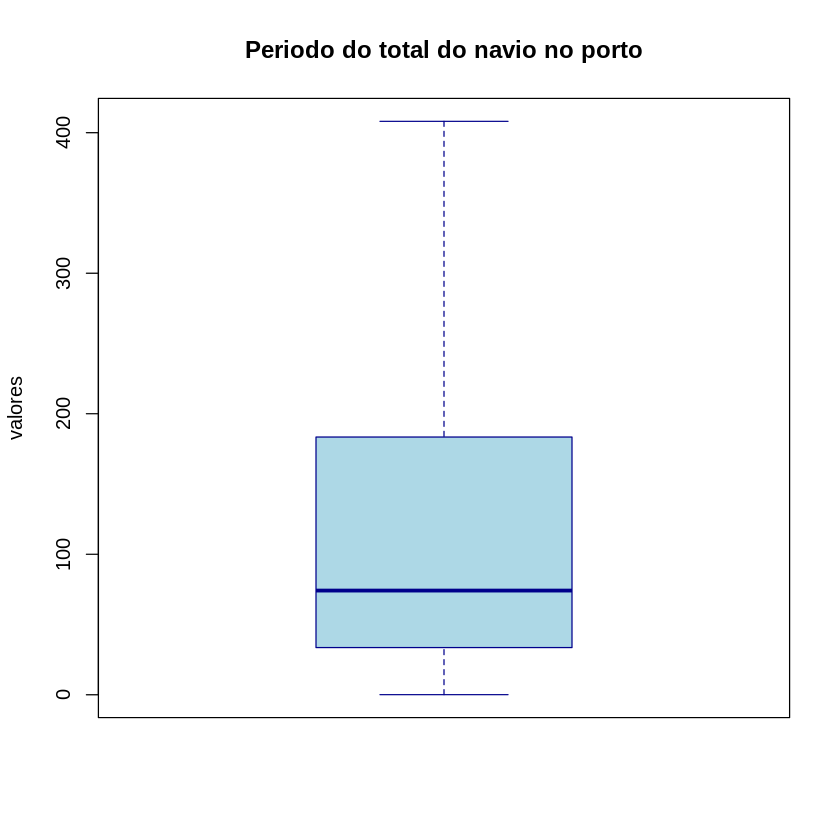

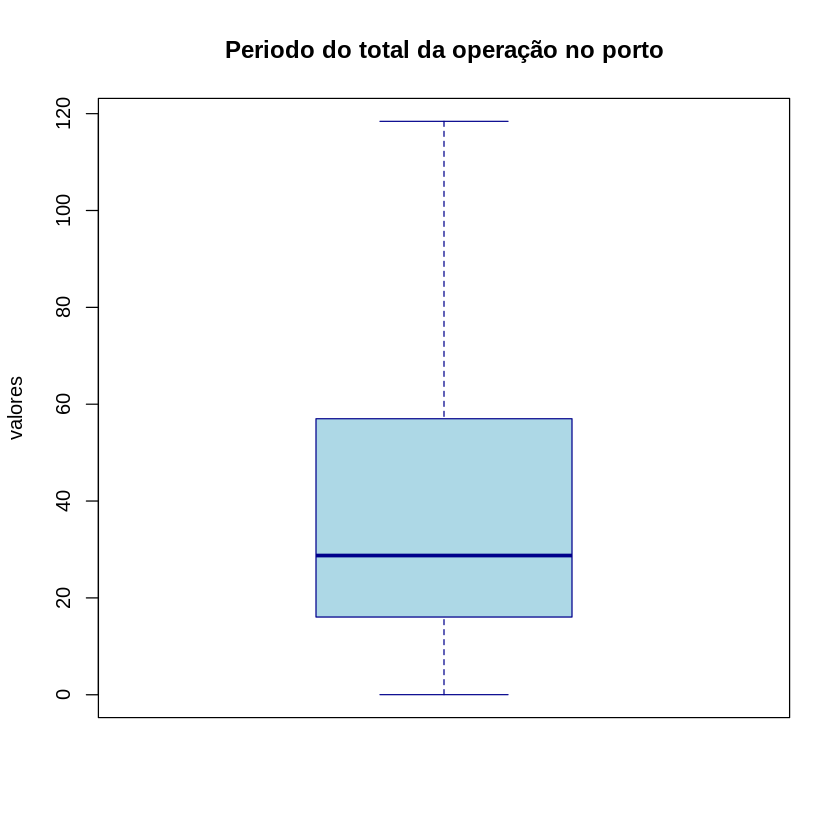

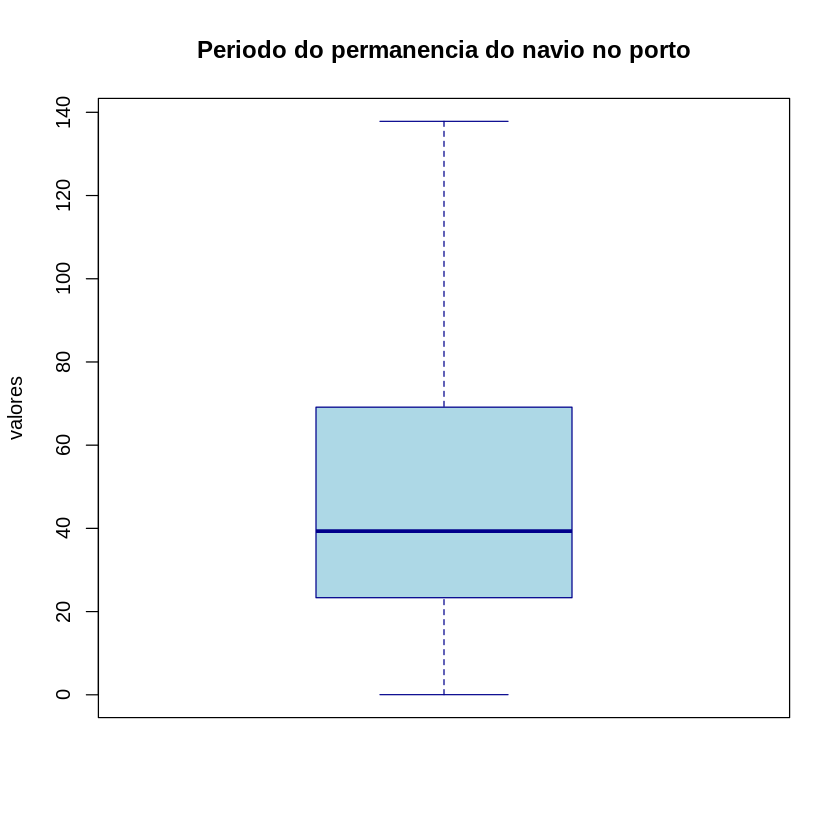

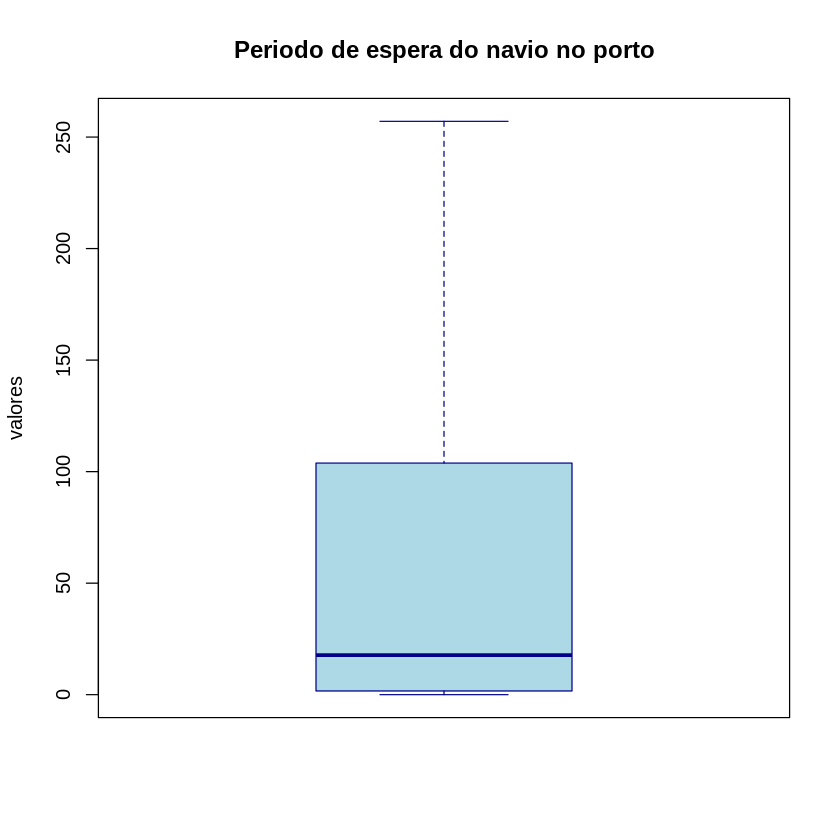

In [9]:
# Box plot unico

# Box plot do periodo de navio que ficou atracado no Porto

boxplot(tempo_num,
        outline = FALSE,
        main = "Periodo do total do navio no porto",
        ylab = "valores",
        col = "lightblue",
        border = "darkblue",
        notch = F
        )

boxplot(tempo_op,
        outline = FALSE,
        main = "Periodo do total da operação no porto",
        ylab = "valores",
        col = "lightblue",
        border = "darkblue",
        notch = F
        )

boxplot(tempo_pe,
        outline = FALSE,
        main = "Periodo do permanencia do navio no porto",
        ylab = "valores",
        col = "lightblue",
        border = "darkblue",
        notch = F
        )

boxplot(tempo_ex,
        outline = FALSE,
        main = "Periodo de espera do navio no porto",
        ylab = "valores",
        col = "lightblue",
        border = "darkblue",
        notch = F
        )


Histograma da variavel qualitativa meses

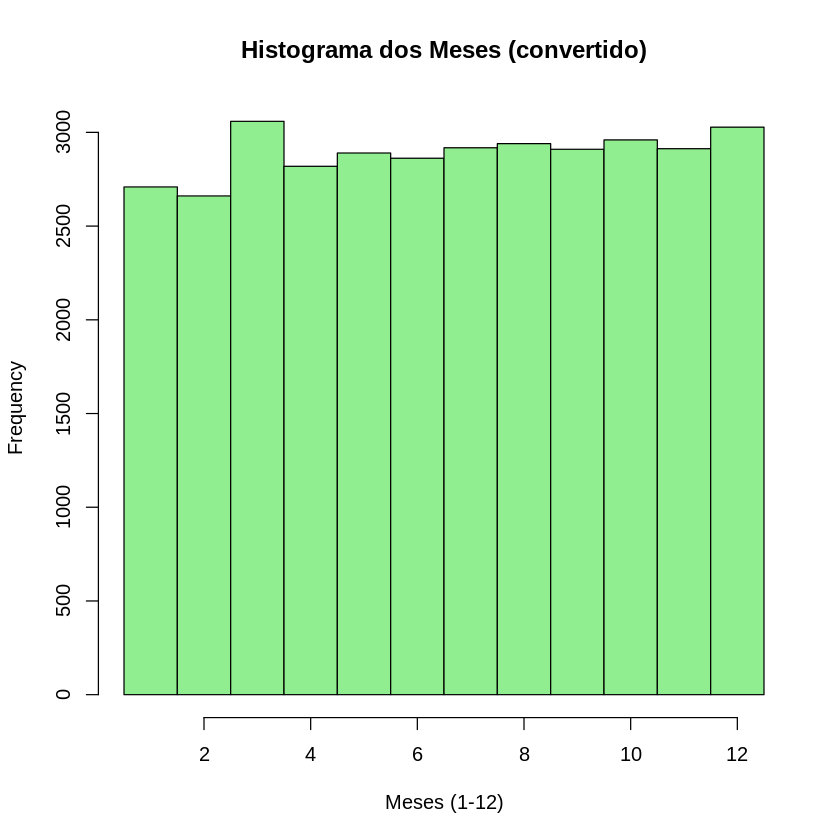

In [10]:
# Histogramas e analise da distribuição
meses <- as.numeric(factor(dados$mes, levels = c("jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez")))

hist(meses,
     breaks = seq(0.5, 12.5, by = 1),
     right = TRUE,
     col = "lightgreen",
     main = "Histograma dos Meses (convertido)",
     xlab = "Meses (1-12)")


Histogramas para a analise das distribuições nos tempos de atracação

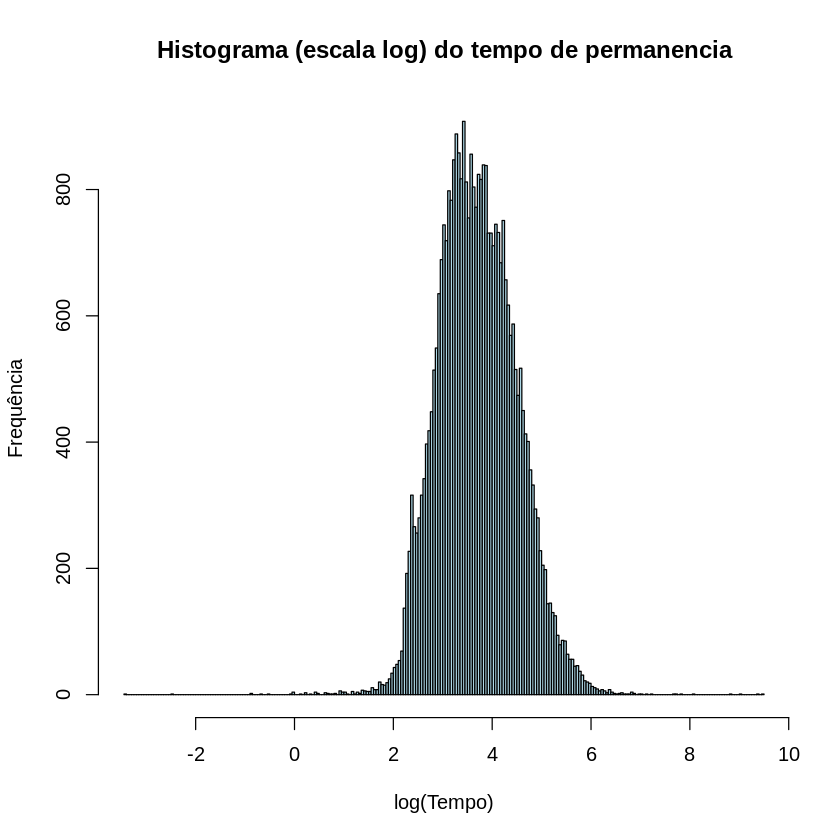

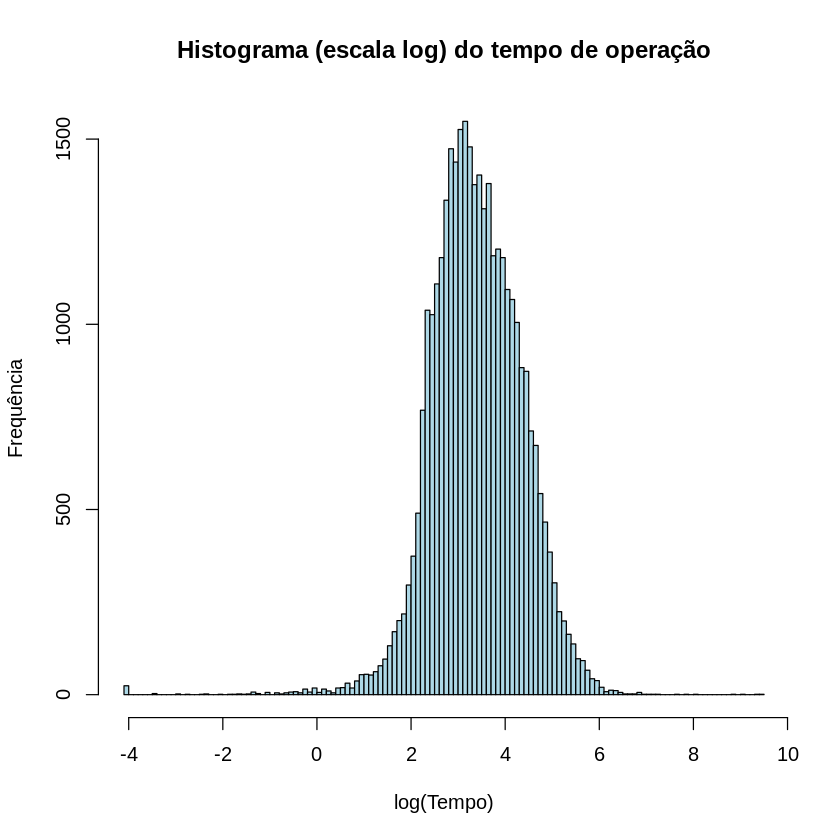

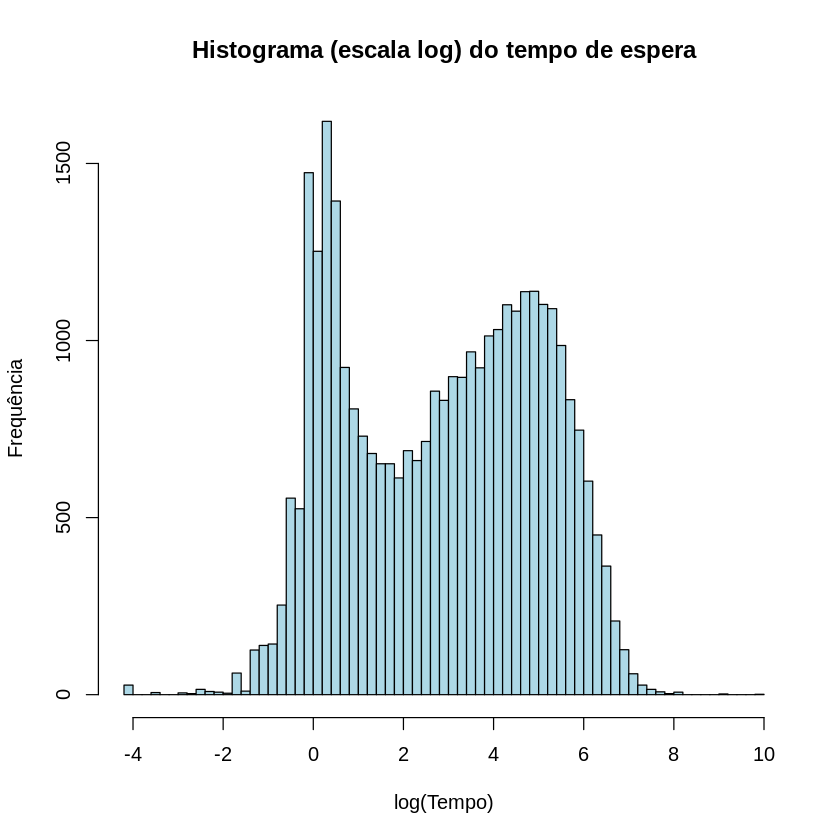

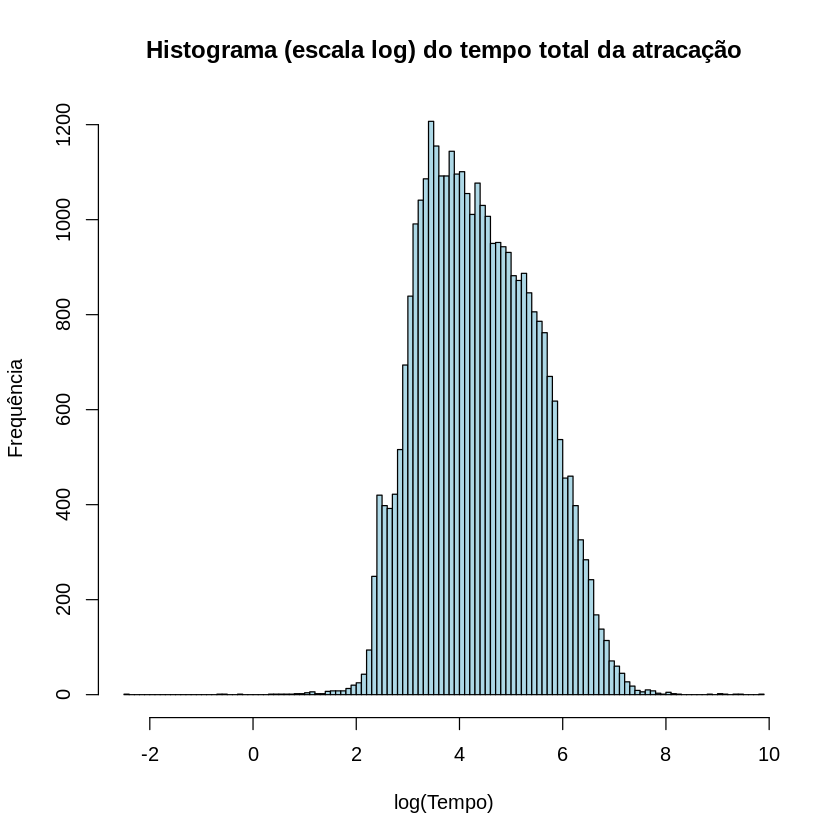

In [11]:
#Histograma dos tempos de atracacao e operacao

hist(dados$log_tempo_permanencia,
     breaks = "FD",
     main = "Histograma (escala log) do tempo de permanencia",
     col = "lightblue",
     xlab = "log(Tempo)",
     ylab = "Frequência")

    hist(log(dados$tempo_operacao),
     breaks = "FD",
     main = "Histograma (escala log) do tempo de operação",
     col = "lightblue",
     xlab = "log(Tempo)",
     ylab = "Frequência")

    hist(log(dados$tempo_espera),
    breaks = "FD",
     main = "Histograma (escala log) do tempo de espera",
     col = "lightblue",
     xlab = "log(Tempo)",
     ylab = "Frequência")

    hist(log(dados$tempo_total_atracacao),
     breaks = "FD",
     main = "Histograma (escala log) do tempo total da atracação",
     col = "lightblue",
     xlab = "log(Tempo)",
     ylab = "Frequência")

Validação das distribuições das variaveis de tempo analisadas, usando o coeficiente de variação

In [12]:
# Variabilidade dos dados

permanencia <- dados$tempo_permanencia

espera <- dados$tempo_espera

total <- dados$tempo_total_atracacao

operacao <- dados$tempo_operacao

paste("variabilidade do Tempo de permanencia ", sd(permanencia)/ mean(permanencia))

paste("variabilidade do Tempo de espera ", sd(espera)/ mean(espera))

paste("variabilidade do Tempo de total da atracação ", sd(total)/ mean(total))

paste("variabilidade do Tempo de total da operação ", sd(operacao)/ mean(operacao))


[1] "variabilidade do Tempo de permanencia  2.19002626872198"

[1] "variabilidade do Tempo de espera  2.31515923988929"

[1] "variabilidade do Tempo de total da atracação  1.71064944120959"

[1] "variabilidade do Tempo de total da operação  2.61436212803297"

Tipos de distribuições possiveis para as variaveis estudadas de tempo

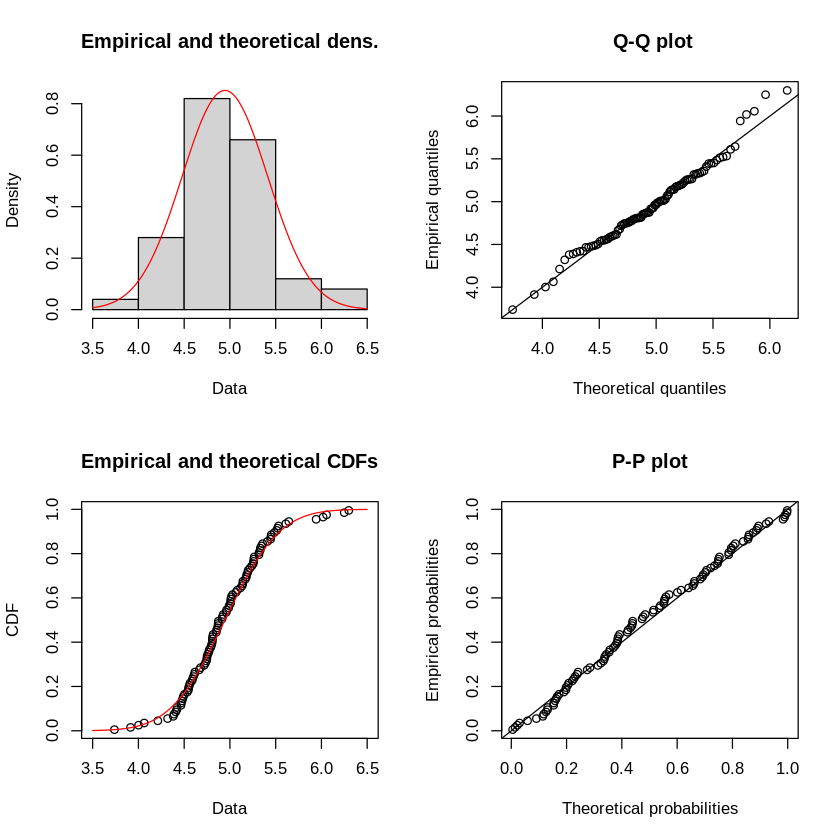

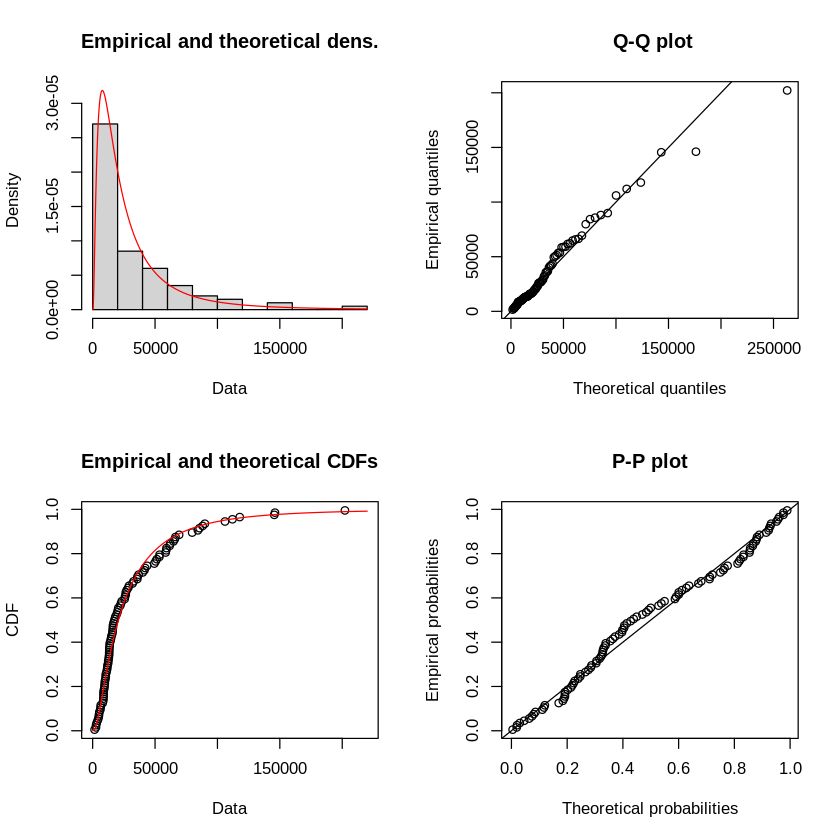

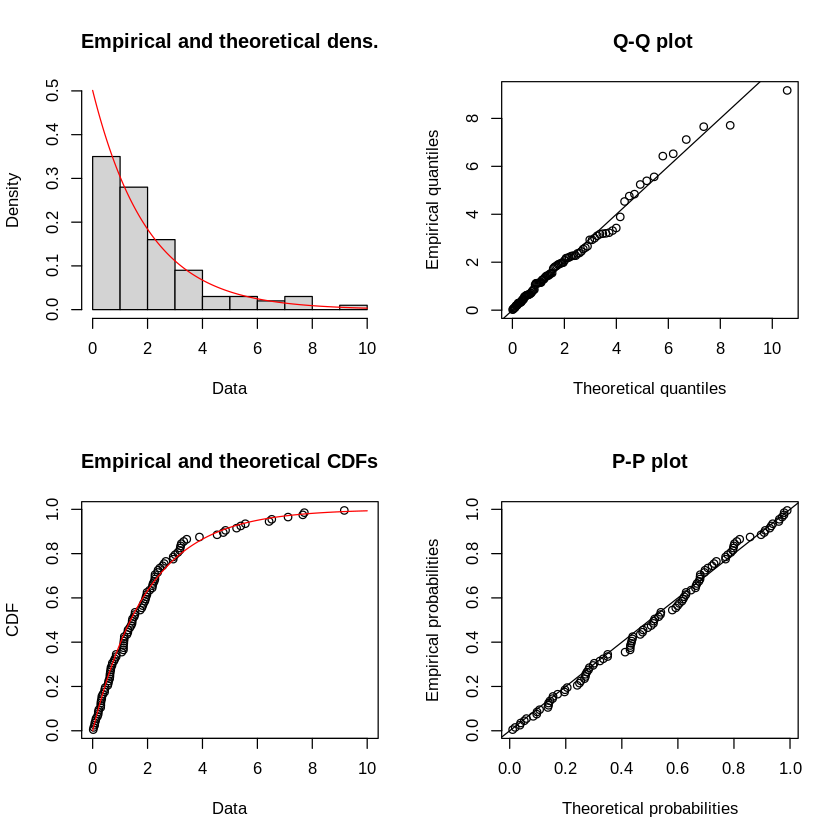

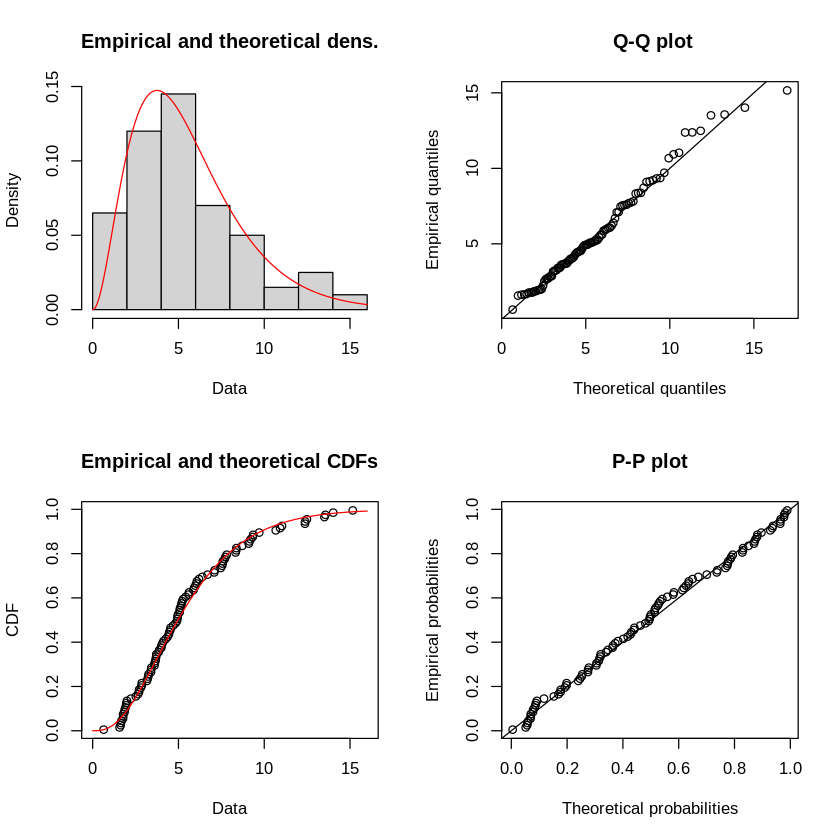

In [14]:
# Tipos de distribuição usados para comparação

dates <- rnorm(100, mean = 5, sd = 0.5)

plot(fitdist(dates, "norm"))

dates <- rlnorm(100, mean = 10, sd = 1)

plot(fitdist(dates, "lnorm"))

dates <- rexp(100, rate = 0.5)

plot(fitdist(dates, "exp"))

dates <- rgamma(100, shape = 3 ,rate = 0.5)

plot(fitdist(dates, "gamma"))



Graficos de colunas dos tempos totais de operação e os tempos de permanencia dos navios no Porto de Santos mensais e anuais

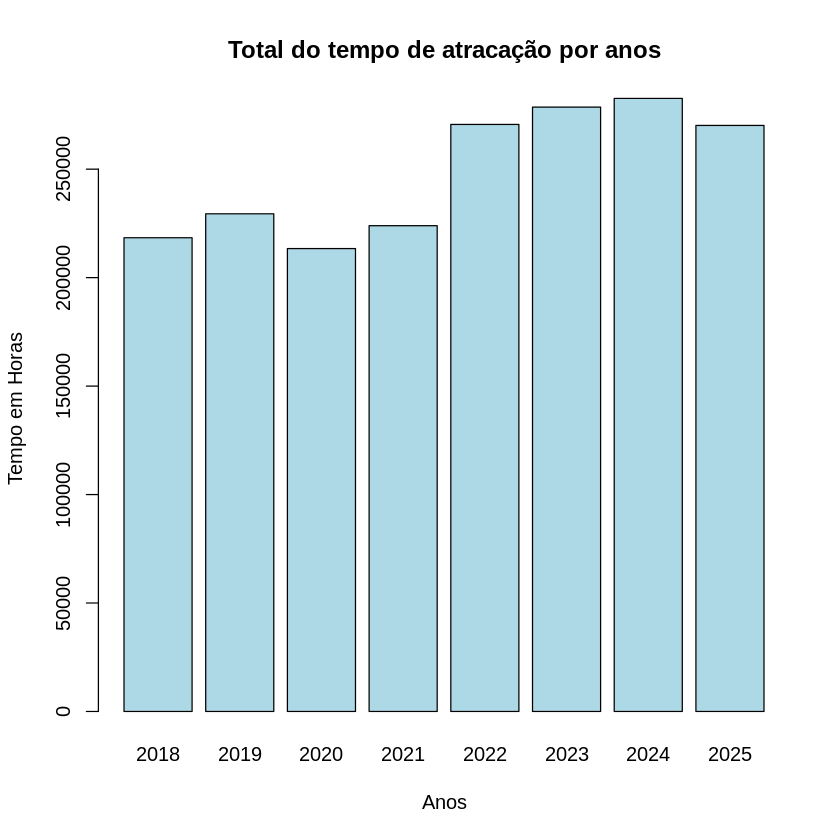

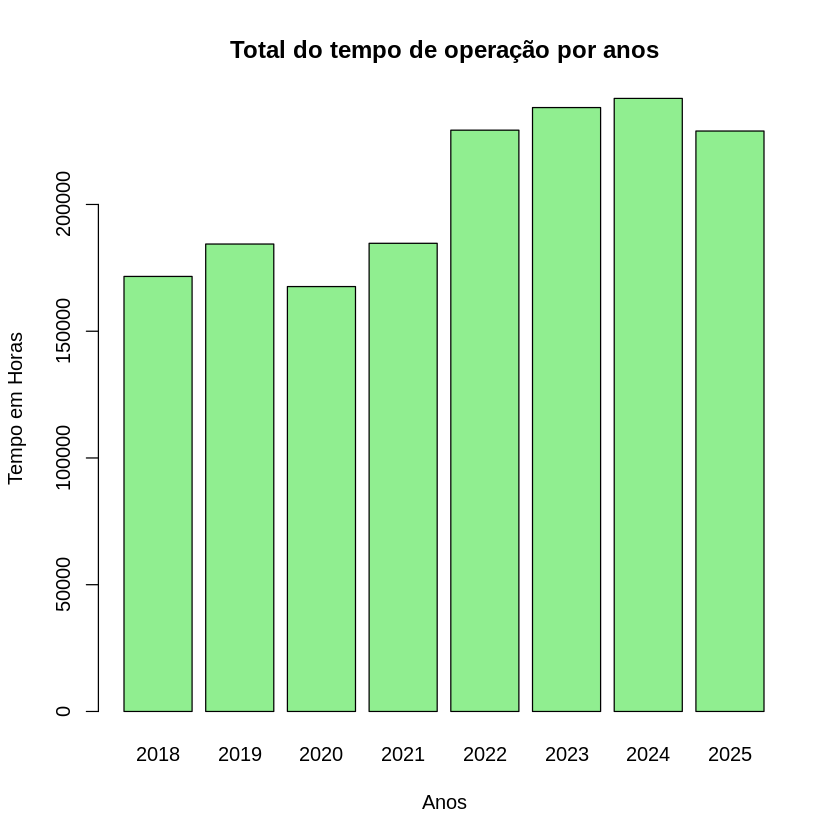

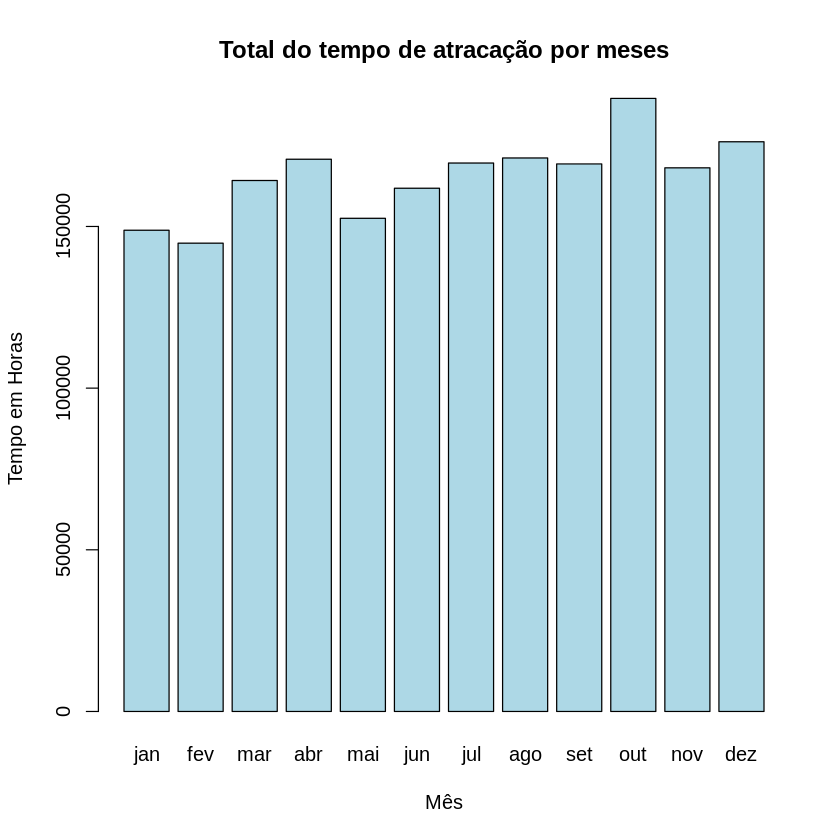

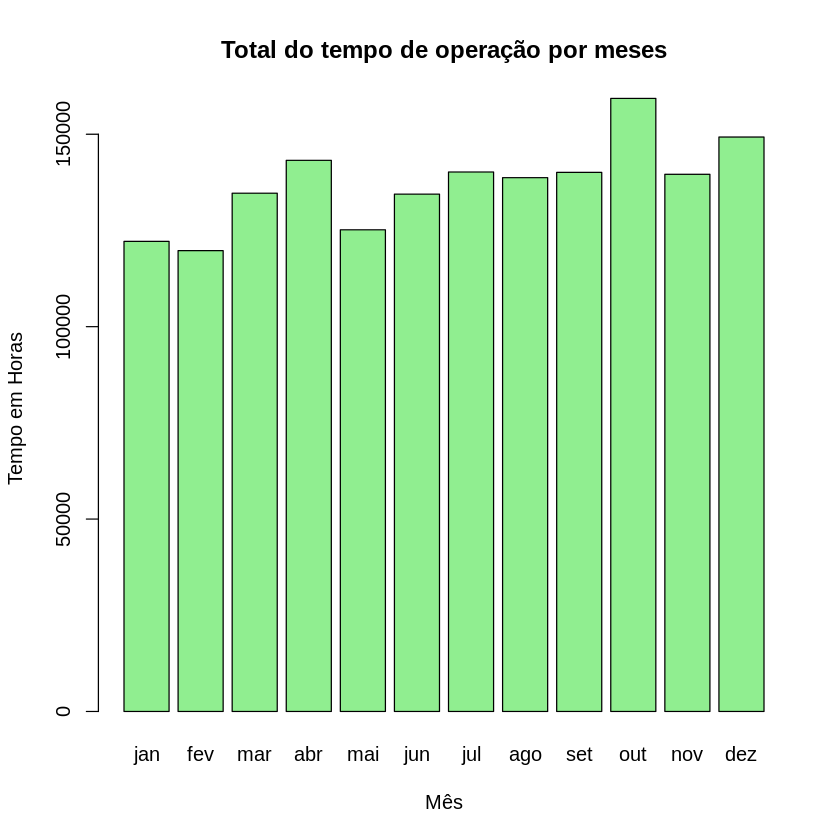

In [15]:
# Graficos de barras dos anos e dos meses baseado na soma do tempo de atracação:

mes <- factor(dados$mes, levels = c("jan","fev","mar","abr","mai","jun","jul","ago","set","out","nov","dez"))

tempo_meses_at <- tapply(dados$tempo_permanencia, mes, sum)

tempo_anos_at <- tapply(dados$tempo_permanencia, dados$ano, sum)

tempo_meses_op <- tapply(dados$tempo_operacao, mes, sum)

tempo_anos_op <- tapply(dados$tempo_operacao, dados$ano, sum)

barplot(tempo_anos_at,
        col = "lightblue",
        main = "Total do tempo de atracação por anos",
        xlab = "Anos",
        ylab = "Tempo em Horas"
)

barplot(tempo_anos_op,
        col = "lightgreen",
        main = "Total do tempo de operação por anos",
        xlab = "Anos",
        ylab = "Tempo em Horas"
)

barplot(tempo_meses_at,
        col = "lightblue",
        main = "Total do tempo de atracação por meses",
        xlab = "Mês",
        ylab = "Tempo em Horas"
)

barplot(tempo_meses_op,
        col = "lightgreen",
        main = "Total do tempo de operação por meses",
        xlab = "Mês",
        ylab = "Tempo em Horas"
)

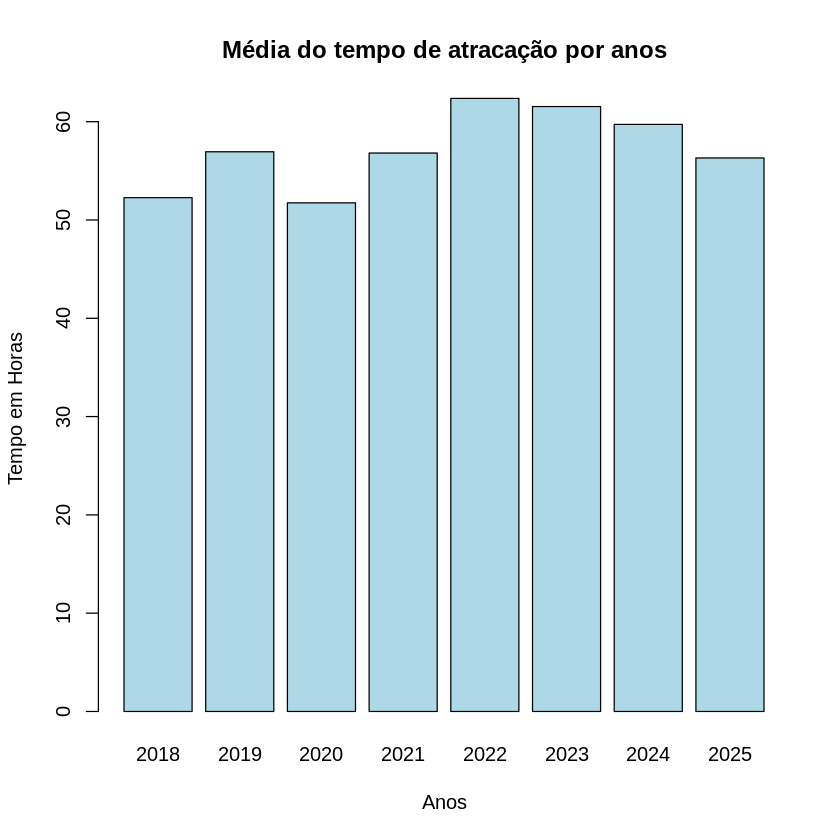

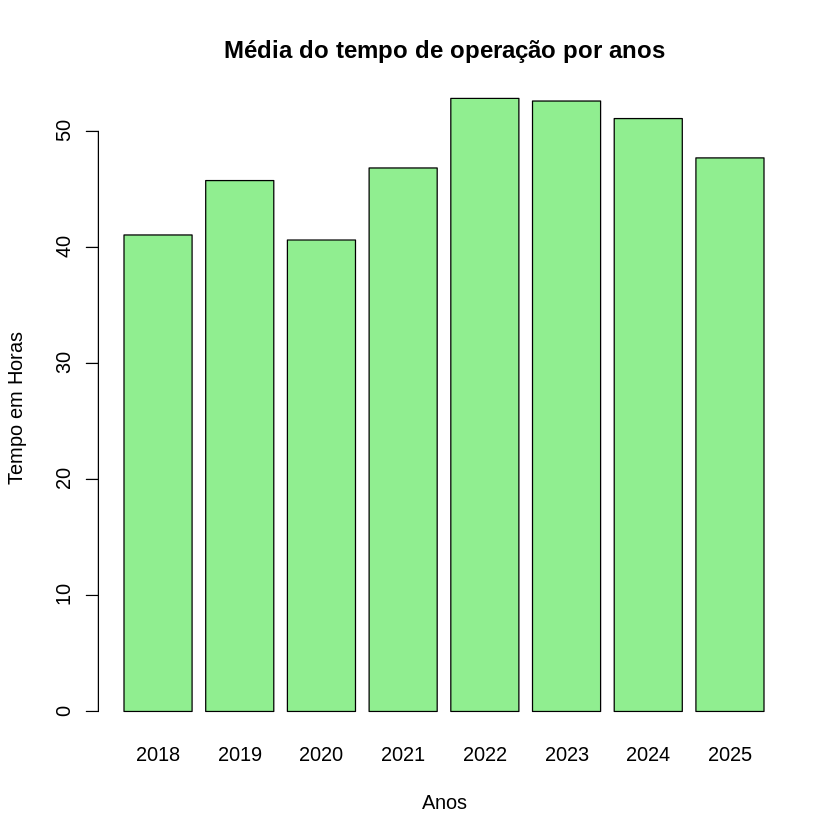

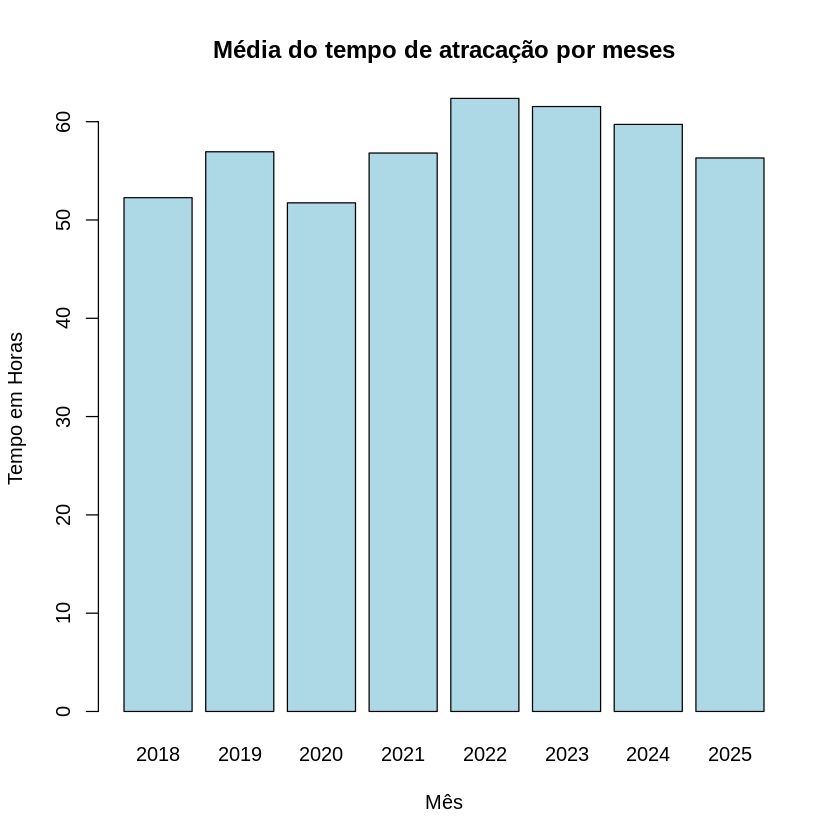

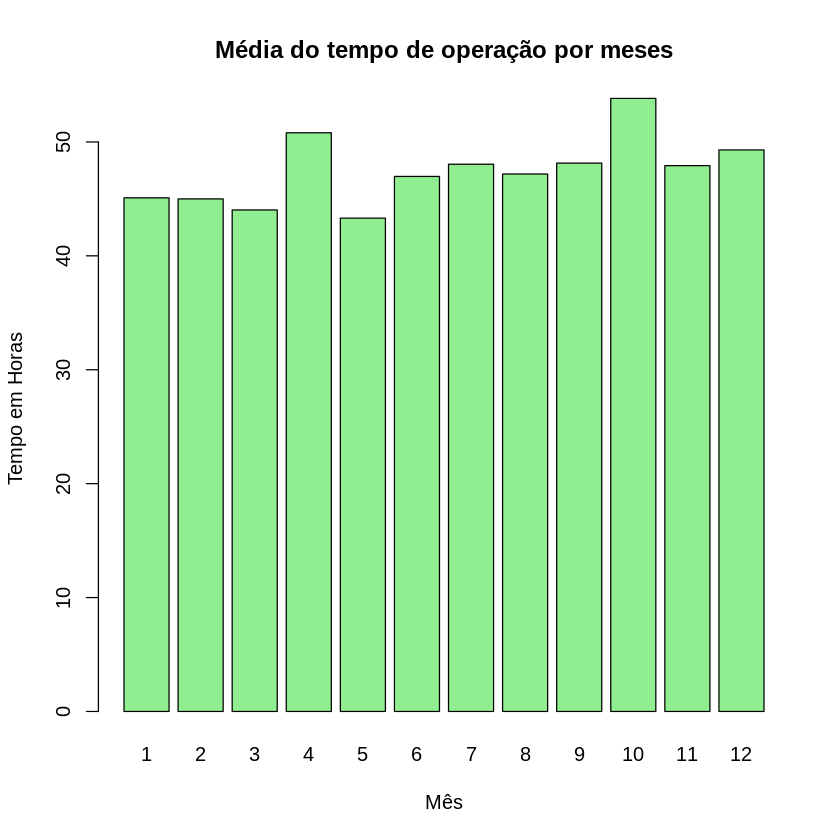

In [16]:
# Graficos de barras dos anos e dos meses baseado na média tempo de atracação:

tempo_meses_at <- tapply(dados$tempo_permanencia, dados$ano, mean)

tempo_anos_at <- tapply(dados$tempo_permanencia, dados$ano, mean)

tempo_meses_op <- tapply(dados$tempo_operacao, meses, mean)

tempo_anos_op <- tapply(dados$tempo_operacao, dados$ano, mean)

barplot(tempo_anos_at,
        col = "lightblue",
        main = "Média do tempo de atracação por anos",
        xlab = "Anos",
        ylab = "Tempo em Horas"
)

barplot(tempo_anos_op,
        col = "lightgreen",
        main = "Média do tempo de operação por anos",
        xlab = "Anos",
        ylab = "Tempo em Horas"
)

barplot(tempo_meses_at,
        col = "lightblue",
        main = "Média do tempo de atracação por meses",
        xlab = "Mês",
        ylab = "Tempo em Horas"
)


barplot(tempo_meses_op,
        col = "lightgreen",
        main = "Média do tempo de operação por meses",
        xlab = "Mês",
        ylab = "Tempo em Horas"
)

Tabelas de Dupla entrada sobre os terminais e os meses sobre a faixa de eficiencia no porto junto com os qui-quadrados de Pearson

In [17]:
# tabela de dupla entrada:


print("Tabela de dupla entrada entre terminal e faixa de espera")
tab_te <- table(dados$terminal, dados$faixa_espera)

tab_freq_te <- rbind(
  cbind(tab_te, margin.table(tab_te,1)),
  c(margin.table(tab_te,2), sum(margin.table(tab_te,1)))
)

dimnames(tab_freq_te)[[1]][4]
dimnames(tab_freq_te)[[2]][4]

kable(tab_freq_te)

chisq.test(tab_te)

chisq.test(tab_te, simulate.p.value = TRUE, B = 10000)

print("Tabela de dupla entrada entre meses e faixa de espera")

tab_me <- table(mes, dados$faixa_espera)

tab_freq_me <- rbind(
  cbind(tab_me, margin.table(tab_me,1)),
  c(margin.table(tab_me,2), sum(margin.table(tab_me,1)))
)

dimnames(tab_freq_me)[[1]][4]
dimnames(tab_freq_me)[[2]][4]

kable(tab_freq_me)

chisq.test(tab_me)

print("Tabela de dupla entrada entre terminal e faixa de eficiencia")

tab_eff <- table(dados$terminal, dados$faixa_eficiencia)

tab_freq_eff <- rbind(
  cbind(tab_eff, margin.table(tab_eff,1)),
  c(margin.table(tab_eff,2), sum(margin.table(tab_eff,1)))
)

dimnames(tab_freq_eff)[[1]][4]
dimnames(tab_freq_eff)[[2]][4]

kable(tab_freq_eff)

chisq.test(tab_eff)

print("Tabela de dupla entrada entre meses e faixa de eficiencia")

tab_mf <- table(mes, dados$faixa_eficiencia)

tab_freq_mf <- rbind(
  cbind(tab_mf, margin.table(tab_mf,1)),
  c(margin.table(tab_mf,2), sum(margin.table(tab_mf,1)))
)

dimnames(tab_freq_mf)[[1]][4]
dimnames(tab_freq_mf)[[2]][4]

kable(tab_freq_mf)

chisq.test(tab_mf)

print("Tabela de dupla entrada entre berço e faixa de eficiencia")

tab_bf <- table(dados$berco, dados$faixa_eficiencia)

tab_freq_bf <- rbind(
  cbind(tab_bf, margin.table(tab_bf,1)),
  c(margin.table(tab_bf,2), sum(margin.table(tab_bf,1)))
)

dimnames(tab_freq_bf)[[1]][4]
dimnames(tab_freq_bf)[[2]][4]

kable(tab_freq_bf)

chisq.test(tab_bf)

print("Tabela de dupla entrada entre berço e faixa de espera")

tab_be <- table(dados$berco, dados$faixa_espera)

tab_freq_be <- rbind(
  cbind(tab_be, margin.table(tab_be,1)),
  c(margin.table(tab_be,2), sum(margin.table(tab_be,1)))
)

dimnames(tab_freq_be)[[1]][4]
dimnames(tab_freq_be)[[2]][4]

kable(tab_freq_be)

chisq.test(tab_be, simulate.p.value = TRUE, B = 10000)



[1] "Tabela de dupla entrada entre terminal e faixa de espera"


[1] "cais_da_ponta_da_praia_-_publico"

[1] "critica"



|                                                             | baixa| media| alta| critica|      |
|:------------------------------------------------------------|-----:|-----:|----:|-------:|-----:|
|cais_da_btp_(ssz_41)_-_privativo                             |  1123|  2815| 1630|     150|  5718|
|cais_da_ecoporto_(ssz_35)_-_privativo                        |   450|   437|  237|      74|  1198|
|cais_da_ilha_barnabe_-_publico                               |   693|   333|  572|     341|  1939|
|cais_da_ponta_da_praia_-_publico                             |   188|    99|  352|     952|  1591|
|cais_do_macuco_-_publico                                     |  1362|   660|  497|     330|  2849|
|cais_do_outeirinhos_-_publico                                |  1714|   364|  823|    2302|  5203|
|cais_do_paqueta_-_publico                                    |   289|   138|  264|     391|  1082|
|cais_do_saboo_-_publico                                      |   211|   264|  169|     139|   783

Warning message in chisq.test(tab_te):
“Chi-squared approximation may be incorrect”


...

[1] "Tabela de dupla entrada entre berço e faixa de espera"


[1] "al02"

[1] "critica"



|                              | baixa| media| alta| critica|      |
|:-----------------------------|-----:|-----:|----:|-------:|-----:|
|ageo_sp                       |    41|    42|   57|      30|   170|
|ageo01                        |   156|    89|  183|     232|   660|
|al01                          |   136|   209|  590|     360|  1295|
|al02                          |   152|    67|  292|     461|   972|
|al03                          |   335|   109|  201|     299|   944|
|al04                          |   370|   109|  197|     290|   966|
|arm_frig/25                   |   262|    25|   18|      23|   328|
|arm12a                        |    90|    53|  151|     222|   516|
|arm13/14                      |    61|    32|   40|     101|   234|
|arm15                         |   138|    53|   73|      68|   332|
|arm16/17                      |   336|    53|  199|     591|  1179|
|arm19                         |   137|    42|  148|     616|   943|
|arm20/21                      |


	Pearson's Chi-squared test with simulated p-value (based on 10000
	replicates)

data:  tab_be
X-squared = 16063, df = NA, p-value = 9.999e-05


In [18]:
print("Tabela de dupla entrada entre berço e faixa de eficiencia")

tab_bef <- table(dados$berco, dados$faixa_eficiencia)

tab_freq_bef <- rbind(
  cbind(tab_bef, margin.table(tab_bef,1)),
  c(margin.table(tab_bef,2), sum(margin.table(tab_bef,1)))
)

dimnames(tab_freq_bef)[[1]][4]
dimnames(tab_freq_bef)[[2]][4]

kable(tab_freq_bef)

teste <- chisq.test(tab_bef)

teste

chisq.test(tab_bef, simulate.p.value = TRUE, B = 10000)

teste$statistic

[1] "Tabela de dupla entrada entre berço e faixa de eficiencia"


[1] "al02"

[1] "otima"



|                              | baixa| media| alta| otima|      |
|:-----------------------------|-----:|-----:|----:|-----:|-----:|
|ageo_sp                       |     7|    53|   46|    64|   170|
|ageo01                        |   184|   176|  155|   145|   660|
|al01                          |   542|   436|  254|    63|  1295|
|al02                          |   440|   285|  161|    86|   972|
|al03                          |   261|   213|  222|   248|   944|
|al04                          |   266|   224|  203|   273|   966|
|arm_frig/25                   |    15|    17|   15|   281|   328|
|arm12a                        |   112|   167|  119|   118|   516|
|arm13/14                      |    29|    58|   37|   110|   234|
|arm15                         |    73|    69|   80|   110|   332|
|arm16/17                      |   564|   204|  219|   192|  1179|
|arm19                         |   512|   204|  101|   126|   943|
|arm20/21                      |   601|   255|  183|   135| 

Warning message in chisq.test(tab_bef):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  tab_bef
X-squared = 10174, df = 177, p-value < 2.2e-16



	Pearson's Chi-squared test with simulated p-value (based on 10000
	replicates)

data:  tab_bef
X-squared = 10174, df = NA, p-value = 9.999e-05


X-squared 
 10174.34

Correlações entre as variaveis temporais estudadas com log junto com os devidos testes entre elas

In [19]:
#correlações

vars_log <- dados %>%
  select(log_tempo_espera,
         log_tempo_operacao,
         log_tempo_permanencia,
         log_tempo_total_navio,
         eficiencia)

cor_mat <- cor(vars_log, use = "complete.obs")

kable(round(cor_mat, 2), caption = "Correlação (escala log) com Pearson")

cor.test(dados$log_tempo_espera, dados$log_tempo_operacao)
cor.test(dados$log_tempo_espera, dados$log_tempo_permanencia)
cor.test(dados$log_tempo_espera, dados$log_tempo_total_navio)
cor.test(dados$log_tempo_espera, dados$eficiencia)

cor.test(dados$log_tempo_operacao, dados$log_tempo_permanencia)
cor.test(dados$log_tempo_operacao, dados$log_tempo_total_navio)
cor.test(dados$log_tempo_operacao, dados$eficiencia)

cor.test(dados$log_tempo_permanencia, dados$log_tempo_total_navio)
cor.test(dados$log_tempo_permanencia, dados$eficiencia)

cor.test(dados$log_tempo_total_navio, dados$eficiencia)





Table: Correlação (escala log) com Pearson

|                      | log_tempo_espera| log_tempo_operacao| log_tempo_permanencia| log_tempo_total_navio| eficiencia|
|:---------------------|----------------:|------------------:|---------------------:|---------------------:|----------:|
|log_tempo_espera      |             1.00|               0.31|                  0.33|                  0.82|      -0.79|
|log_tempo_operacao    |             0.31|               1.00|                  0.92|                  0.68|       0.21|
|log_tempo_permanencia |             0.33|               0.92|                  1.00|                  0.74|       0.08|
|log_tempo_total_navio |             0.82|               0.68|                  0.74|                  1.00|      -0.50|
|eficiencia            |            -0.79|               0.21|                  0.08|                 -0.50|       1.00|


	Pearson's product-moment correlation

data:  dados$log_tempo_espera and dados$log_tempo_operacao
t = 61.334, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3033478 0.3223400
sample estimates:
      cor 
0.3128752 



	Pearson's product-moment correlation

data:  dados$log_tempo_espera and dados$log_tempo_permanencia
t = 64.301, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3169944 0.3358041
sample estimates:
      cor 
0.3264315 



	Pearson's product-moment correlation

data:  dados$log_tempo_espera and dados$log_tempo_total_navio
t = 267.96, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8177556 0.8246111
sample estimates:
     cor 
0.821213 



	Pearson's product-moment correlation

data:  dados$log_tempo_espera and dados$eficiencia
t = -239.38, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.7932763 -0.7853401
sample estimates:
       cor 
-0.7893411 


...


	Pearson's product-moment correlation

data:  dados$log_tempo_operacao and dados$log_tempo_total_navio
t = 175.02, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.6792808 0.6904583
sample estimates:
      cor 
0.6849098 



	Pearson's product-moment correlation

data:  dados$log_tempo_operacao and dados$eficiencia
t = 39.825, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1990719 0.2192038
sample estimates:
    cor 
0.20916 



	Pearson's product-moment correlation

data:  dados$log_tempo_permanencia and dados$log_tempo_total_navio
t = 203.97, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.7337349 0.7433047
sample estimates:
     cor 
0.738557 



	Pearson's product-moment correlation

data:  dados$log_tempo_permanencia and dados$eficiencia
t = 14.739, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.06844580 0.08936752
sample estimates:
       cor 
0.07891535 



	Pearson's product-moment correlation

data:  dados$log_tempo_total_navio and dados$eficiencia
t = -107.99, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.5095636 -0.4938100
sample estimates:
       cor 
-0.5017284 


Correlações entre as variaveis temporais estudadas sem log junto com os devidos testes entre elas

In [20]:
vars <- dados %>%
  select(tempo_espera,
         tempo_operacao,
         tempo_permanencia,
         tempo_total_atracacao,
         eficiencia)

cor_mat <- cor(vars, use = "complete.obs", method = "spearman")

kable(round(cor_mat, 2), caption = "Correlação (escala sem log) com spearman")

cor.test(dados$tempo_espera, dados$tempo_operacao)
cor.test(dados$tempo_espera, dados$tempo_permanencia)
cor.test(dados$tempo_espera, dados$tempo_total_atracacao)
cor.test(dados$tempo_espera, dados$eficiencia)

cor.test(dados$tempo_operacao, dados$tempo_permanencia)
cor.test(dados$tempo_operacao, dados$tempo_total_atracacao)
cor.test(dados$tempo_operacao, dados$eficiencia)

cor.test(dados$tempo_permanencia, dados$tempo_total_atracacao)
cor.test(dados$tempo_permanencia, dados$eficiencia)

cor.test(dados$tempo_total_atracacao, dados$eficiencia)




Table: Correlação (escala sem log) com spearman

|                      | tempo_espera| tempo_operacao| tempo_permanencia| tempo_total_atracacao| eficiencia|
|:---------------------|------------:|--------------:|-----------------:|---------------------:|----------:|
|tempo_espera          |         1.00|           0.33|              0.33|                  0.80|      -0.79|
|tempo_operacao        |         0.33|           1.00|              0.95|                  0.73|       0.16|
|tempo_permanencia     |         0.33|           0.95|              1.00|                  0.76|       0.05|
|tempo_total_atracacao |         0.80|           0.73|              0.76|                  1.00|      -0.50|
|eficiencia            |        -0.79|           0.16|              0.05|                 -0.50|       1.00|


	Pearson's product-moment correlation

data:  dados$tempo_espera and dados$tempo_operacao
t = 13.631, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.06253553 0.08347612
sample estimates:
       cor 
0.07301387 



	Pearson's product-moment correlation

data:  dados$tempo_espera and dados$tempo_permanencia
t = 14.361, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.06642967 0.08735800
sample estimates:
      cor 
0.0769023 



	Pearson's product-moment correlation

data:  dados$tempo_espera and dados$tempo_total_atracacao
t = 331.42, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8692859 0.8743370
sample estimates:
      cor 
0.8718346 



	Pearson's product-moment correlation

data:  dados$tempo_espera and dados$eficiencia
t = -96.727, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.4692570 -0.4526781
sample estimates:
       cor 
-0.4610078 


...


	Pearson's product-moment correlation

data:  dados$tempo_operacao and dados$tempo_total_atracacao
t = 122.02, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5407117 0.5554401
sample estimates:
      cor 
0.5481184 



	Pearson's product-moment correlation

data:  dados$tempo_operacao and dados$eficiencia
t = 20.009, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.09643135 0.11724384
sample estimates:
      cor 
0.1068493 



	Pearson's product-moment correlation

data:  dados$tempo_permanencia and dados$tempo_total_atracacao
t = 124.35, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5480738 0.5626331
sample estimates:
     cor 
0.555396 



	Pearson's product-moment correlation

data:  dados$tempo_permanencia and dados$eficiencia
t = 15.733, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.07373655 0.09464013
sample estimates:
      cor 
0.0841976 



	Pearson's product-moment correlation

data:  dados$tempo_total_atracacao and dados$eficiencia
t = -68.02, df = 34667, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.3523973 -0.3338232
sample estimates:
       cor 
-0.3431438 


Sumario dos dos terminais sobre o tempo de espera

In [21]:
tapply(dados$log_tempo_espera, dados$terminal, summary)

$`cais_da_btp_(ssz_41)_-_privativo`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   1.076   2.130   2.243   3.215   6.704 

$`cais_da_ecoporto_(ssz_35)_-_privativo`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.8473  1.2855  1.9481  3.0218  7.0452 

$`cais_da_ilha_barnabe_-_publico`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.734   2.539   2.568   4.333   7.619 

$`cais_da_ponta_da_praia_-_publico`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.819   4.977   4.345   5.560   7.438 

$`cais_do_macuco_-_publico`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6061  1.0986  1.9800  3.3900  8.0374 

$`cais_do_outeirinhos_-_publico`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.7732  4.2655  3.4620  5.5339  7.9644 

$`cais_do_paqueta_-_publico`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.9062  3.8542  3.3002  5.0561  7.8417 

$`cais_do_saboo_-_publico`
   Min. 1st Qu.  Median    Mean 3rd Qu.    

Sumario dos dos terminais sobre o tempo de espera

In [22]:
tapply(dados$log_tempo_espera, dados$berco, summary)

$ageo_sp
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.08004 1.03335 3.06787 2.84740 4.46925 6.30250 

$ageo01
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   1.119   3.998   3.354   5.095   7.836 

$al01
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.795   4.030   3.625   4.728   6.794 

$al02
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   3.273   4.563   3.965   5.292   7.208 

$al03
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.8109  3.2105  2.9229  4.9924  7.0707 

$al04
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.8109  2.9910  2.8229  4.9125  6.5273 

$`arm_frig/25`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6506  0.7732  1.2757  0.8824  7.3749 

$arm12a
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.390   4.357   3.754   5.149   7.360 

$`arm13/14`
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.9245  4.0171  3.4387  5.3922  7.0389 

$arm15
   Min. 1st Qu.  Median   

boxplot comparativos dos tempos estudados com log sobre os meses




In [31]:
options(repr.plot.width = 12, repr.plot.height = 6)
summary(dados$tipo_de_operacao)

abastecimento                 apoio               marinha 
                    4                     2                    86 
movimentacao_da_carga            passageiro     reparo/manutencao 
                33300                   822                   455

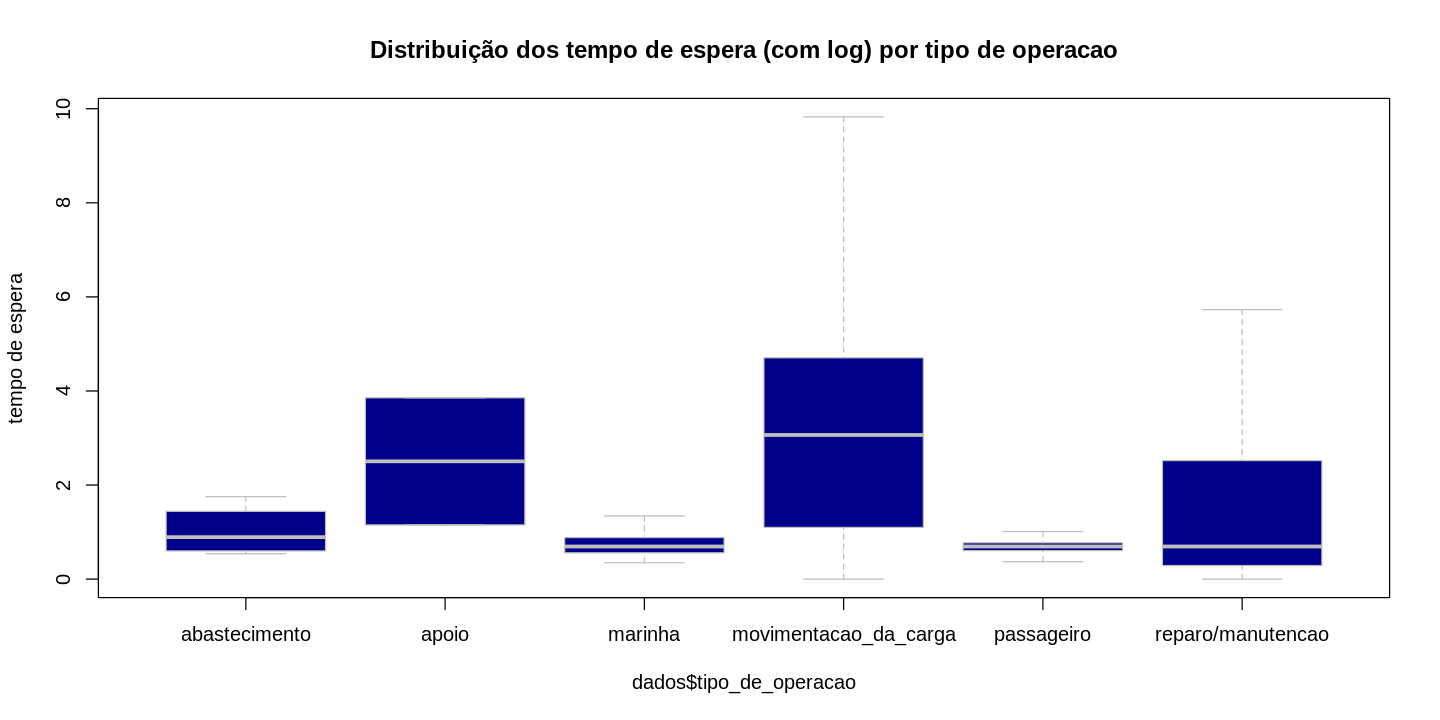

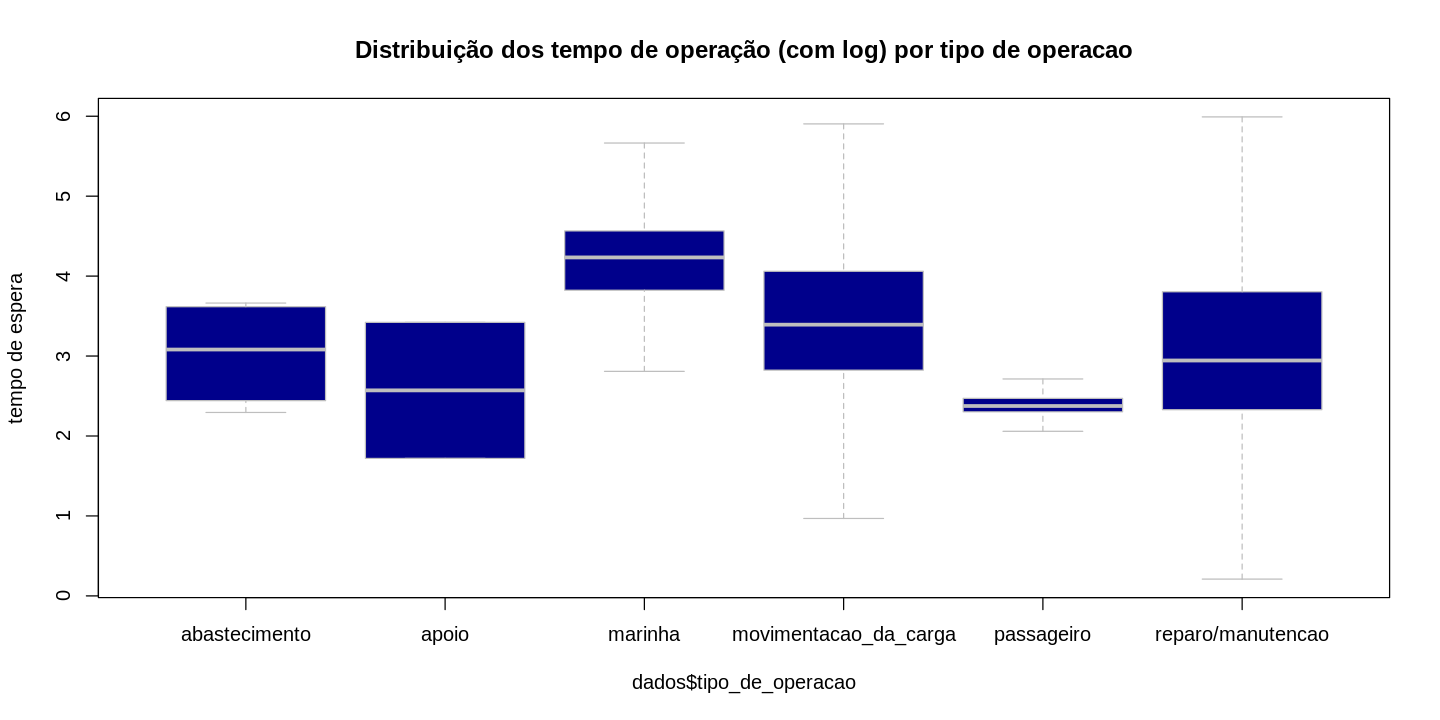

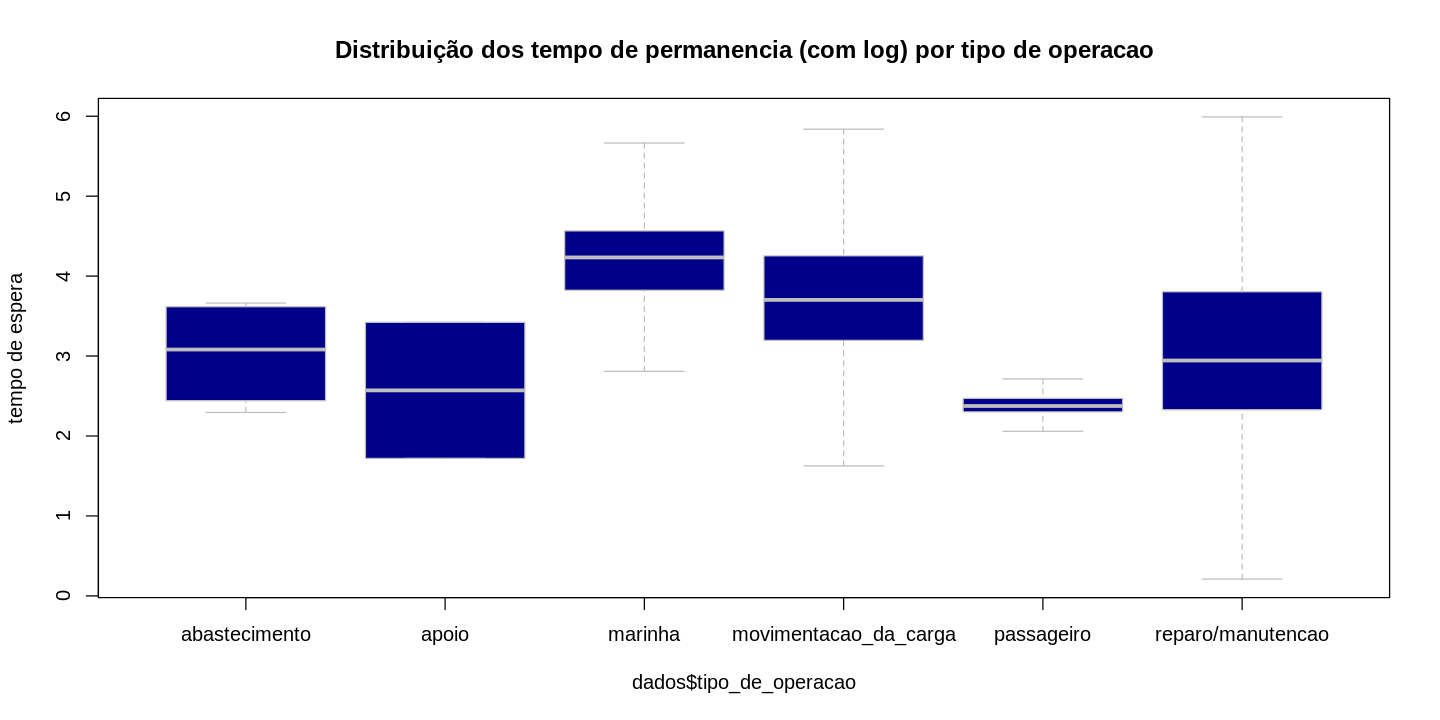

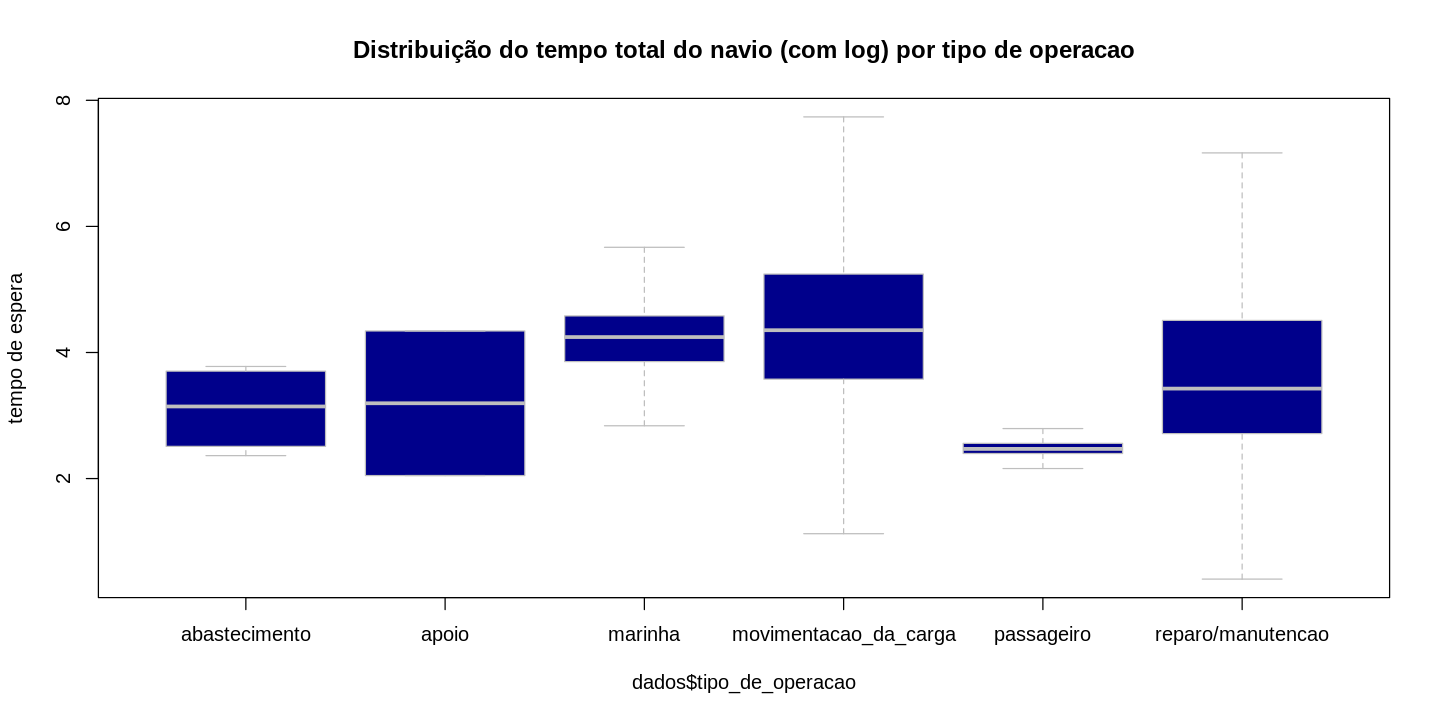

In [33]:
boxplot(dados$log_tempo_espera ~ dados$tipo_de_operacao,
        col = "darkblue",
        border = "grey",
        main = "Distribuição dos tempo de espera (com log) por tipo de operacao",
        ylab = "tempo de espera",
        outline = FALSE
        )

boxplot(dados$log_tempo_operacao ~ dados$tipo_de_operacao,
        col = "darkblue",
        border = "grey",
        main = "Distribuição dos tempo de operação (com log) por tipo de operacao",
        ylab = "tempo de espera",
        outline = FALSE
        )

boxplot(dados$log_tempo_permanencia ~ dados$tipo_de_operacao,
        col = "darkblue",
        border = "grey",
        main = "Distribuição dos tempo de permanencia (com log) por tipo de operacao",
        ylab = "tempo de espera",
        outline = FALSE
        )

boxplot(dados$log_tempo_total_navio ~ dados$tipo_de_operacao,
        col = "darkblue",
        border = "grey",
        main = "Distribuição do tempo total do navio (com log) por tipo de operacao",
        ylab = "tempo de espera",
        outline = FALSE
        )



Graficos de Diperção entre as variaveis temporais (com log)

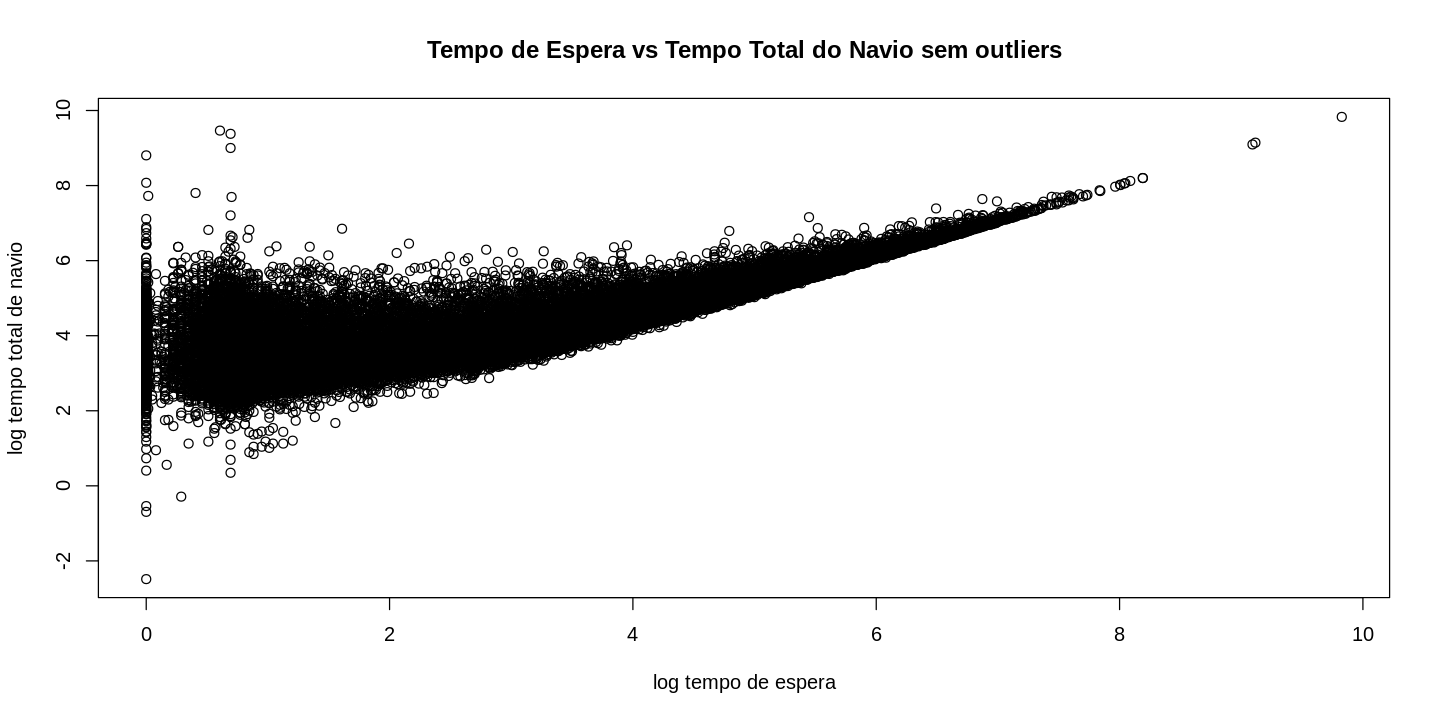

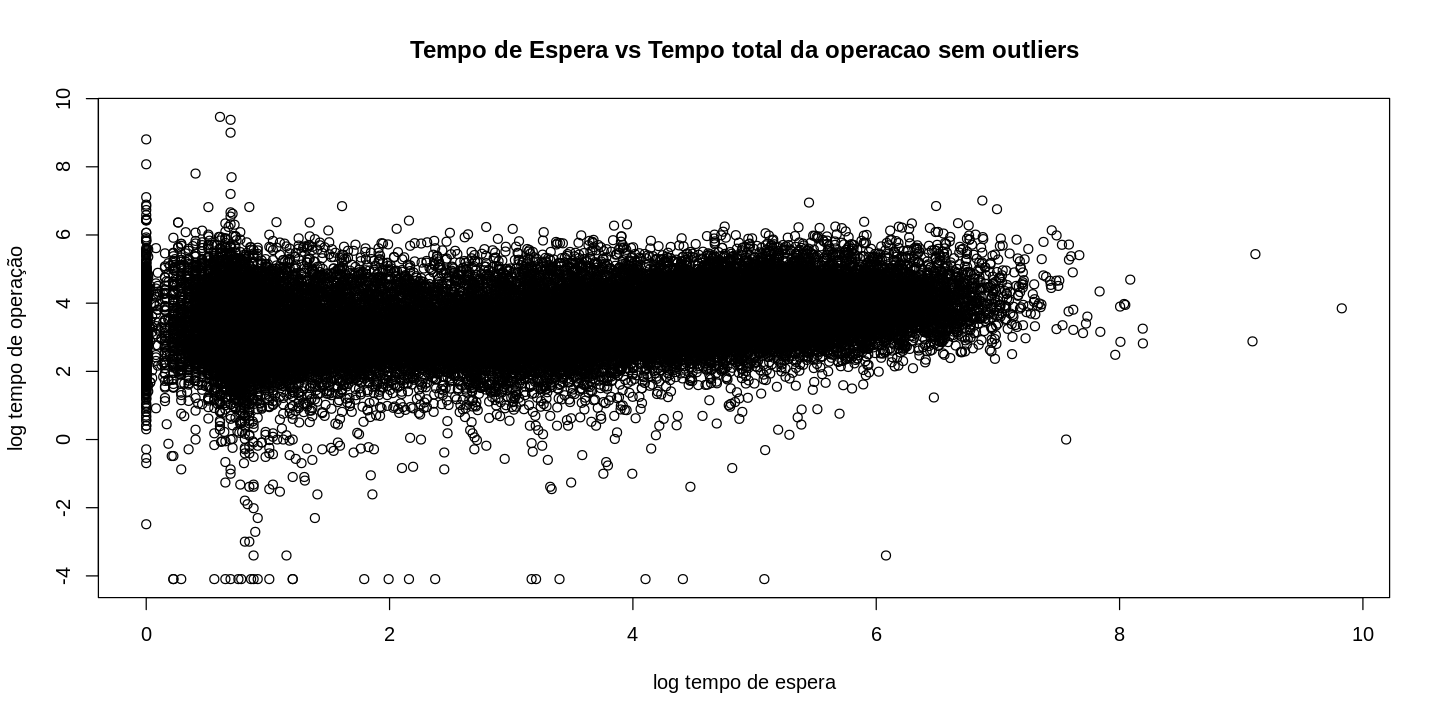

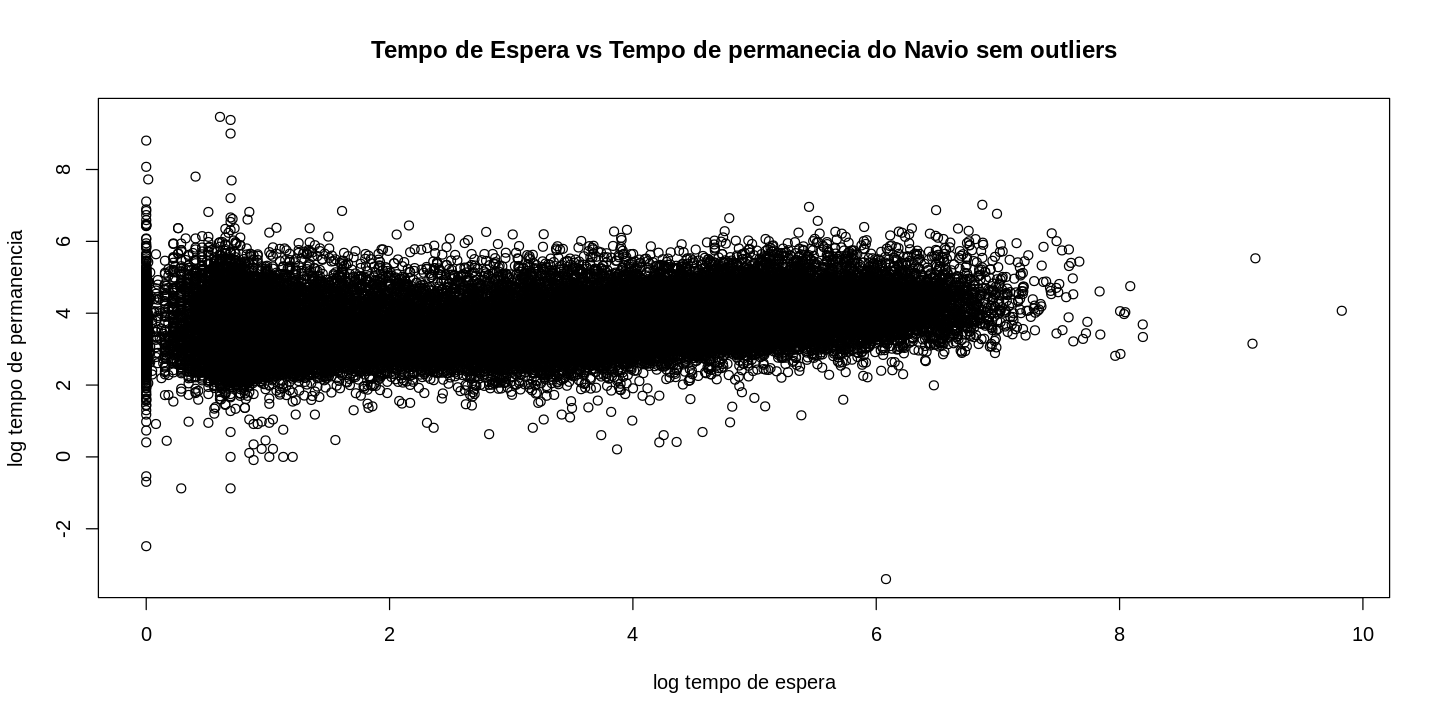

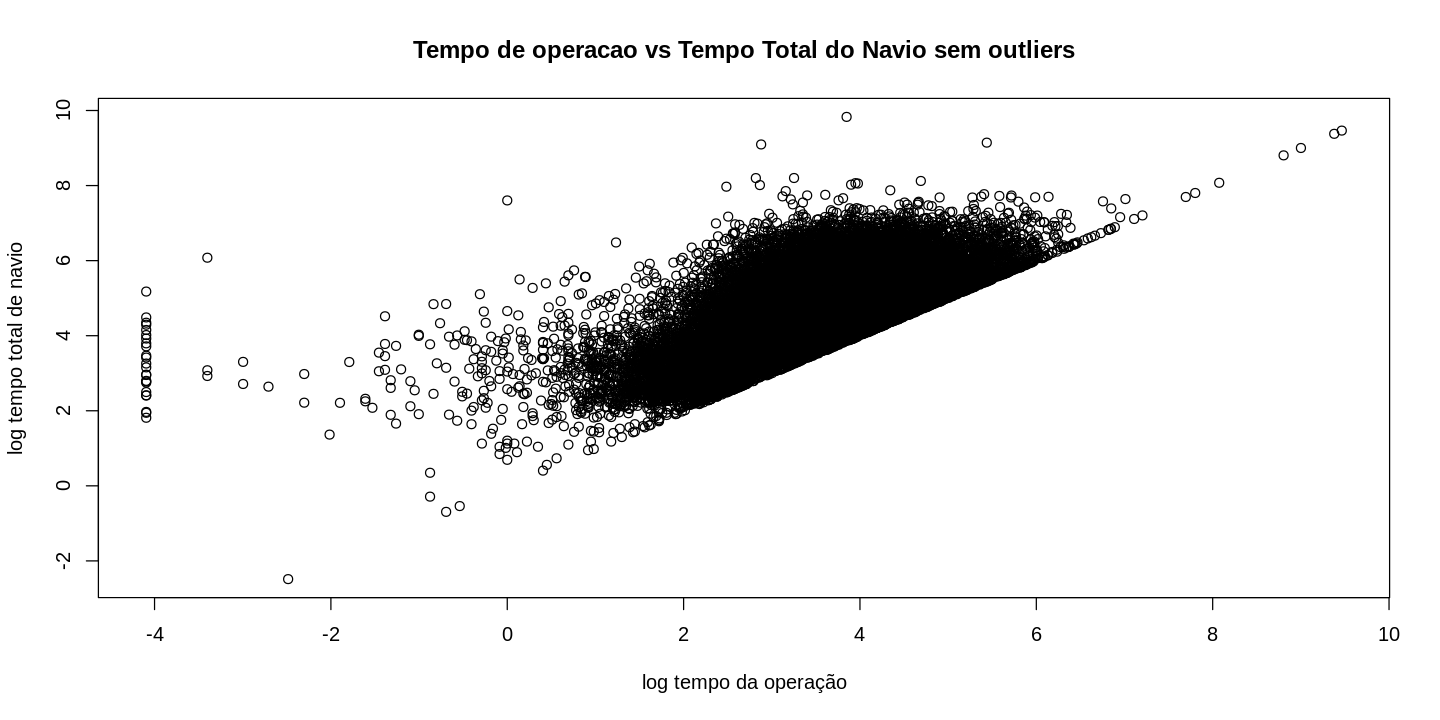

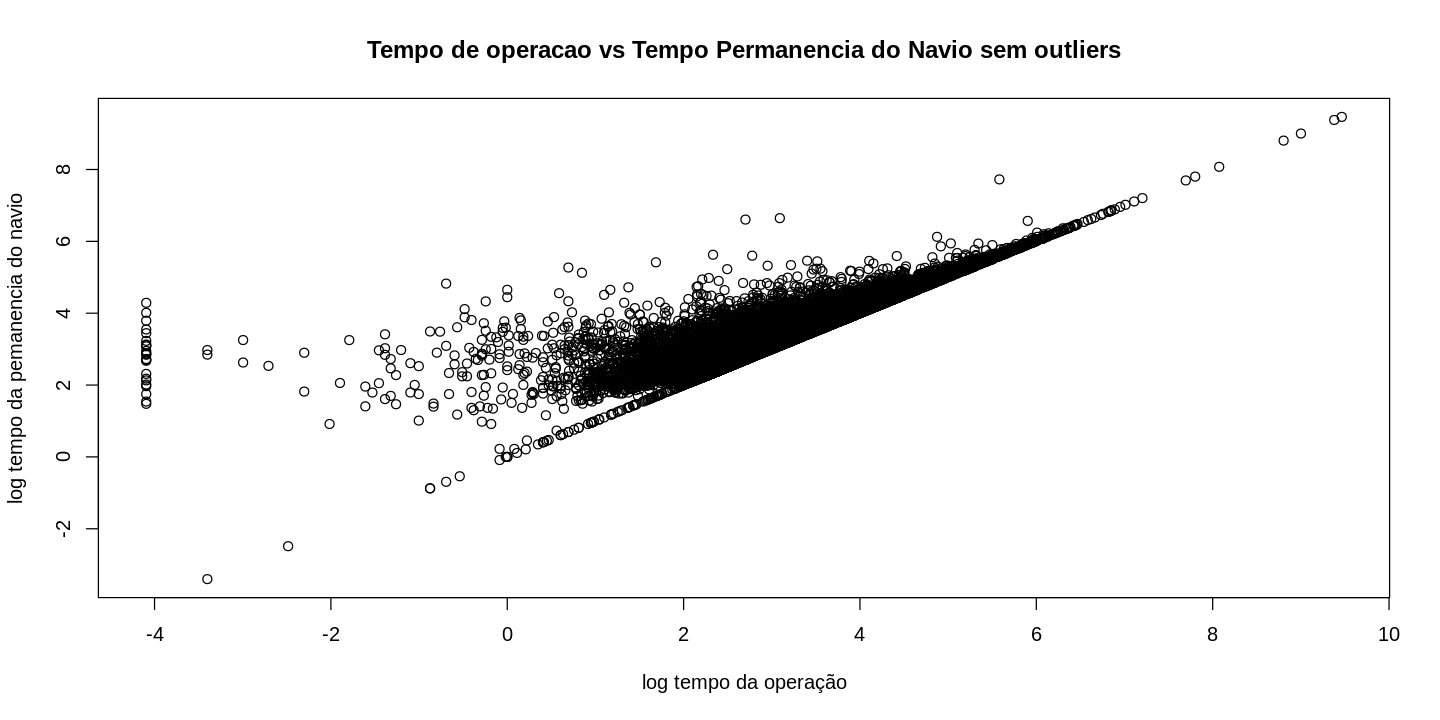

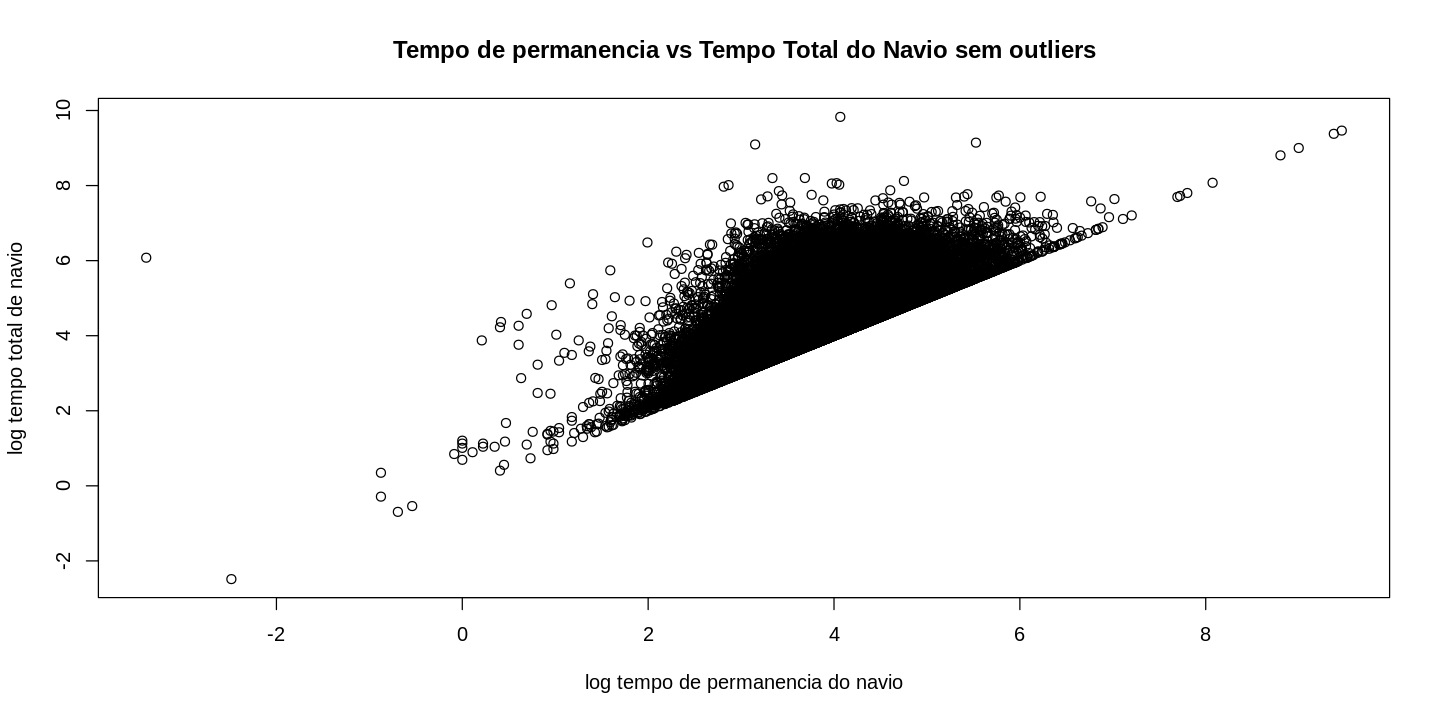

In [37]:
#Grafico de disperção sem outliers

plot(dados$log_tempo_espera, dados$log_tempo_total_navio,
     main = "Tempo de Espera vs Tempo Total do Navio sem outliers",
     xlab = "log tempo de espera",
     ylab = "log tempo total de navio")

plot(dados$log_tempo_espera, dados$log_tempo_operacao,
     main = "Tempo de Espera vs Tempo total da operacao sem outliers",
     xlab = "log tempo de espera",
     ylab = "log tempo de operação")

plot(dados$log_tempo_espera, dados$log_tempo_permanencia,
     main = "Tempo de Espera vs Tempo de permanecia do Navio sem outliers",
     xlab = "log tempo de espera",
     ylab = "log tempo de permanencia")

plot(dados$log_tempo_operacao, dados$log_tempo_total_navio,
     main = "Tempo de operacao vs Tempo Total do Navio sem outliers",
     xlab = "log tempo da operação",
     ylab = "log tempo total de navio")

plot(dados$log_tempo_operacao, dados$log_tempo_permanencia,
     main = "Tempo de operacao vs Tempo Permanencia do Navio sem outliers",
     xlab = "log tempo da operação",
     ylab = "log tempo da pemanencia do navio")

plot(dados$log_tempo_permanencia, dados$log_tempo_total_navio,
     main = "Tempo de permanencia vs Tempo Total do Navio sem outliers",
     xlab = "log tempo de permanencia do navio",
     ylab = "log tempo total de navio")




Graficos de Disperção das variaveis temporais estudadas (sem log)

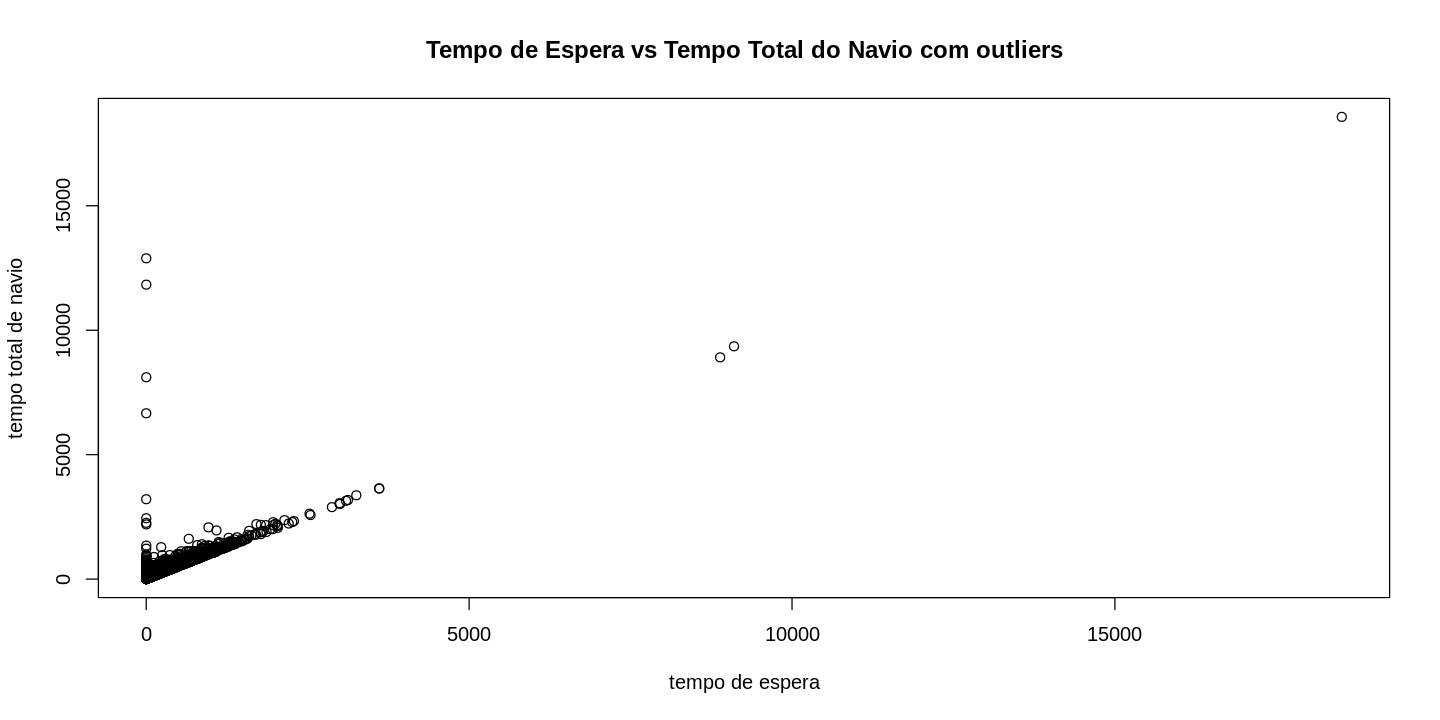

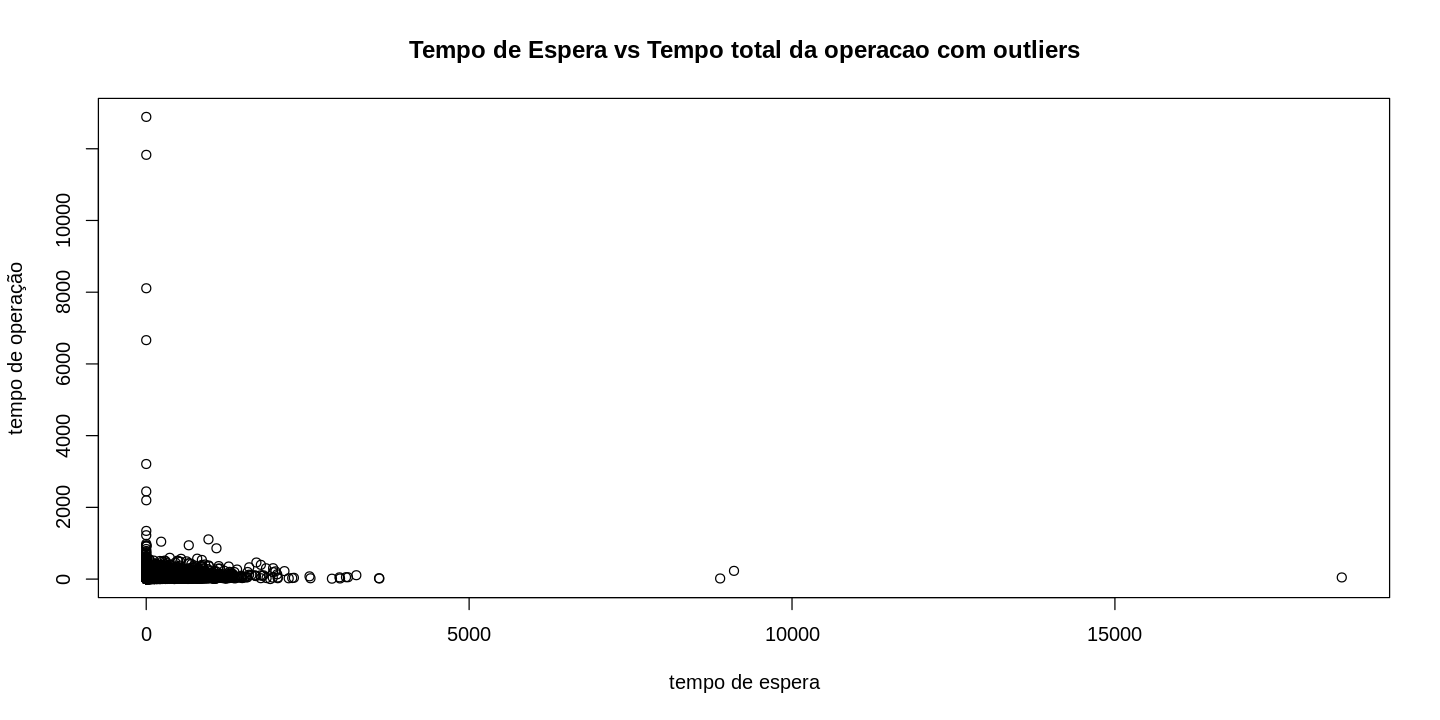

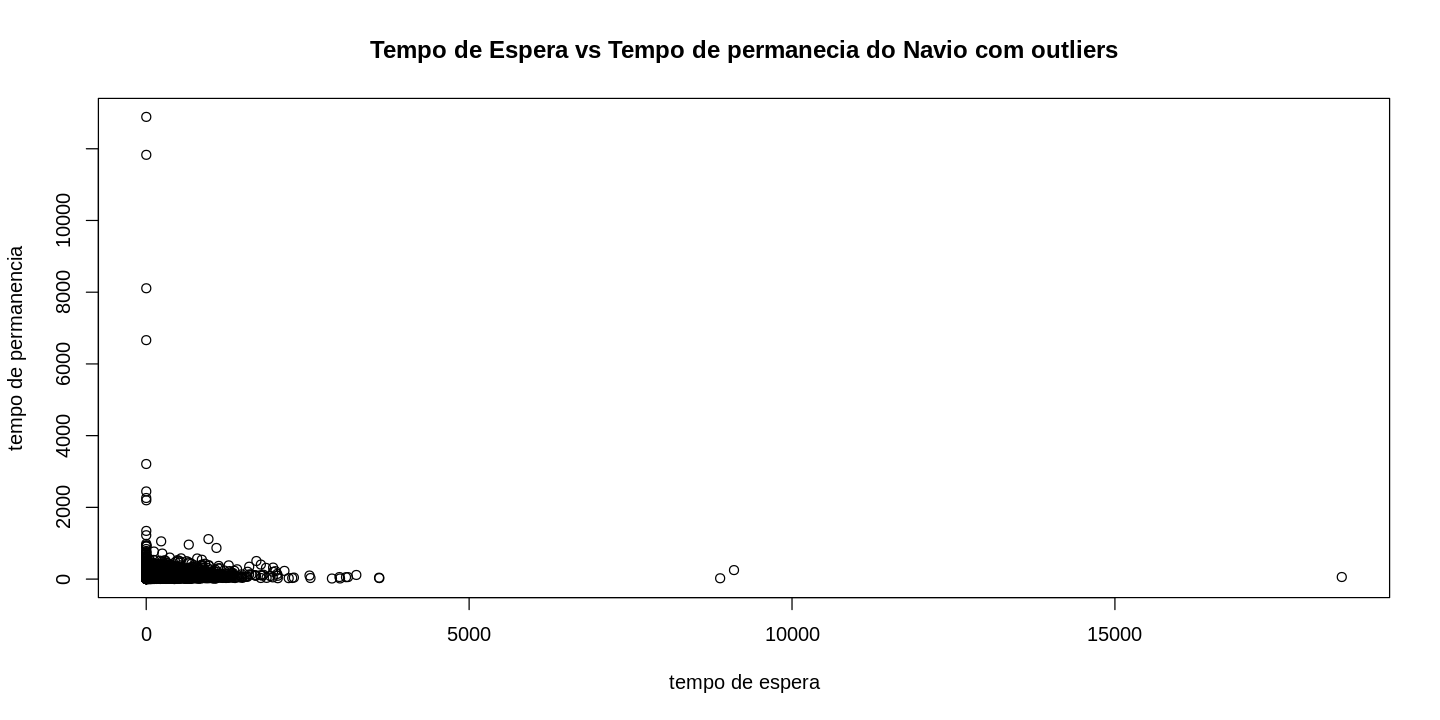

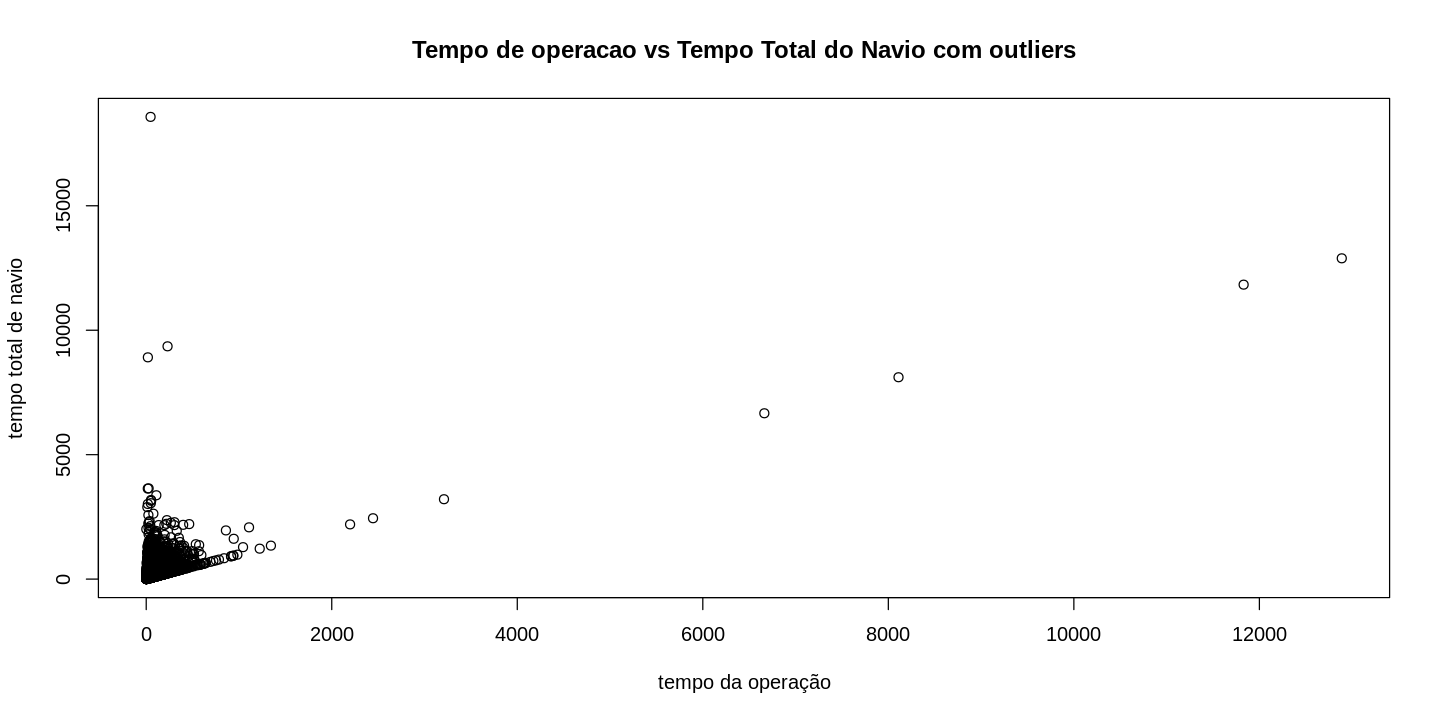

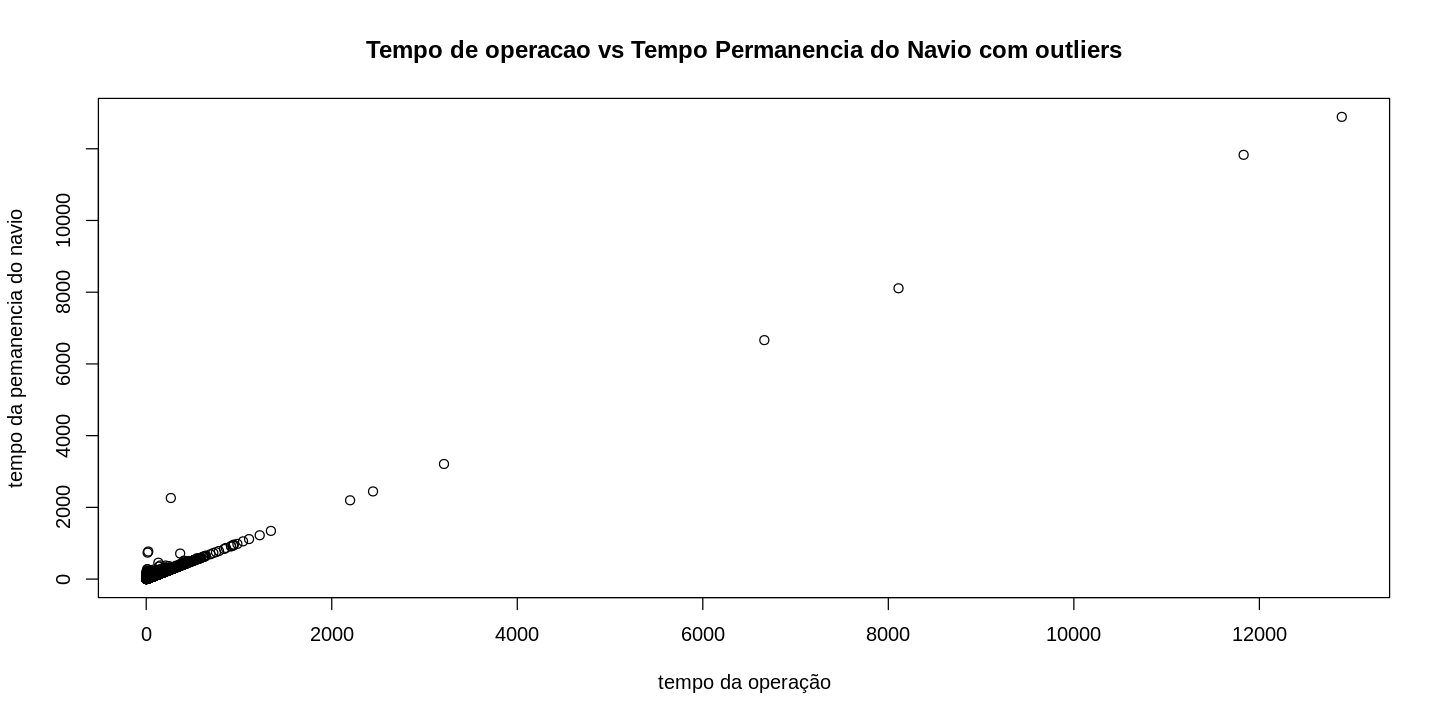

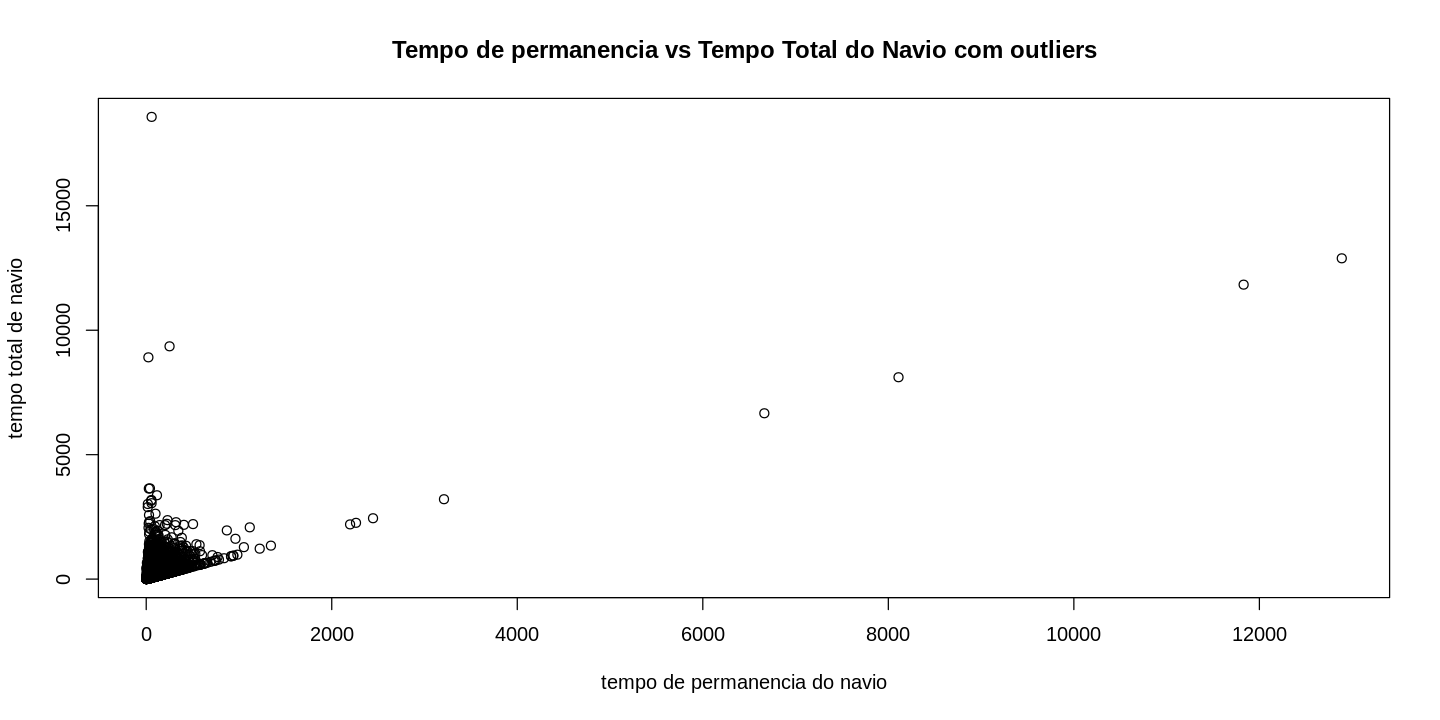

In [38]:
# com outliers
plot(dados$tempo_espera, dados$tempo_total_atracacao,
     main = "Tempo de Espera vs Tempo Total do Navio com outliers",
     xlab = "tempo de espera",
     ylab = "tempo total de navio")

plot(dados$tempo_espera, dados$tempo_operacao,
     main = "Tempo de Espera vs Tempo total da operacao com outliers",
     xlab = "tempo de espera",
     ylab = "tempo de operação")

plot(dados$tempo_espera, dados$tempo_permanencia,
     main = "Tempo de Espera vs Tempo de permanecia do Navio com outliers",
     xlab = "tempo de espera",
     ylab = "tempo de permanencia")

plot(dados$tempo_operacao, dados$tempo_total_atracacao,
     main = "Tempo de operacao vs Tempo Total do Navio com outliers",
     xlab = "tempo da operação",
     ylab = "tempo total de navio")

plot(dados$tempo_operacao, dados$tempo_permanencia,
     main = "Tempo de operacao vs Tempo Permanencia do Navio com outliers",
     xlab = "tempo da operação",
     ylab = "tempo da pemanencia do navio")

plot(dados$tempo_permanencia, dados$tempo_total_atracacao,
     main = "Tempo de permanencia vs Tempo Total do Navio com outliers",
     xlab = "tempo de permanencia do navio",
     ylab = "tempo total de navio")


Verificação da variavel tempo espera para verificar a presença de valores NA ou Inf + -

In [39]:
# Verificação de valores NA ou inf +-

summary(dados$tempo_espera)
summary(dados$log_tempo_espera)

sum(is.na(dados$log_tempo_espera))
sum(is.infinite(dados$log_tempo_espera))

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.000     1.667    17.717    92.053   103.833 18512.833 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.9808  2.9294  2.9523  4.6524  9.8263 

[1] 0

[1] 0

In [40]:
# Retirar outliers das variaveis quantitativas.

remover_outliers <- function(x) {
  Q1 <- quantile(x, 0.25)
  Q3 <- quantile(x, 0.75)
  IQR <- Q3 - Q1

  limite_inf <- Q1 - 1.5 * IQR
  limite_sup <- Q3 + 1.5 * IQR

  return(x >= limite_inf & x <= limite_sup)
}

filtro <- remover_outliers(dados$tempo_espera) &
          remover_outliers(dados$tempo_operacao) &
          remover_outliers(dados$tempo_permanencia) &
          remover_outliers(dados$tempo_total_atracacao) &
          remover_outliers(dados$log_tempo_espera) &
          remover_outliers(dados$log_tempo_operacao) &
          remover_outliers(dados$log_tempo_permanencia)

dados_filtro <- dados[filtro,]

Graficos simplicados para o PI

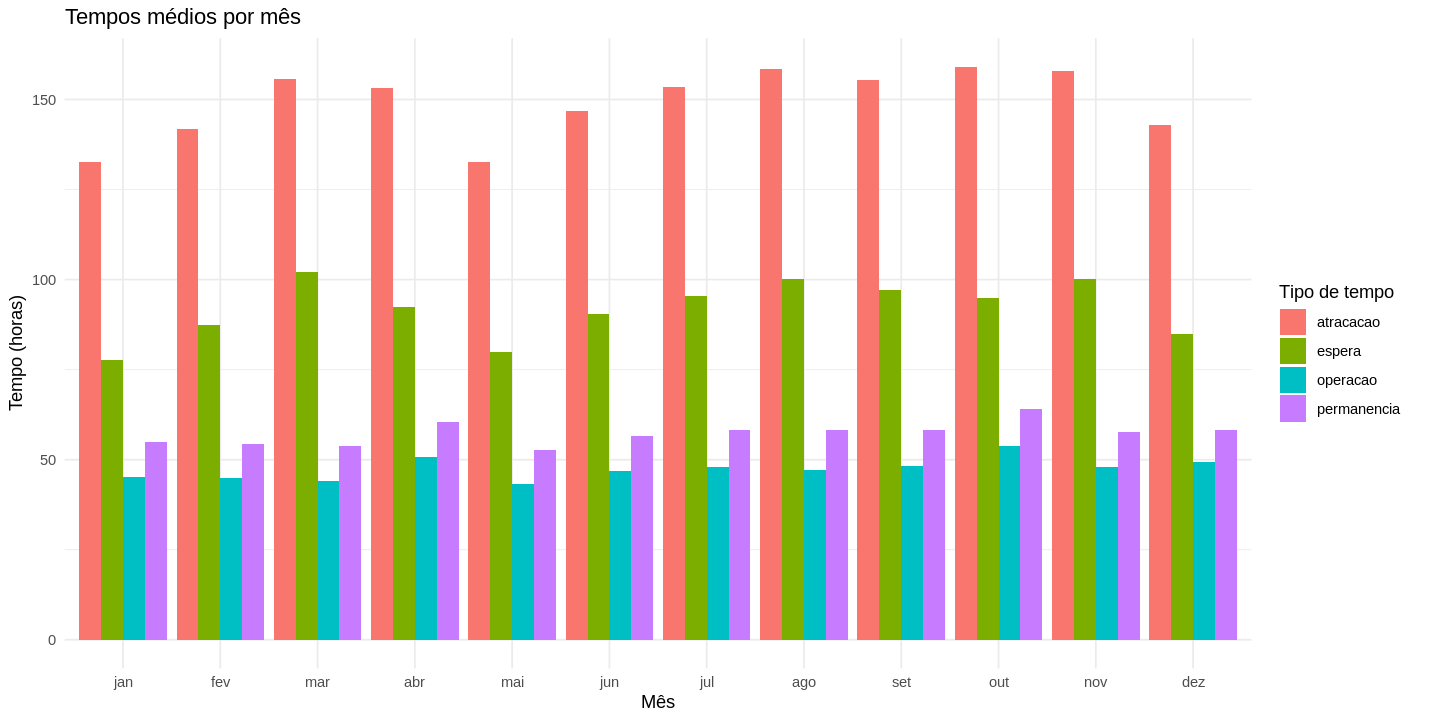

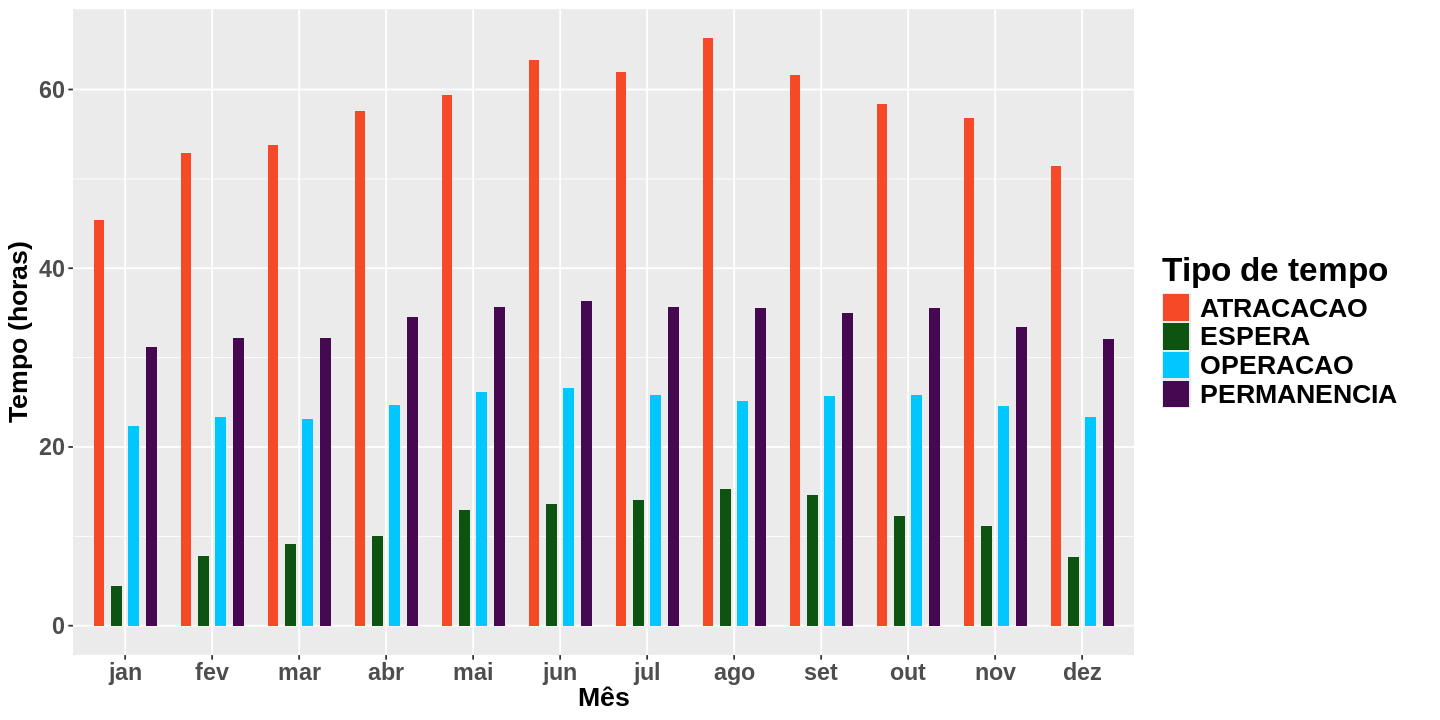

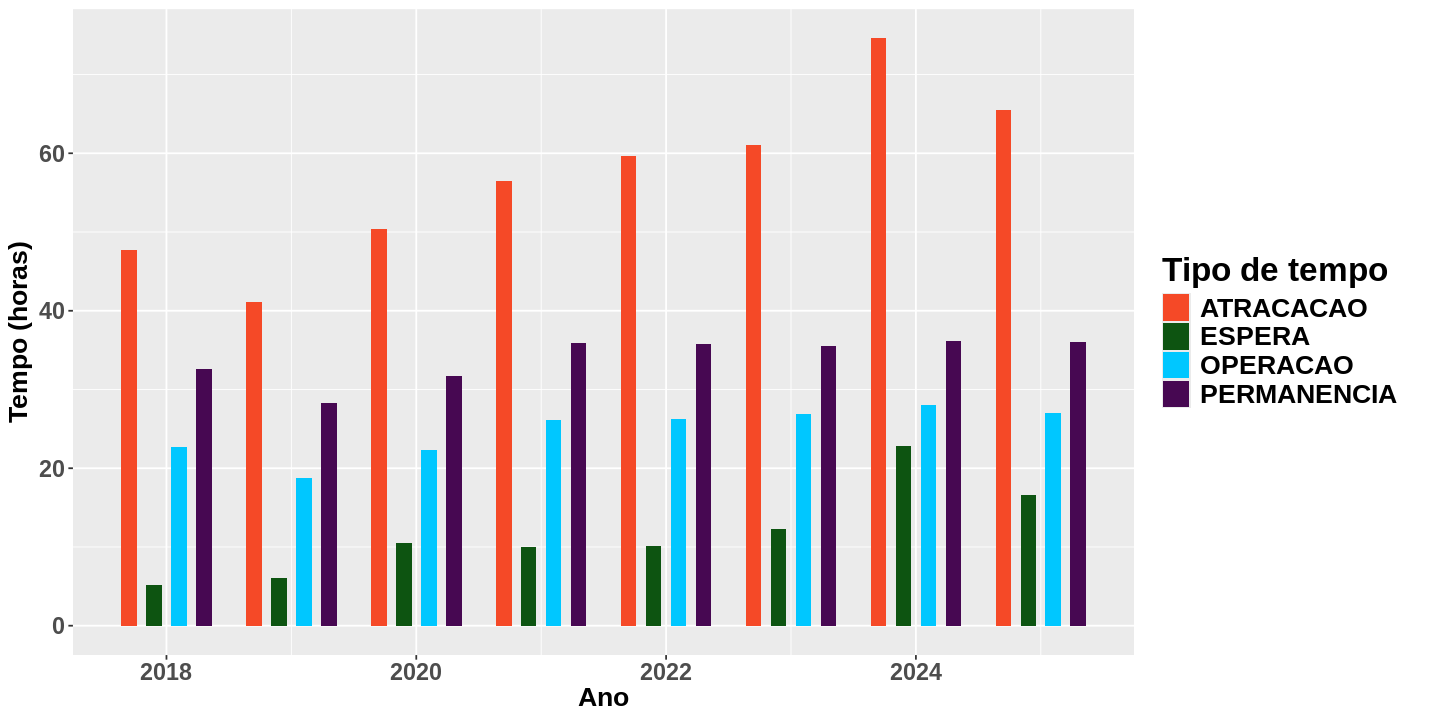

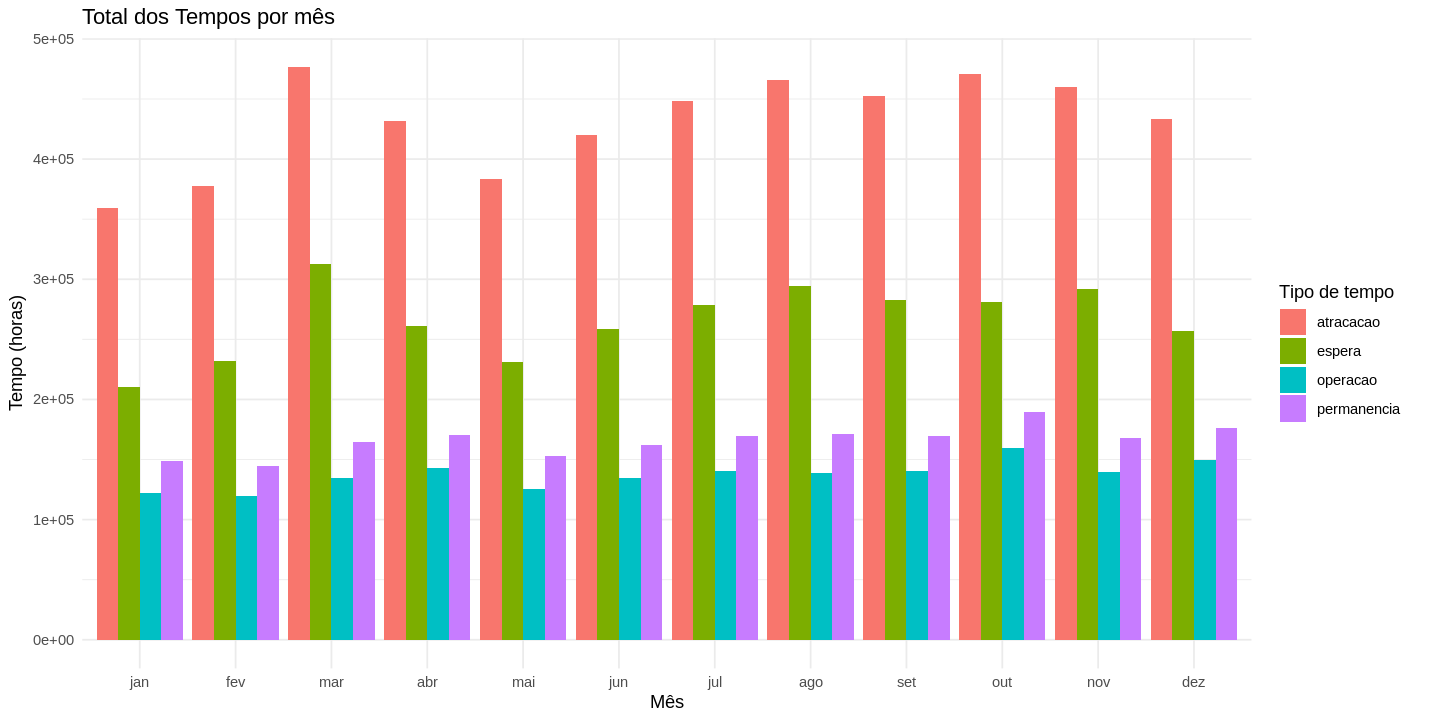

In [41]:
#Mensais

# biblioteca diplr

dados_resumo <- dados %>%
  group_by(mes) %>%
  summarise(
    permanencia = mean(tempo_permanencia, na.rm = TRUE),
    atracacao = mean(tempo_total_atracacao, na.rm = TRUE),
    operacao = mean(tempo_operacao, na.rm = TRUE),
    espera = mean(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -mes,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = mes, y = valor, fill = tipo_tempo)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Tempos médios por mês",
    x = "Mês",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()


# biblioteca diplr

dados_resumo <- dados_filtro %>%
  group_by(mes) %>%
  summarise(
    permanencia = median(tempo_permanencia, na.rm = TRUE),
    atracacao = median(tempo_total_atracacao, na.rm = TRUE),
    operacao = median(tempo_operacao, na.rm = TRUE),
    espera = median(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -mes,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = mes, y = valor, fill = toupper(tipo_tempo))) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.5) +
  labs(
    x = "Mês",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme(
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 16, face = "bold")
  )+
    scale_fill_manual(
    values = c("#F54927",
    "#0D5411",
    "#00C7FF",
    "#470852")
    )


# biblioteca diplr

dados_resumo <- dados_filtro %>%
  group_by(ano) %>%
  summarise(
    permanencia = median(tempo_permanencia, na.rm = TRUE),
    atracacao = median(tempo_total_atracacao, na.rm = TRUE),
    operacao = median(tempo_operacao, na.rm = TRUE),
    espera = median(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -ano,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = ano, y = valor, fill = toupper(tipo_tempo))) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.5) +
  labs(
    x = "Ano",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme(
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size = 14, face = "bold"),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 16, face = "bold")
  )+
    scale_fill_manual(
    values = c("#F54927",
    "#0D5411",
    "#00C7FF",
    "#470852")
    )

# biblioteca diplr

dados_resumo <- dados %>%
  group_by(mes) %>%
  summarise(
    permanencia = sum(tempo_permanencia, na.rm = TRUE),
    atracacao = sum(tempo_total_atracacao, na.rm = TRUE),
    operacao = sum(tempo_operacao, na.rm = TRUE),
    espera = sum(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -mes,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = mes, y = valor, fill = tipo_tempo)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Total dos Tempos por mês",
    x = "Mês",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()

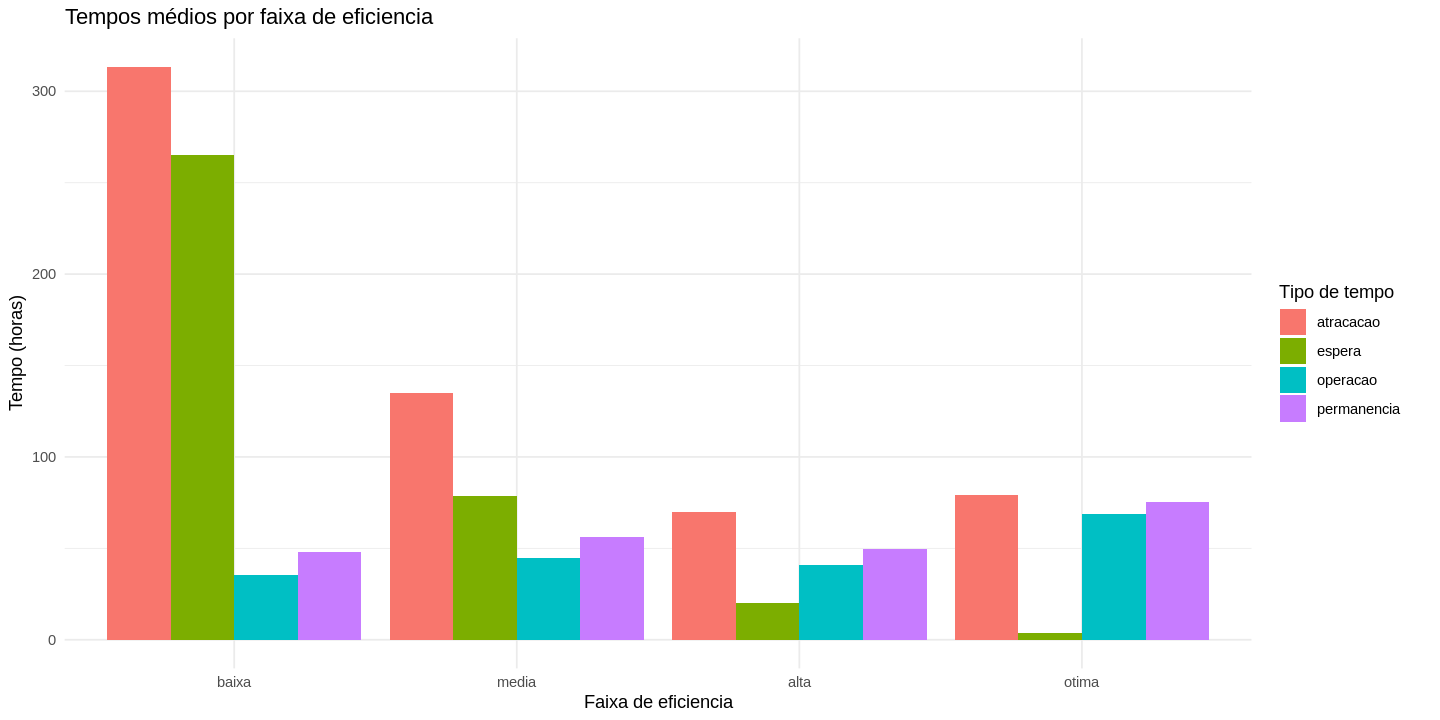

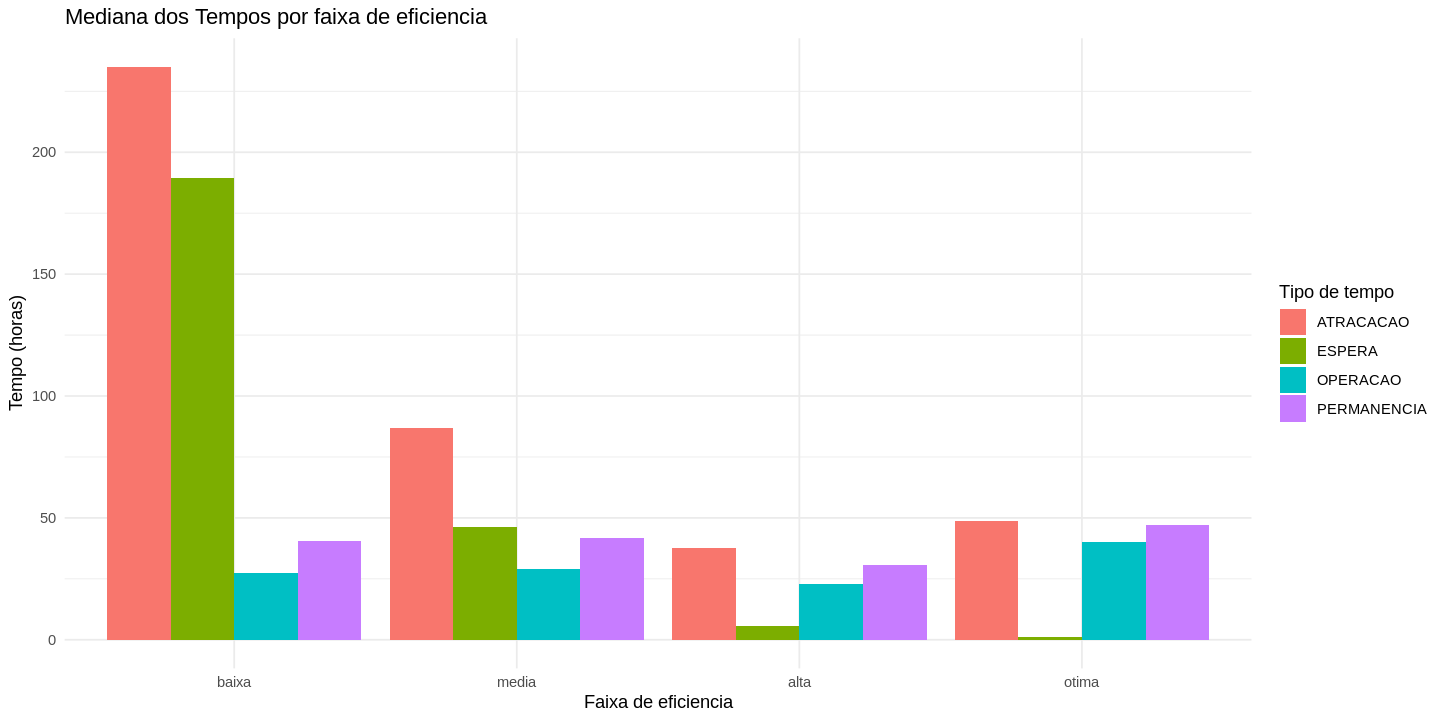

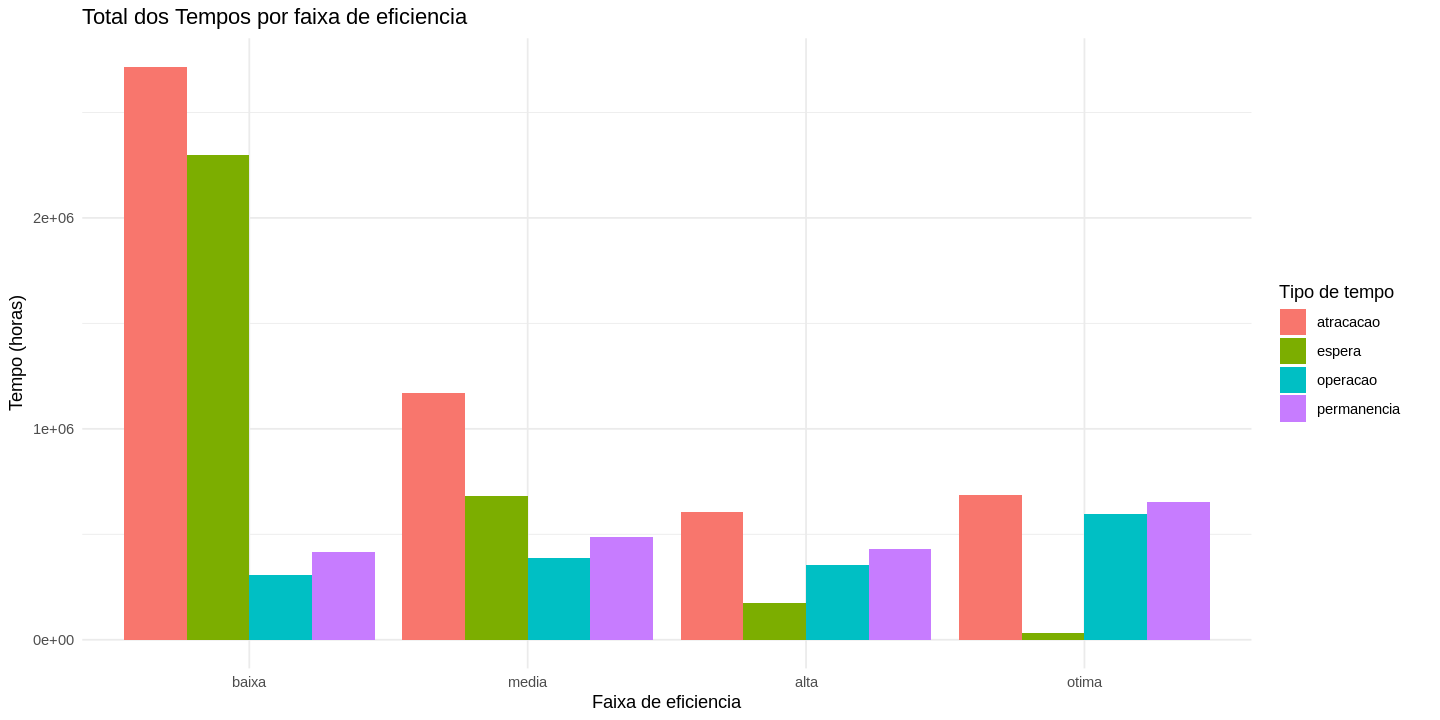

In [42]:
#Analise baseado na faixa de eficiencia

dados_resumo <- dados %>%
  group_by(faixa_eficiencia) %>%
  summarise(
    permanencia = mean(tempo_permanencia, na.rm = TRUE),
    atracacao = mean(tempo_total_atracacao, na.rm = TRUE),
    operacao = mean(tempo_operacao, na.rm = TRUE),
    espera = mean(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -faixa_eficiencia,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = faixa_eficiencia, y = valor, fill = tipo_tempo)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Tempos médios por faixa de eficiencia",
    x = "Faixa de eficiencia",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()


# biblioteca diplr

dados_resumo <- dados %>%
  group_by(faixa_eficiencia) %>%
  summarise(
    permanencia = median(tempo_permanencia, na.rm = TRUE),
    atracacao = median(tempo_total_atracacao, na.rm = TRUE),
    operacao = median(tempo_operacao, na.rm = TRUE),
    espera = median(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -faixa_eficiencia,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = faixa_eficiencia, y = valor, fill = toupper(tipo_tempo))) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Mediana dos Tempos por faixa de eficiencia",
    x = "Faixa de eficiencia",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()

# biblioteca diplr

dados_resumo <- dados %>%
  group_by(faixa_eficiencia) %>%
  summarise(
    permanencia = sum(tempo_permanencia, na.rm = TRUE),
    atracacao = sum(tempo_total_atracacao, na.rm = TRUE),
    operacao = sum(tempo_operacao, na.rm = TRUE),
    espera = sum(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -faixa_eficiencia,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = faixa_eficiencia, y = valor, fill = tipo_tempo)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Total dos Tempos por faixa de eficiencia",
    x = "Faixa de eficiencia",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()

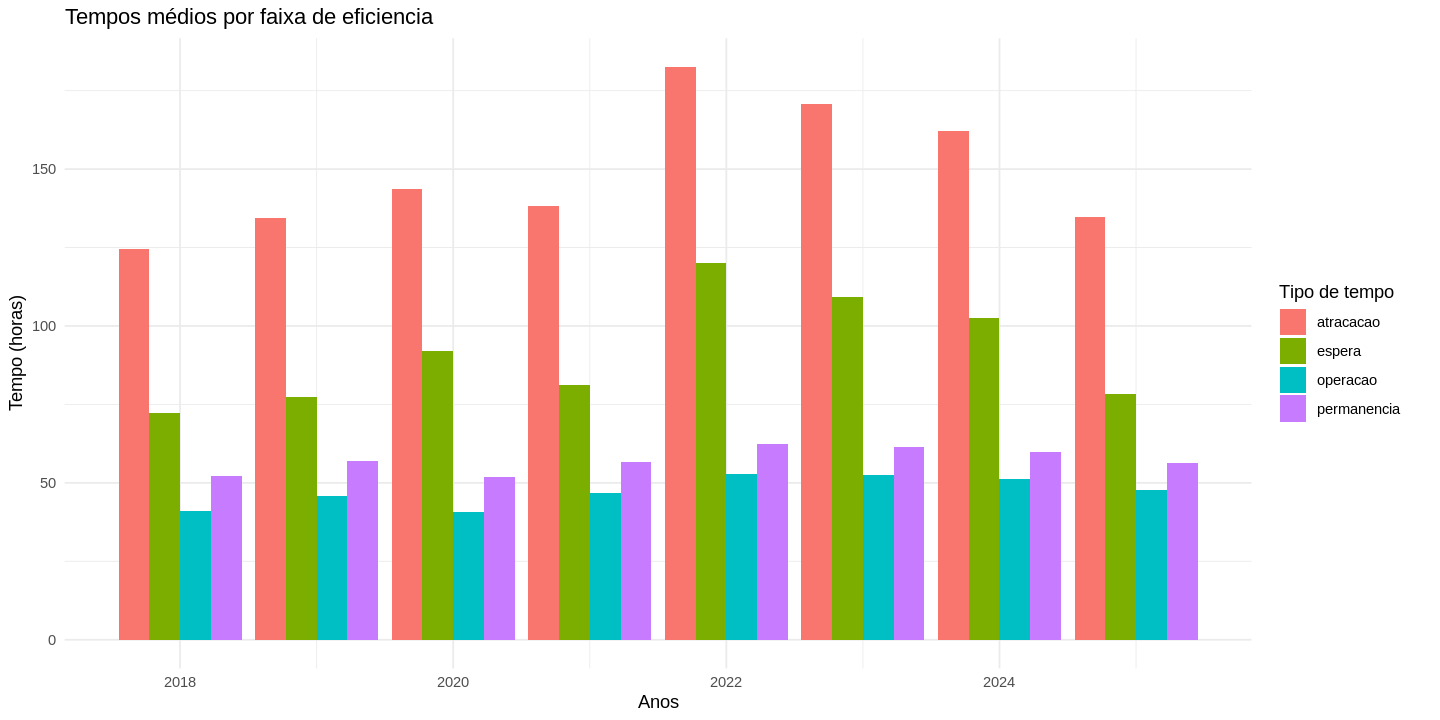

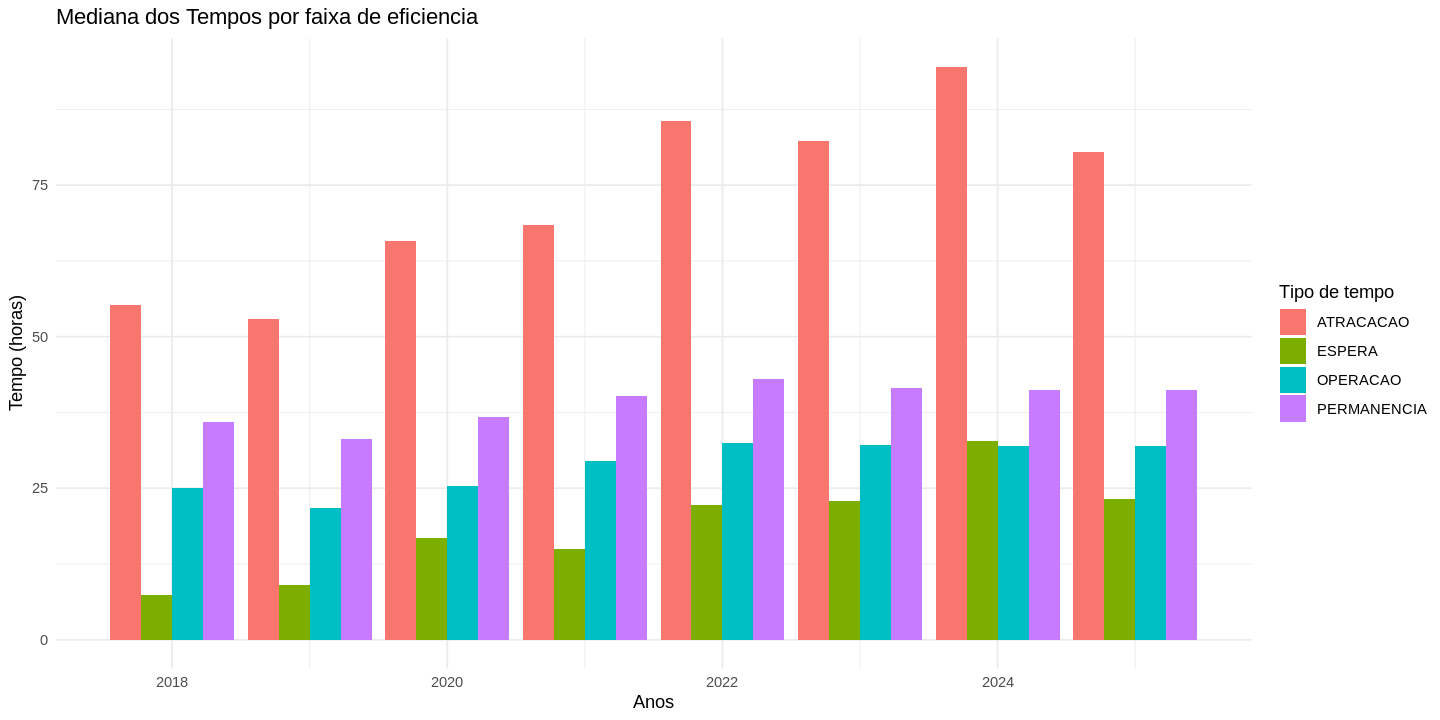

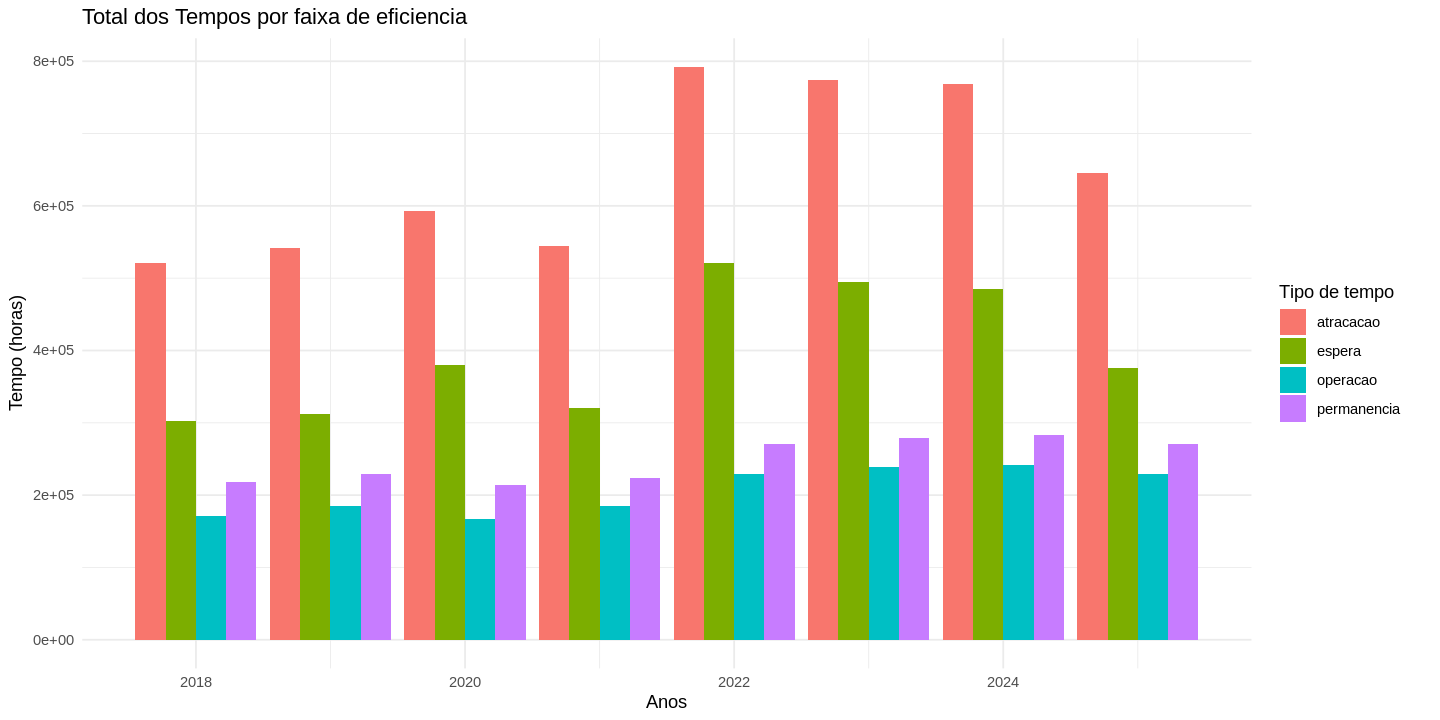

In [43]:
#Analise por anos

dados_resumo <- dados %>%
  group_by(ano) %>%
  summarise(
    permanencia = mean(tempo_permanencia, na.rm = TRUE),
    atracacao = mean(tempo_total_atracacao, na.rm = TRUE),
    operacao = mean(tempo_operacao, na.rm = TRUE),
    espera = mean(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -ano,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = ano, y = valor, fill = tipo_tempo)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Tempos médios por faixa de eficiencia",
    x = "Anos",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()


# biblioteca diplr

dados_resumo <- dados %>%
  group_by(ano) %>%
  summarise(
    permanencia = median(tempo_permanencia, na.rm = TRUE),
    atracacao = median(tempo_total_atracacao, na.rm = TRUE),
    operacao = median(tempo_operacao, na.rm = TRUE),
    espera = median(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -ano,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = ano, y = valor, fill = toupper(tipo_tempo))) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Mediana dos Tempos por faixa de eficiencia",
    x = "Anos",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()

# biblioteca diplr

dados_resumo <- dados %>%
  group_by(ano) %>%
  summarise(
    permanencia = sum(tempo_permanencia, na.rm = TRUE),
    atracacao = sum(tempo_total_atracacao, na.rm = TRUE),
    operacao = sum(tempo_operacao, na.rm = TRUE),
    espera = sum(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -ano,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = ano, y = valor, fill = tipo_tempo)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(
    title = "Total dos Tempos por faixa de eficiencia",
    x = "Anos",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme_minimal()


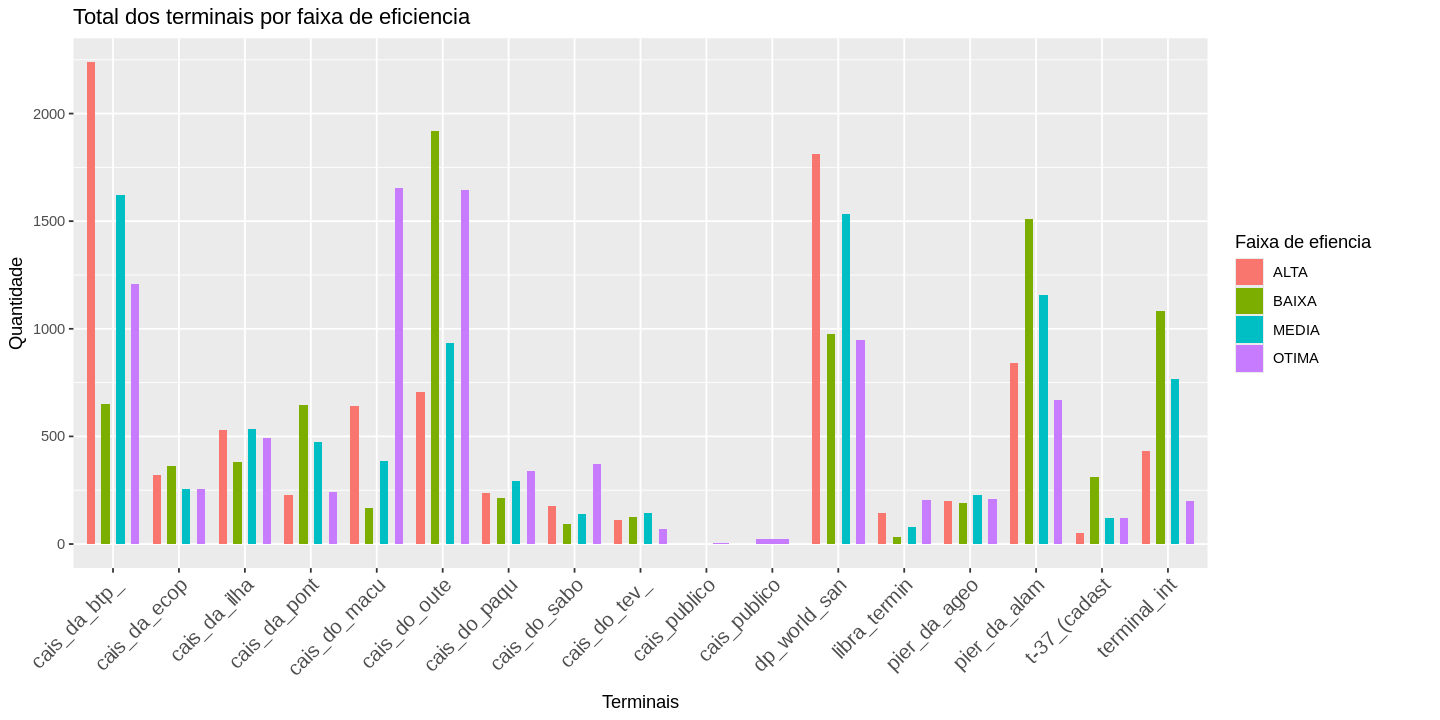

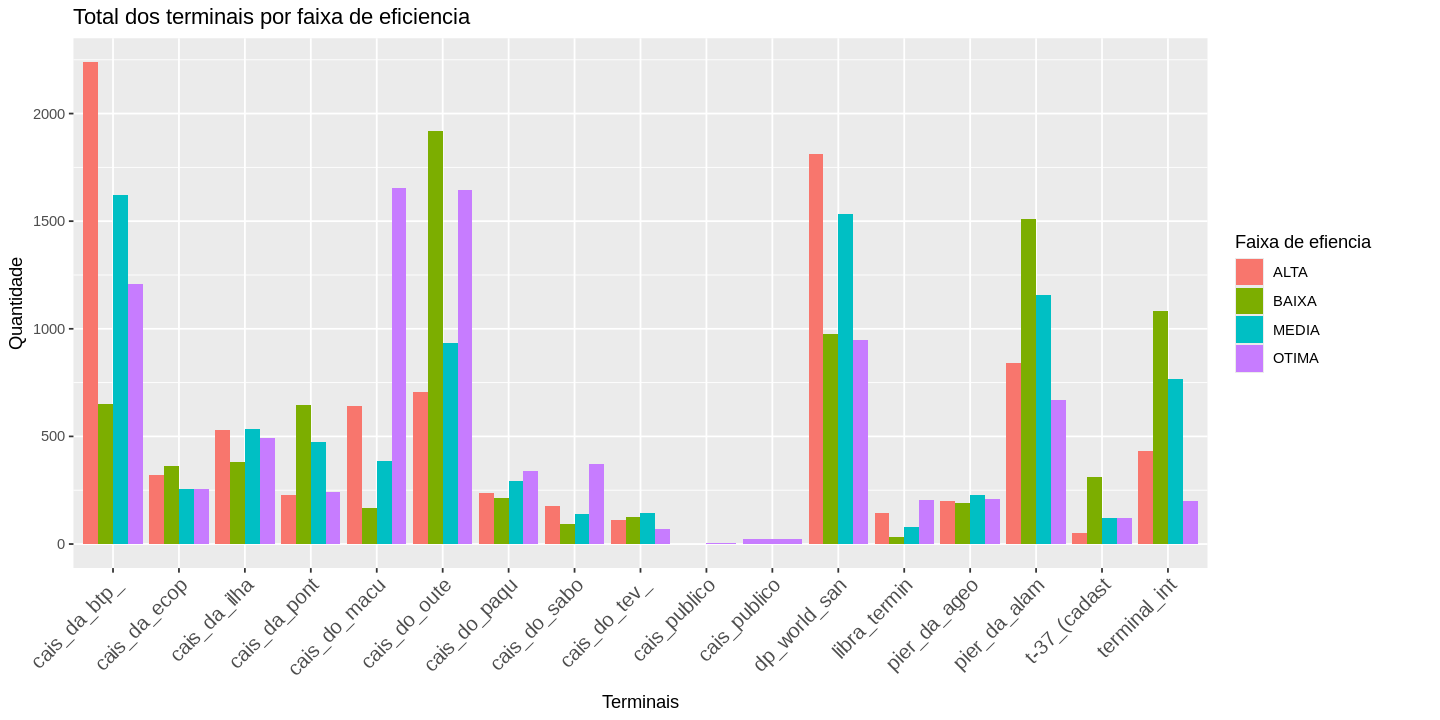

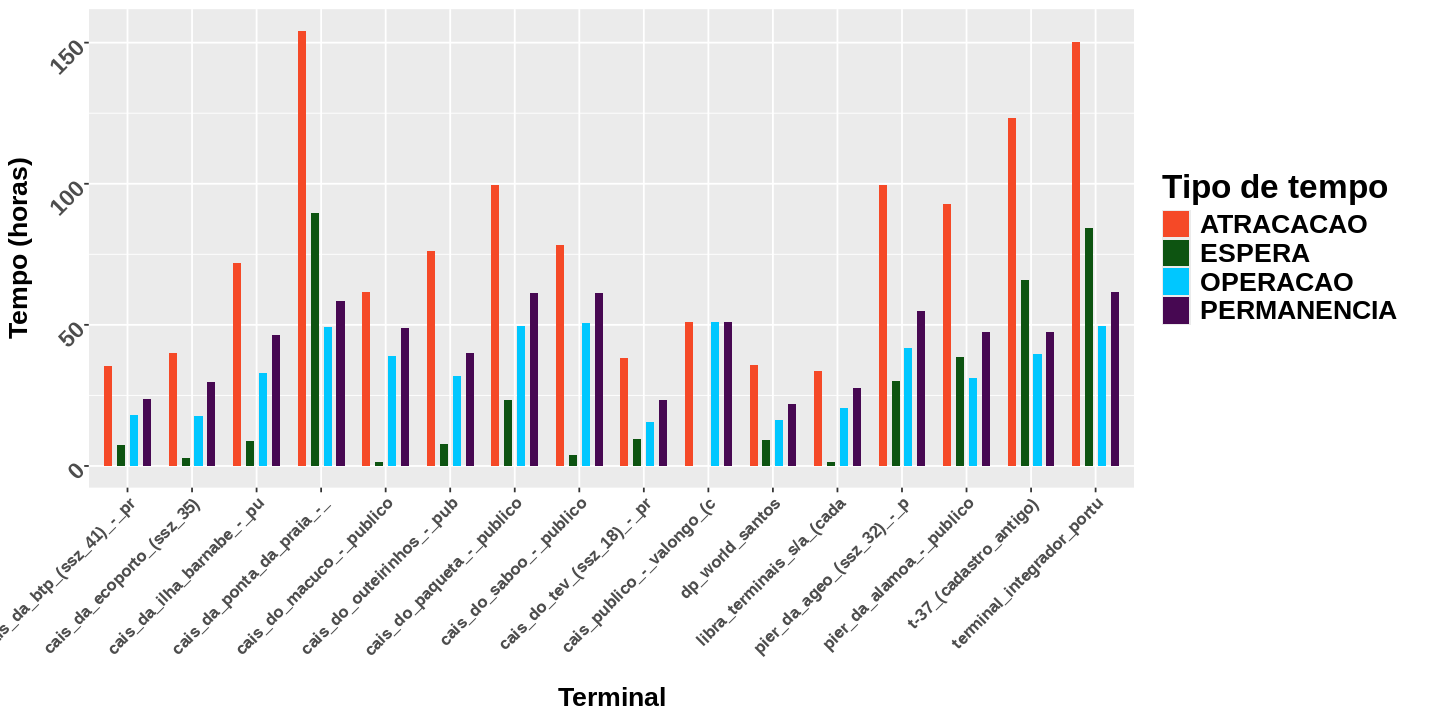

In [44]:
# grafico entre variaveis qualitativas:

ggplot(dados, aes(x = terminal, fill = toupper(faixa_eficiencia))
)+
  geom_bar(position = position_dodge(width = 0.9), width = 0.5)+
  labs(
    title = "Total dos terminais por faixa de eficiencia",
    x = "Terminais",
    y = "Quantidade",
    fill = "Faixa de efiencia"
  ) +
  theme(axis.text.x = element_text(size = 12, angle = 45, hjust = 1))+
  scale_x_discrete(labels = function(x) substr(x, 1, 12))


ggplot(dados, aes(x = terminal, fill = toupper(faixa_eficiencia))
)+
  geom_bar(width = 0.9, position = "dodge")+
  labs(
    title = "Total dos terminais por faixa de eficiencia",
    x = "Terminais",
    y = "Quantidade",
    fill = "Faixa de efiencia"
  ) +
  theme(axis.text.x = element_text(size = 12, angle = 45, hjust = 1))+
  scale_x_discrete(labels = function(x) substr(x, 1, 12))

# biblioteca diplr

dados_resumo <- dados_filtro %>%
  group_by(terminal) %>%
  summarise(
    permanencia = median(tempo_permanencia, na.rm = TRUE),
    atracacao = median(tempo_total_atracacao, na.rm = TRUE),
    operacao = median(tempo_operacao, na.rm = TRUE),
    espera = median(tempo_espera, na.rm = TRUE)
  )

# biblioteca tidyr

dados_long <- dados_resumo %>%
  pivot_longer(cols = -terminal,
               names_to = "tipo_tempo",
               values_to = "valor")


ggplot(dados_long, aes(x = terminal, y = valor, fill = toupper(tipo_tempo))) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.5) +
  labs(
    x = "Terminal",
    y = "Tempo (horas)",
    fill = "Tipo de tempo"
  ) +
  theme(
    axis.text.x = element_text(size = 10, face = "bold", angle = 45, hjust = 1),
    axis.text.y = element_text(size = 14, face = "bold", angle = 45),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size = 16, face = "bold")
  )+
  scale_x_discrete(labels = function(x) substr(x, 1,25)
)+
    scale_fill_manual(
    values = c("#F54927",
    "#0D5411",
    "#00C7FF",
    "#470852")
    )

# ggplot(dados, aes(x = berco, fill = faixa_eficiencia)
# )+
#   geom_bar(width = 0.4)+
#   labs(
#     title = "Total dos berços(por codigo de identificação) por faixa de eficiencia",
#     x = "",
#     y = "Frequencia",
#     fill = "Faixa de efiencia"
#   ) +
#   theme(axis.text.x = element_text(size = 7, angle = 90, hjust = 1))+
#   scale_x_discrete(labels = function(x) substr(x, 1, 10))

# ggplot(dados, aes(x = berco, fill = faixa_eficiencia)
# )+
#   geom_bar(width = 0.4, position = "dodge")+
#   labs(
#     title = "Total dos berços(por codigo de identificação) por faixa de eficiencia",
#     x = "",
#     y = "Frequencia",
#     fill = "Faixa de efiencia"
#   ) +
#   theme(axis.text.x = element_text(size = 7, angle = 90, hjust = 1))+
#   scale_x_discrete(labels = function(x) substr(x, 1, 10))

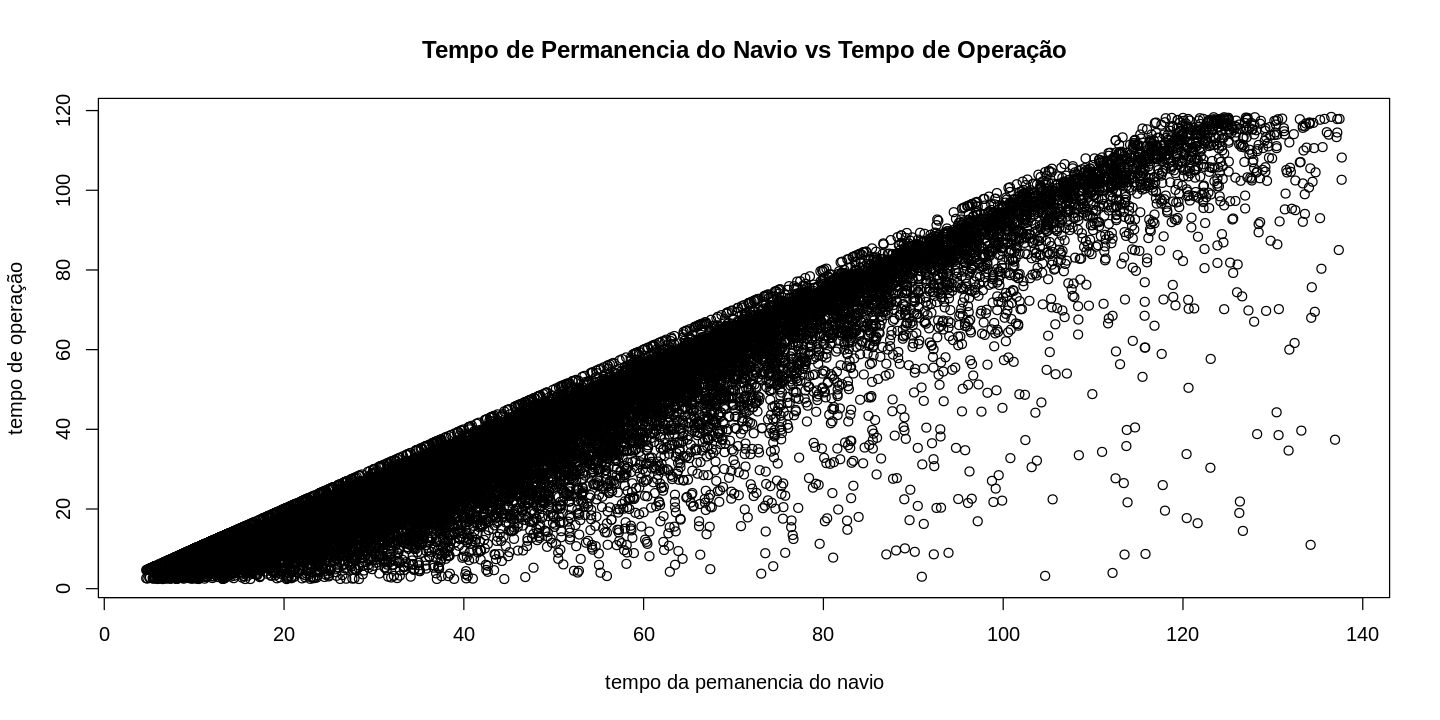

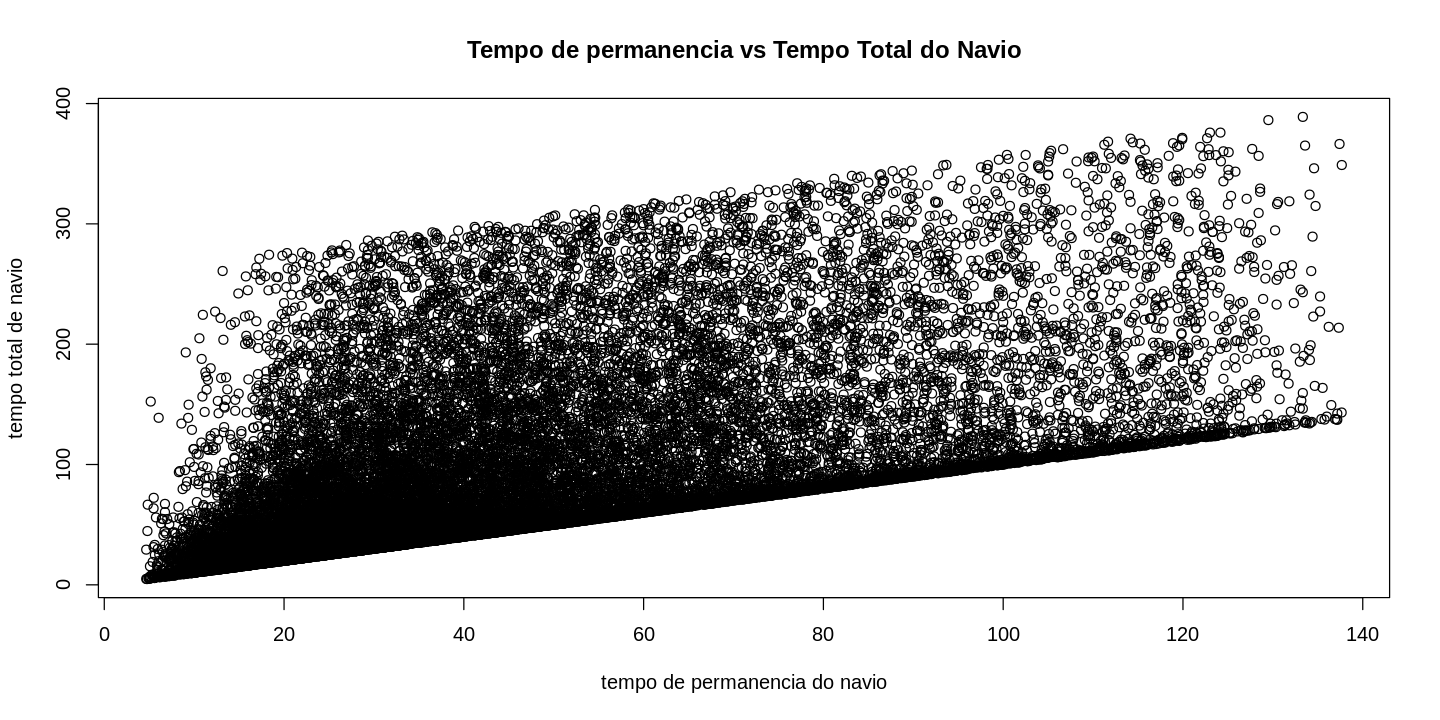

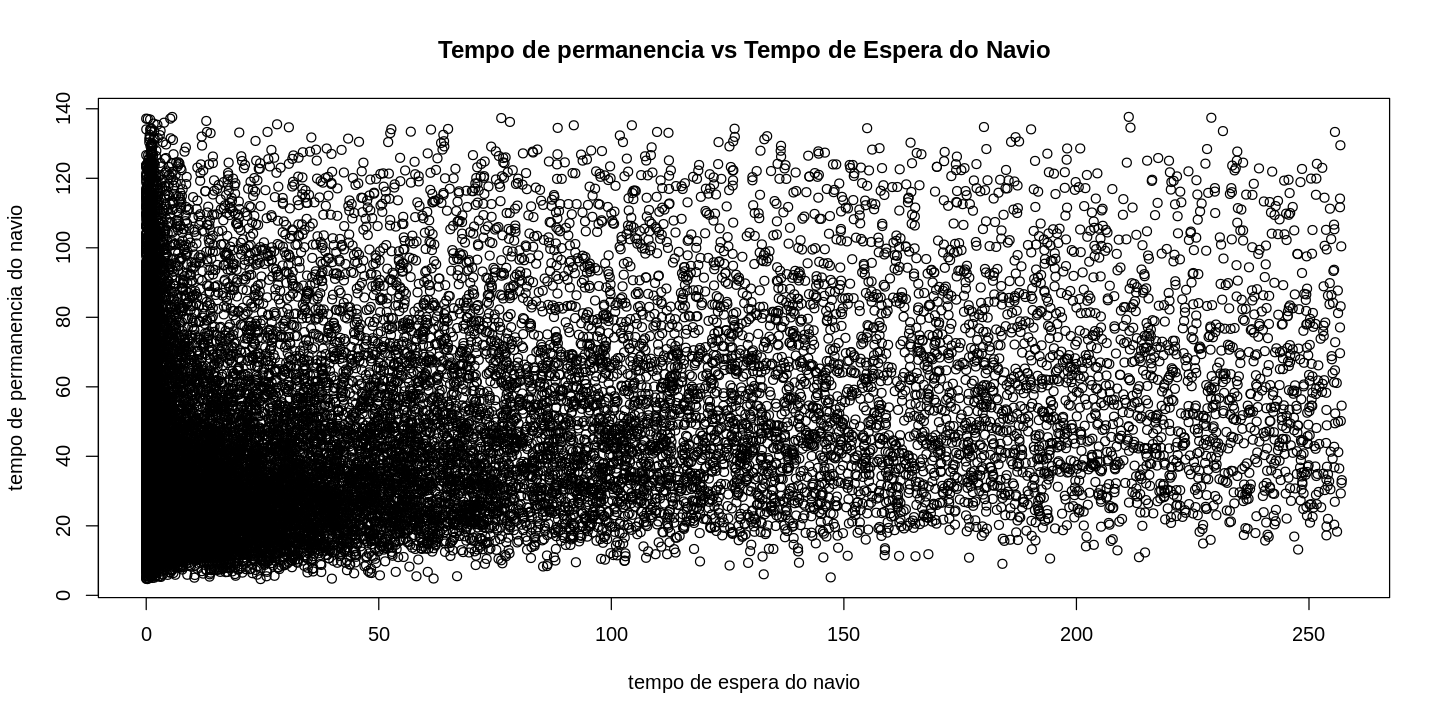

In [45]:
#plota da disperção dos dados

plot(dados_filtro$tempo_permanencia, dados_filtro$tempo_operacao,
     main = "Tempo de Permanencia do Navio vs Tempo de Operação",
     xlab = "tempo da pemanencia do navio",
     ylab = "tempo de operação")

plot(dados_filtro$tempo_permanencia, dados_filtro$tempo_total_atracacao,
     main = "Tempo de permanencia vs Tempo Total do Navio",
     xlab = "tempo de permanencia do navio",
     ylab = "tempo total de navio")

plot(dados_filtro$tempo_espera, dados_filtro$tempo_permanencia,
     main = "Tempo de permanencia vs Tempo de Espera do Navio",
     ylab = "tempo de permanencia do navio",
     xlab = "tempo de espera do navio")


In [46]:
# analise dos coeficientes de variação

espera <- dados_filtro$tempo_espera

coeficiente_var <- sd(espera)/ mean(espera)

coeficiente_var

[1] 1.449345

Regressão linear junto com o calculo de alpha e beta para todas as variaveis

[1] "Analise alpha e beta de tempo de operação sobre tempo de permanencia em logs"


[1] "Alpha ->  1.15730827982805"

[1] "Beta ->  0.750108785263757"

[1] "Alpha da função lm ->  1.15730827982805"

[1] "Beta da função lm ->  0.750108785263757"

[1] "Beta calculando covariancia(x,y)/var(x) -> 0.750108785263756"

`geom_smooth()` using formula = 'y ~ x'


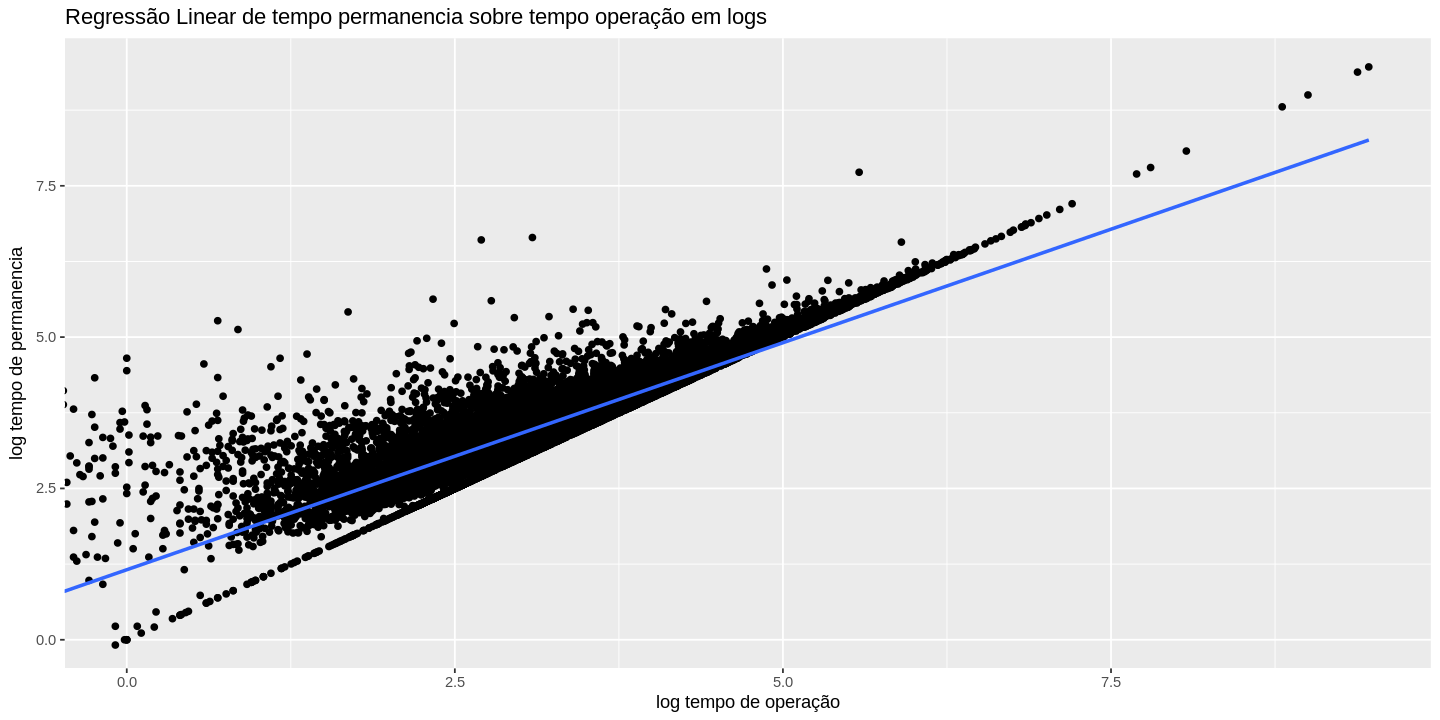

In [47]:
# Calculo de alpha e beta sem função

x <- dados$log_tempo_operacao

y <- dados$log_tempo_permanencia

n <- length(x)

media_x <- mean(x)

media_y <- mean(y)

soma_xy <- sum(x* y)

soma_x2 <- sum(x^2)

beta <- (soma_xy - n*media_x*media_y)/(soma_x2- n*(media_x^2))

alpha <- media_y - beta*media_x

#calculo de alpha e beta com função lm
modelo <- lm(y ~ x)

coeficiente <- coef(modelo)

# calculo de beta usando cov(x,y)/ var(x)
betacov <- cov(x,y)/var(x)


print("Analise alpha e beta de tempo de operação sobre tempo de permanencia em logs")
paste("Alpha -> ", alpha)
paste("Beta -> ", beta)

paste("Alpha da função lm -> ", coeficiente[1])
paste("Beta da função lm -> ", coeficiente[2])

paste("Beta calculando covariancia(x,y)/var(x) ->", betacov )

# ggplot

ggplot(dados, aes(x=x, y=y)) +
  geom_point() +
  geom_smooth(method="lm", se=TRUE) +
  labs(
  x = "log tempo de operação",
  y = "log tempo de permanencia")+
  coord_cartesian(xlim = c(0, NA), ylim = c(0, NA))+
  ggtitle("Regressão Linear de tempo permanencia sobre tempo operação em logs")


[1] "Analise alpha e beta de tempo de operação sobre tempo de total do navio no porto em logs"


[1] "Alpha ->  1.71370365728522"

[1] "Beta ->  0.785770662129623"

[1] "Alpha da função lm ->  1.71370365728522"

[1] "Beta da função lm ->  0.785770662129624"

[1] "Beta calculando covariancia(x,y)/var(x) -> 0.785770662129623"

`geom_smooth()` using formula = 'y ~ x'


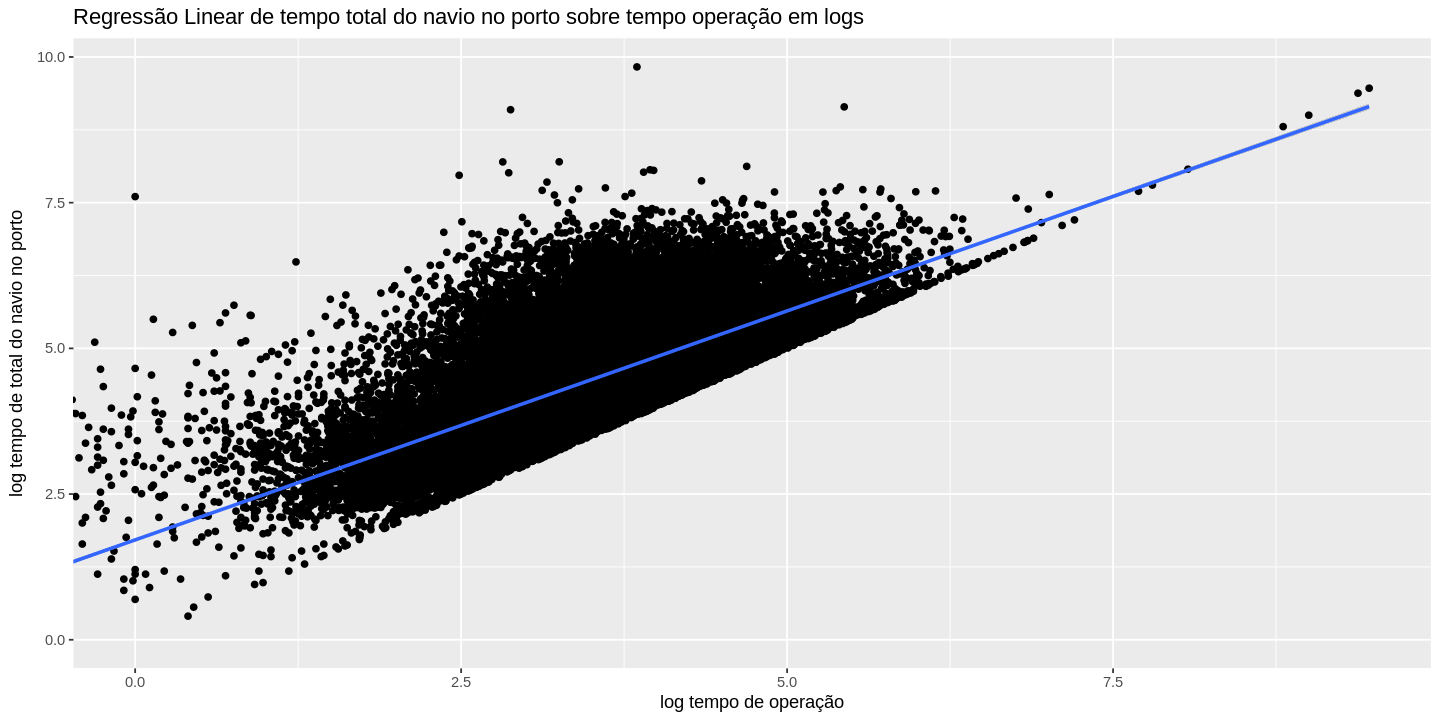

In [48]:
# Calculo de alpha e beta sem função

x <- dados$log_tempo_operacao

y <- dados$log_tempo_total_navio

n <- length(x)

media_x <- mean(x)

media_y <- mean(y)

soma_xy <- sum(x* y)

soma_x2 <- sum(x^2)

beta <- (soma_xy - n*media_x*media_y)/(soma_x2- n*(media_x^2))

alpha <- media_y - beta*media_x

#calculo de alpha e beta com função lm
modelo <- lm(y ~ x)

coeficiente <- coef(modelo)

# calculo de beta usando cov(x,y)/ var(x)
betacov <- cov(x,y)/var(x)


print("Analise alpha e beta de tempo de operação sobre tempo de total do navio no porto em logs")
paste("Alpha -> ", alpha)
paste("Beta -> ", beta)

paste("Alpha da função lm -> ", coeficiente[1])
paste("Beta da função lm -> ", coeficiente[2])

paste("Beta calculando covariancia(x,y)/var(x) ->", betacov )

# ggplot

ggplot(dados, aes(x=x, y=y)) +
  geom_point() +
  geom_smooth(method="lm", se=TRUE) +
  labs(
  x = "log tempo de operação",
  y = "log tempo de total do navio no porto")+
  coord_cartesian(xlim = c(0, NA), ylim = c(0, NA))+
  ggtitle("Regressão Linear de tempo total do navio no porto sobre tempo operação em logs")


[1] "Analise alpha e beta de tempo de operação sobre tempo de espera em logs"


[1] "Alpha ->  2.94190105415809"

[1] "Beta ->  0.154081511619272"

[1] "Alpha da função lm ->  2.9419010541581"

[1] "Beta da função lm ->  0.154081511619272"

[1] "Beta calculando covariancia(x,y)/var(x) -> 0.154081511619272"

`geom_smooth()` using formula = 'y ~ x'


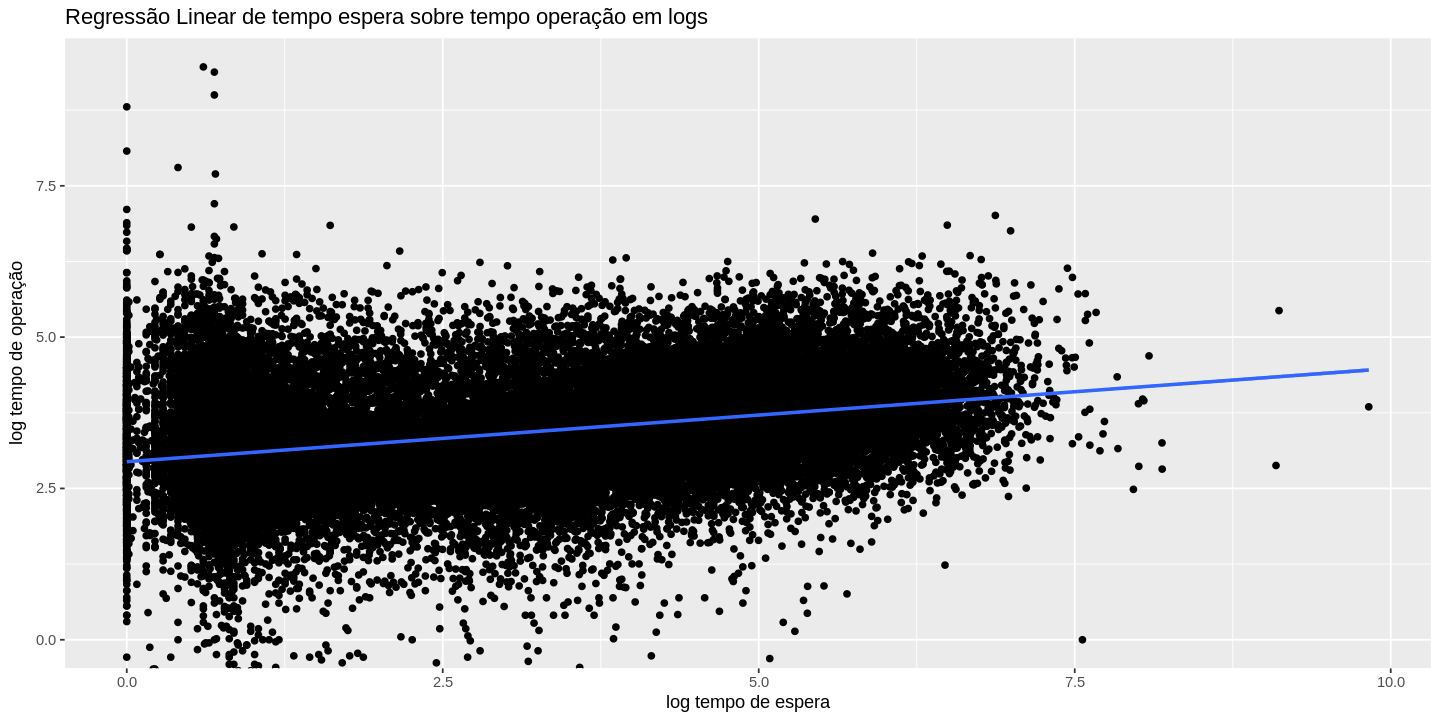

In [49]:
# Calculo de alpha e beta sem função

y <- dados$log_tempo_operacao

x <- dados$log_tempo_espera

n <- length(x)

media_x <- mean(x)

media_y <- mean(y)

soma_xy <- sum(x* y)

soma_x2 <- sum(x^2)

beta <- (soma_xy - n*media_x*media_y)/(soma_x2- n*(media_x^2))

alpha <- media_y - beta*media_x

#calculo de alpha e beta com função lm
modelo <- lm(y ~ x)

coeficiente <- coef(modelo)

# calculo de beta usando cov(x,y)/ var(x)
betacov <- cov(x,y)/var(x)


print("Analise alpha e beta de tempo de operação sobre tempo de espera em logs")
paste("Alpha -> ", alpha)
paste("Beta -> ", beta)

paste("Alpha da função lm -> ", coeficiente[1])
paste("Beta da função lm -> ", coeficiente[2])

paste("Beta calculando covariancia(x,y)/var(x) ->", betacov )

# ggplot

ggplot(dados, aes(x=x, y=y)) +
  geom_point() +
  geom_smooth(method="lm", se=TRUE) +
  labs(
  x = "log tempo de espera",
  y = "log tempo de operação")+
  coord_cartesian(xlim = c(0, NA), ylim = c(0, NA))+
  ggtitle("Regressão Linear de tempo espera sobre tempo operação em logs")


[1] "Analise alpha e beta de tempo de espera sobre tempo de permanencia em logs"


[1] "Alpha ->  3.31670132032737"

[1] "Beta ->  0.131617391316301"

[1] "Alpha da função lm ->  3.31670132032737"

[1] "Beta da função lm ->  0.131617391316301"

[1] "Beta calculando covariancia(x,y)/var(x) -> 0.131617391316301"

`geom_smooth()` using formula = 'y ~ x'


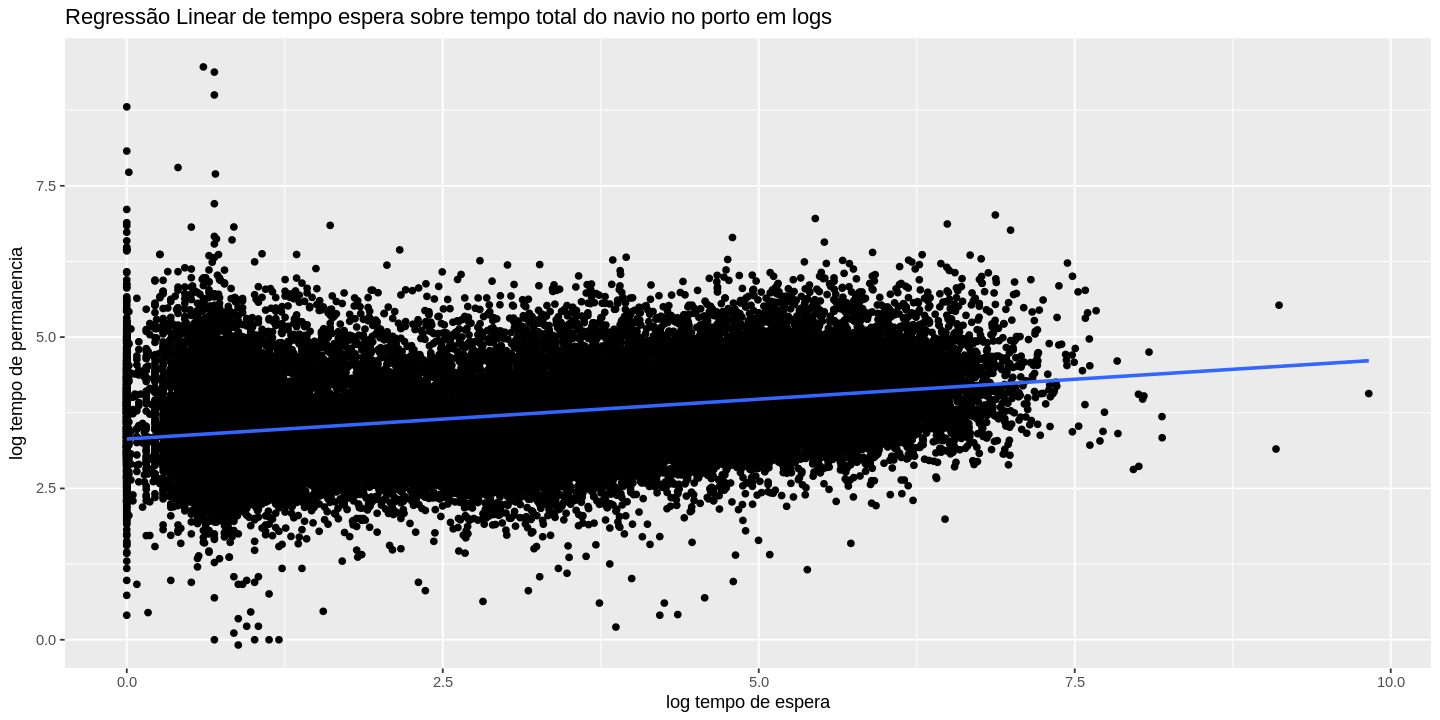

In [50]:
# Calculo de alpha e beta sem função

x <- dados$log_tempo_espera

y <- dados$log_tempo_permanencia

n <- length(x)

media_x <- mean(x)

media_y <- mean(y)

soma_xy <- sum(x* y)

soma_x2 <- sum(x^2)

beta <- (soma_xy - n*media_x*media_y)/(soma_x2- n*(media_x^2))

alpha <- media_y - beta*media_x

#calculo de alpha e beta com função lm
modelo <- lm(y ~ x)

coeficiente <- coef(modelo)

# calculo de beta usando cov(x,y)/ var(x)
betacov <- cov(x,y)/var(x)


print("Analise alpha e beta de tempo de espera sobre tempo de permanencia em logs")
paste("Alpha -> ", alpha)
paste("Beta -> ", beta)

paste("Alpha da função lm -> ", coeficiente[1])
paste("Beta da função lm -> ", coeficiente[2])

paste("Beta calculando covariancia(x,y)/var(x) ->", betacov )

# ggplot

ggplot(dados, aes(x=x, y=y)) +
  geom_point() +
  geom_smooth(method="lm", se=TRUE) +
  labs(
  x = "log tempo de espera",
  y = "log tempo de permanencia")+
  coord_cartesian(xlim = c(0, NA), ylim = c(0, NA))+
  ggtitle("Regressão Linear de tempo espera sobre tempo total do navio no porto em logs")


[1] "Analise alpha e beta de tempo de espera sobre tempo de total do navio no porto em logs"


[1] "Alpha ->  3.01301622822645"

[1] "Beta ->  0.463978322790059"

[1] "Alpha da função lm ->  3.01301622822645"

[1] "Beta da função lm ->  0.46397832279006"

[1] "Beta calculando covariancia(x,y)/var(x) -> 0.46397832279006"

`geom_smooth()` using formula = 'y ~ x'


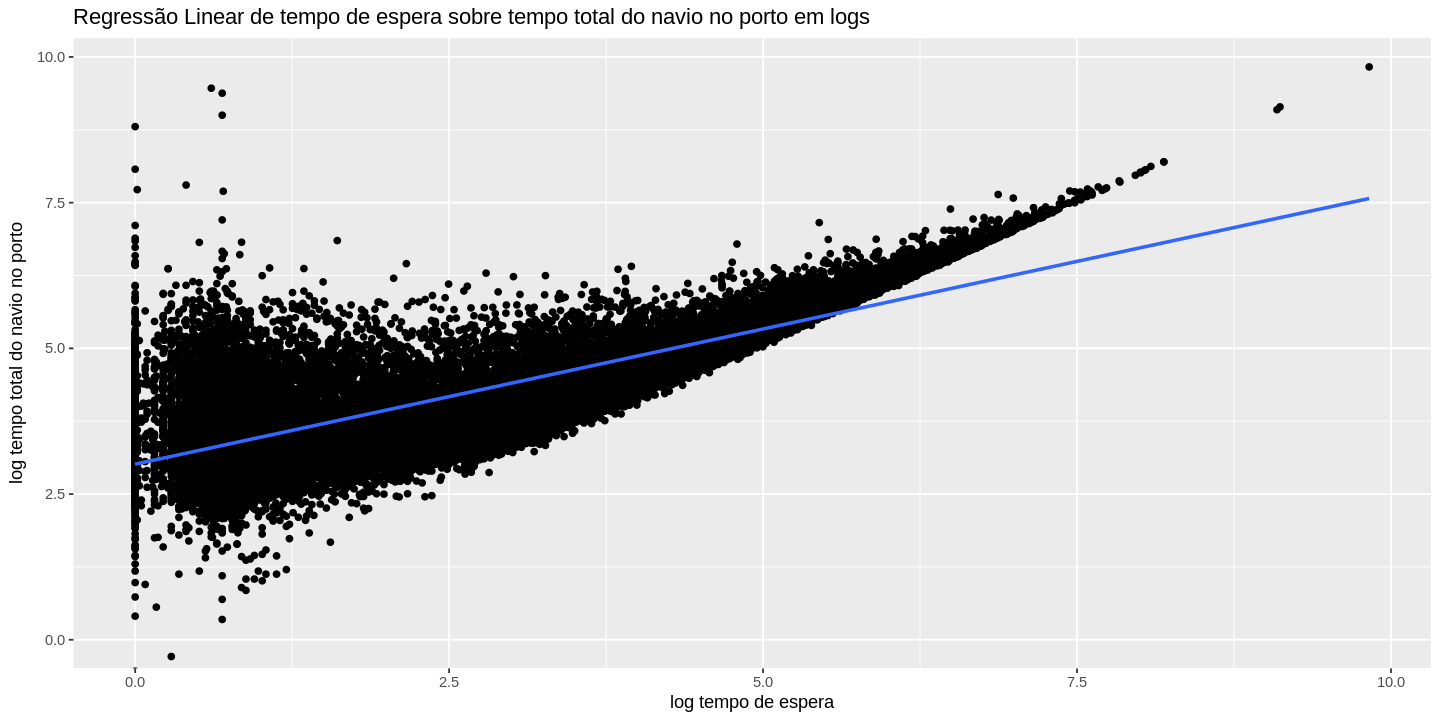

In [51]:
# Calculo de alpha e beta sem função

x <- dados$log_tempo_espera

y <- dados$log_tempo_total_navio

n <- length(x)

media_x <- mean(x)

media_y <- mean(y)

soma_xy <- sum(x* y)

soma_x2 <- sum(x^2)

beta <- (soma_xy - n*media_x*media_y)/(soma_x2- n*(media_x^2))

alpha <- media_y - beta*media_x

#calculo de alpha e beta com função lm
modelo <- lm(y ~ x)

coeficiente <- coef(modelo)

# calculo de beta usando cov(x,y)/ var(x)
betacov <- cov(x,y)/var(x)


print("Analise alpha e beta de tempo de espera sobre tempo de total do navio no porto em logs")
paste("Alpha -> ", alpha)
paste("Beta -> ", beta)

paste("Alpha da função lm -> ", coeficiente[1])
paste("Beta da função lm -> ", coeficiente[2])

paste("Beta calculando covariancia(x,y)/var(x) ->", betacov )

# ggplot

ggplot(dados, aes(x=x, y=y)) +
  geom_point() +
  geom_smooth(method="lm", se=TRUE) +
  labs(
  x = "log tempo de espera",
  y = "log tempo total do navio no porto")+
  coord_cartesian(xlim = c(0, NA), ylim = c(0, NA))+
  ggtitle("Regressão Linear de tempo de espera sobre tempo total do navio no porto em logs")


[1] "Analise alpha e beta de tempo total do navio no porto e tempo de permanencia em logs"


[1] "Alpha ->  0.548161582934416"

[1] "Beta ->  1.03491505083906"

[1] "Alpha da função lm ->  0.548161582934437"

[1] "Beta da função lm ->  1.03491505083905"

[1] "Beta calculando covariancia(x,y)/var(x) -> 1.03491505083905"

`geom_smooth()` using formula = 'y ~ x'


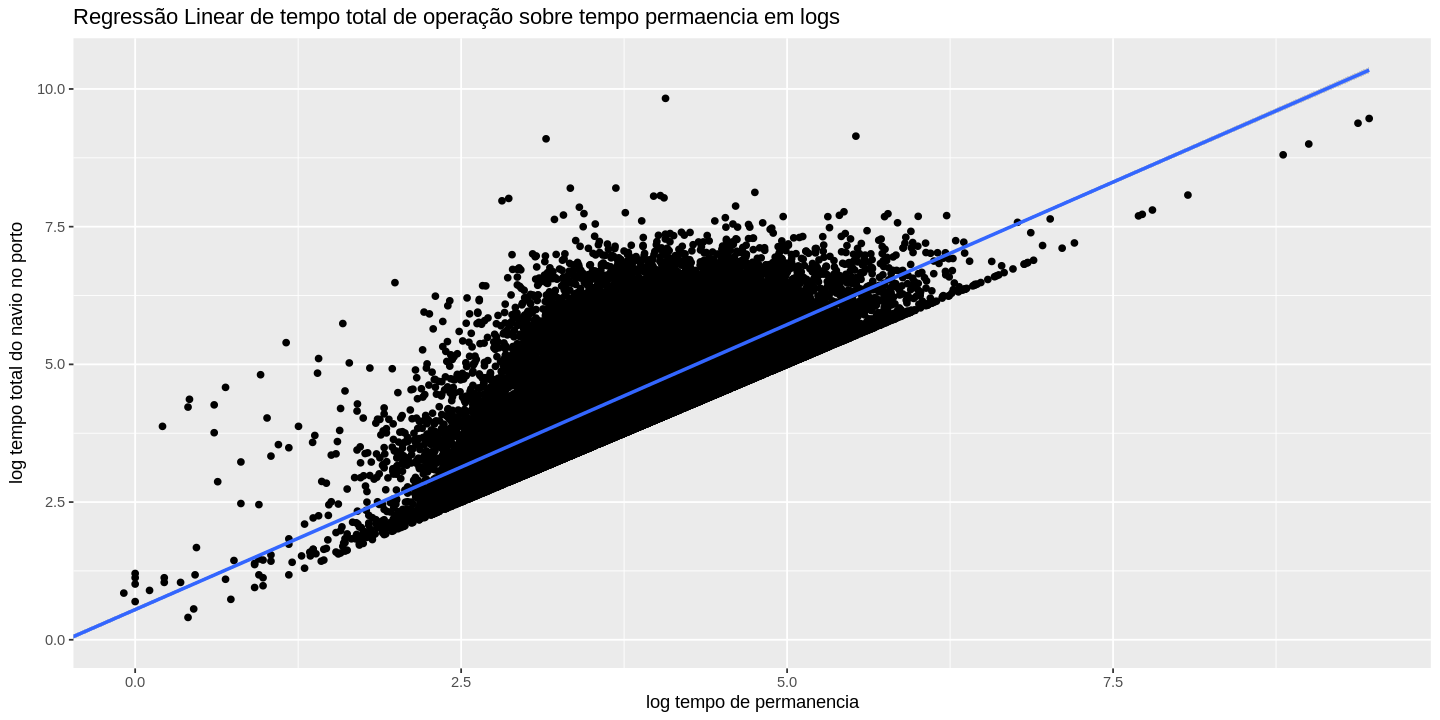

In [52]:
# Calculo de alpha e beta sem função

y <- dados$log_tempo_total_navio

x <- dados$log_tempo_permanencia

n <- length(x)

media_x <- mean(x)

media_y <- mean(y)

soma_xy <- sum(x* y)

soma_x2 <- sum(x^2)

beta <- (soma_xy - n*media_x*media_y)/(soma_x2- n*(media_x^2))

alpha <- media_y - beta*media_x

#calculo de alpha e beta com função lm
modelo <- lm(y ~ x)

coeficiente <- coef(modelo)

# calculo de beta usando cov(x,y)/ var(x)
betacov <- cov(x,y)/var(x)


print("Analise alpha e beta de tempo total do navio no porto e tempo de permanencia em logs")
paste("Alpha -> ", alpha)
paste("Beta -> ", beta)

paste("Alpha da função lm -> ", coeficiente[1])
paste("Beta da função lm -> ", coeficiente[2])

paste("Beta calculando covariancia(x,y)/var(x) ->", betacov )

# ggplot

ggplot(dados, aes(x=x, y=y)) +
  geom_point() +
  geom_smooth(method="lm", se=TRUE) +
  labs(
  x = "log tempo de permanencia",
  y = "log tempo total do navio no porto")+
  coord_cartesian(xlim = c(0, NA), ylim = c(0, NA))+
  ggtitle("Regressão Linear de tempo total de operação sobre tempo permaencia em logs")


Modelos de treinamento de dados

In [53]:
# holdout

y <- dados$log_tempo_total_navio

x <- dados$log_tempo_permanencia

n <- nrow(dados)

idx_treino <- sample(1:n, size = 0.8 * n)

treino <- dados[idx_treino, ]  # treino é uma variavel dataframe que possui todos os dados que estão em 80% do dataset
teste <- dados[-idx_treino, ] # treste é uma variavel que possui tudo aquilo que não esta no idx_treino ou seja os 20%

modelo <- lm(log_tempo_total_navio ~ log_tempo_permanencia , data = treino)

summary(modelo)$coefficients

pred <- predict(modelo, newdata = teste)

rmse <- sqrt(mean((teste$log_tempo_total_navio - pred)^2))

cat("RMSE no conjunto de teste: ", round(rmse,4), "\n")

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),0.5554197,0.021400881,25.95312,9.49596e-147
log_tempo_permanencia,1.0329583,0.005652364,182.74803,0.00000e+00


RMSE no conjunto de teste:  0.7436 


In [54]:
# K-fold mesmas variaveis

k <- 5

folds <- sample(rep(1:k, lengh.out = n))

rmse_fold <- numeric(k)

for(i in 1:k){
treino <- dados[folds != i,]
teste <- dados[folds == i,]
modelo <- lm(log_tempo_total_navio~ log_tempo_permanencia, data = treino)
pred <- predict(modelo, newdata = teste)
rmse_fold[i] <- sqrt(mean((teste$log_tempo_total_navio - pred)^2))
}

cat("RMSE por fold: ", round(rmse_fold, 4), "\n")

cat("RMSE medio (CV): ", round(mean(rmse_fold), 4), "\n")

RMSE por fold:  0.7337 0.7518 0.7471 0.7392 0.7422 
RMSE medio (CV):  0.7428 


In [55]:
# bootstrap para as mesmas variaveis

B <- 500

rmse_boot <- numeric(B)

for (b in 1:B){
idx_boots <- sample(1:n, size = n, replace = TRUE)
treino <- dados[idx_boots, ]
oob_idx <- setdiff(1:n, unique(idx_treino))
oob <- dados[oob_idx, ]

modelo <- lm(log_tempo_total_navio ~ log_tempo_permanencia, data = treino)
pred <- predict(modelo, newdata = oob)
rmse_boot[b] <- sqrt(mean((oob$log_tempo_total_navio - pred)^2))
}

cat("RMSE medio (OOB): ", round(mean(rmse_boot), 4), "\n")

cat("RMSE dv (OOB): ", round(sd(rmse_boot), 4), "\n")

cat("IC 95% do RMSE: ", round(quantile(rmse_boot, c(0.025, 0.975)), 4), "\n")

RMSE medio (OOB):  0.7436 
RMSE dv (OOB):  0 
IC 95% do RMSE:  0.7435 0.7437 


KNN

In [56]:
# mediçao do melhor K

ctrl <- trainControl(method = "cv", number = 10)

melhorK_KNN <- train(faixa_eficiencia ~ log_tempo_permanencia + log_tempo_operacao, data = dados, method = "knn",
                     trControl = ctrl, preProcess = c("center", "scale"), tuneGrid = data.frame(k = c(3,5,7,11,15,21,31,51)))

melhorK_KNN$results[,c("k", "Accuracy", "AccuracySD")]

melhorK_KNN$bestTune

,k,Accuracy,AccuracySD
,<dbl>,<dbl>,<dbl>
1,3,0.3633219,0.008165710
2,5,0.3737344,0.012287920
3,7,0.3829067,0.009383172
4,11,0.3970412,0.006096229
5,15,0.4048580,0.009045023
6,21,0.4151553,0.006271141
7,31,0.4220197,0.005711333
8,51,0.4260865,0.005787224


,k
,<dbl>
8,51


In [57]:
#modelo de Knn

novo_dado <- dados_final[1,35:36, drop = FALSE]

knn_pred <- knn(
  train = dados_final[-1,35:36],
  test = novo_dado,
  cl = dados_final[-1,40],
  k = 51
)

knn_pred

[1] otima
attr(,"nn.index")
      [,1]  [,2]  [,3]  [,4]  [,5] [,6]  [,7]  [,8] [,9] [,10] [,11] [,12]
[1,] 28944 25140 29884 29874 29875    6 29885 22974 1687 27758 30879  4201
     [,13] [,14] [,15] [,16] [,17] [,18] [,19] [,20] [,21] [,22] [,23] [,24]
[1,] 32867 22412 26930 21958    16  4170 27146 30733 26612 27584 17930 27785
     [,25] [,26] [,27] [,28] [,29] [,30] [,31] [,32] [,33] [,34] [,35] [,36]
[1,] 21916  3628  7069 31342 26472 32079 29610 34345 17863 28206 32668 18460
     [,37] [,38] [,39] [,40] [,41] [,42] [,43] [,44] [,45] [,46] [,47] [,48]
[1,] 14696 29780 15493  5525 22197 20598  2057 28374 33048 27134 27769 31268
     [,49] [,50] [,51]
[1,] 23790 20494 33929
attr(,"nn.dist")
            [,1]        [,2]        [,3]        [,4]       [,5]        [,6]
[1,] 0.001227083 0.002695842 0.005407149 0.006119497 0.00685206 0.007340225
            [,7]        [,8]        [,9]      [,10]      [,11]      [,12]
[1,] 0.007378522 0.009534671 0.009846609 0.01134547 0.01221263 0.01464255
          [,13]     [,14]      [,15]      [,16]      [,17]     [,18]      [,19]
[1,] 0.01810638 0.0190908 0.02084598 0.02176867 0.02349862 0.0249045 0.02528488
          [,20]      [,21]     [,22]      [,23]      [,24]      [,25]
[1,] 0.02569637 0.02612347 0.0261348 0.02691019 0.02726194 0.02821994
          [,26]      [,27]      [,28]      [,29]      [,30]      [,31]
[1,] 0.02858436 0.02869327 0.02960984 0.02966266 0.03021543 0.03126974
          [,32]      [,33]      [,34]      [,35]      [,36]      [,37]
[1,] 0.03254363 0.03309651 0.03393306 0.03433456 0.03449871 0.03594243
         [,38]      [,39]      [,40]     [,41]      [,42]      [,43]      [,44]
[1,] 0.0359517 0.03596451 0.03605904 0.0365777 0.03674287 0.03678054 0.03692714
          [,45]      [,46]     [,47]      [,48]      [,49]      [,50]
[1,] 0.03704536 0.03713931 0.0374009 0.03838067 0.03844366 0.03891421
          [,51]
[1,] 0.03891819
Levels: otima

In [58]:
# modelo KNN usando a distancia de mahalanobis

# calculando de forma manual

novo_dado <- dados_final[1,35:36, drop = FALSE]

X_train <- dados_final[-1,35:36]
X_teste <- novo_dado
Y_train <- dados_final[-1,40]

k = 51

S <- cov(X_train)

S_inv <- solve(S)

mahalanobis_func <- function(x, x_train, S_inv){
 n <- nrow(x_train)
  dists <- numeric(n)

  for (i in 1:n) {
    diff <- as.numeric(x - x_train[i,])
    dists[i] <- sqrt(t(diff) %*% S_inv %*% diff)
}

return(dists)
}

distancias <- mahalanobis_func(X_teste, X_train, S_inv)

idx_vizinhos <- order(distancias)[1:k]

classes_vizinhos <- Y_train[idx_vizinhos]

tabela <- table(classes_vizinhos)

classe_predita <- names(which.max(tabela))

classe_predita

[1] "otima"

K-means

In [59]:
# separar os dados usando dados_final como base
remover_outliers <- function(x) {
  Q1 <- quantile(x, 0.25)
  Q3 <- quantile(x, 0.75)
  IQR <- Q3 - Q1

  limite_inf <- Q1 - 1.5 * IQR
  limite_sup <- Q3 + 1.5 * IQR

  return(x >= limite_inf & x <= limite_sup)
}

filtro <- remover_outliers(dados_final$tempo_espera) &
          remover_outliers(dados_final$tempo_operacao) &
          remover_outliers(dados_final$tempo_permanencia) &
          remover_outliers(dados_final$tempo_total_atracacao) &
          remover_outliers(dados_final$log_tempo_espera) &
          remover_outliers(dados_final$log_tempo_operacao) &
          remover_outliers(dados_final$log_tempo_permanencia)

dados_filtro <- dados_final[filtro,]

dados_filtro <- dados_filtro %>%
  mutate(
    berco = as.factor(berco),
    terminal = as.factor(terminal),
    mes = as.factor(mes),
    tipo_de_operacao = as.factor(tipo_de_operacao),
    tipo_de_navegacao_da_atracacao = as.factor(tipo_de_navegacao_da_atracacao)
  )

[1]  2783 14543  1763  3260  6315

,tempo_espera,tempo_permanencia,tempo_operacao
1,-0.26,1.96,2.04
2,-0.47,-0.72,-0.69
3,2.12,1.57,1.61
4,1.78,-0.11,-0.17
5,-0.32,0.41,0.33


       Quantidade
Cluster 1763 2783 3260 6315 14543
      1    0    1    0    0     0
      2    0    0    0    0     1
      3    1    0    0    0     0
      4    0    0    1    0     0
      5    0    0    0    1     0

       eficiencia
cluster baixa media alta otima
      1     3   252  875  1653
      2  1818  4012 5253  3460
      3   394  1368    1     0
      4  2782   478    0     0
      5   167  1840 1927  2381

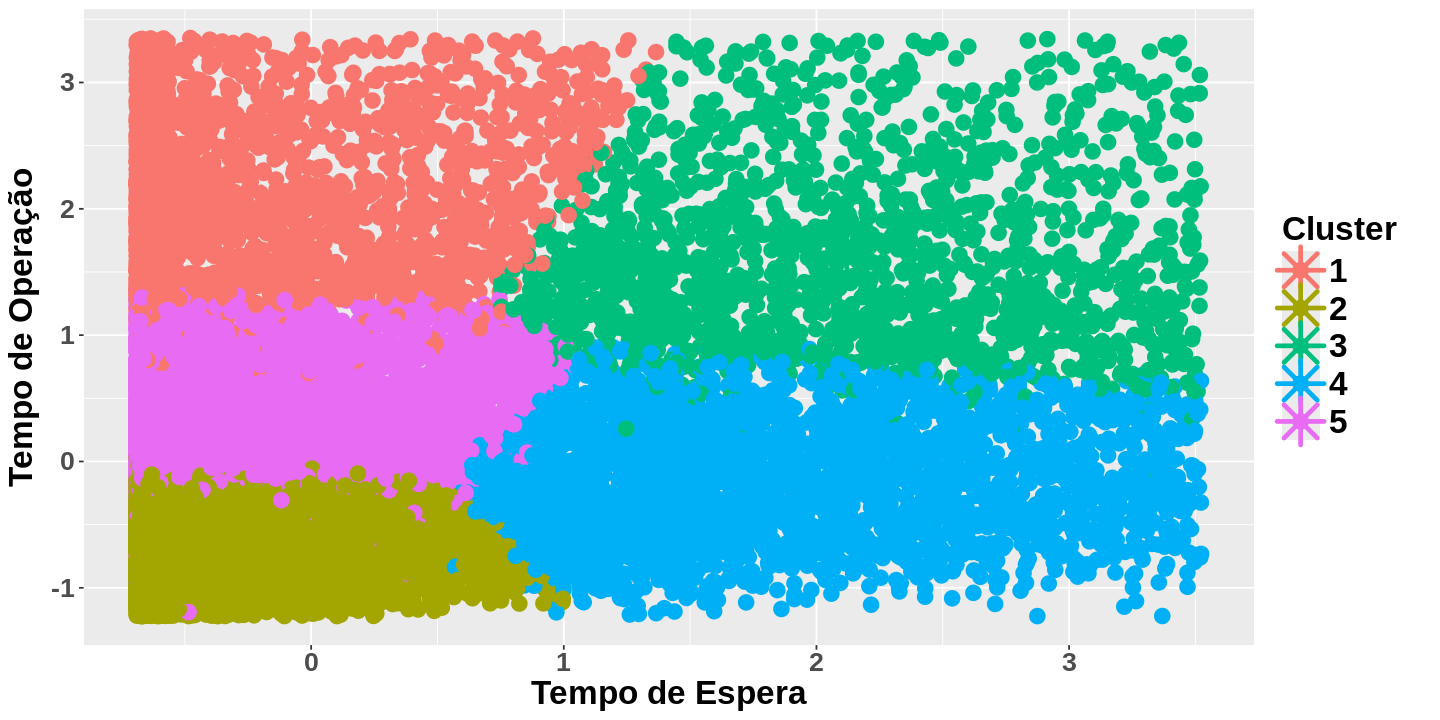

In [60]:
#processo kmeans

dados_finais <- dados_filtro %>% dplyr::select(-c(1:29,34:39,32))

dados_numericos <- dados_finais[,sapply(dados_finais, is.numeric)]


X <- scale(dados_numericos)

set.seed(123)
km <- kmeans(X, centers = 5, nstart = 25)

km$size

round(km$centers, 2)

sumario_cluster <- as.data.frame(table(km$cluster))

colnames(sumario_cluster) <- c("Cluster", "Quantidade")

table(sumario_cluster)

table(cluster= km$cluster, eficiencia =dados_finais$faixa_eficiencia)

dados_escalonados <- as.data.frame(X)

dados_escalonados$cluster <- as.factor(km$cluster)

centroides <- as.data.frame(km$centers)

centroides$cluster <- as.factor(1:nrow(centroides))

dados_filtro$cluster <- as.factor(km$cluster)

ggplot(dados_escalonados,
       aes(x = tempo_espera,
           y = tempo_operacao,
           color = cluster)) +

  geom_point(size = 4) +

  # centróides
  geom_point(data = centroides,
             aes(x = tempo_espera,
                 y = tempo_operacao),
             size = 8,
             shape = 8,
             stroke = 2) +
  labs(
    x = "Tempo de Espera",
    y = "Tempo de Operação",
    color = "Cluster"
  ) +

  theme(
    axis.text.x = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 16, face = "bold"),
    axis.title.x = element_text(size = 20, face = "bold"),
    axis.title.y = element_text(size = 20, face = "bold"),
    legend.title = element_text(size = 20, face = "bold"),
    legend.text = element_text(size =20, face = "bold")
  )

Arvore de Desição

In [61]:
# Arvore de decisão tratamento para melhorar a visualização


breaks_q_esp <- quantile(dados_filtro$tempo_espera, probs = seq(0,1,0.25), na.rm = TRUE)

breaks_q_per <- quantile(dados_filtro$tempo_permanencia, probs = seq(0,1,0.25), na.rm = TRUE)

breaks_q_op <- quantile(dados_filtro$tempo_operacao, probs = seq(0,1,0.25), na.rm = TRUE)

dados_filtro$Quartilesp <- cut(dados_filtro$tempo_espera,
                       breaks = breaks_q_esp,
                       include.lowest = TRUE,
                       labels = c("25%","50%","75%","100%"))

dados_filtro$Quartilper <- cut(dados_filtro$tempo_permanencia,
                       breaks = breaks_q_per,
                       include.lowest = TRUE,
                       labels = c("25%","50%","75%","100%"))

dados_filtro$Quartilop <- cut(dados_filtro$tempo_operacao,
                       breaks = breaks_q_op,
                       include.lowest = TRUE,
                       labels = c("25%","50%","75%","100%"))

unique(dados_filtro$tipo_de_operacao)

dados_filtro <- dados_filtro %>%
  mutate(tipo_de_operacao = recode(
  tipo_de_operacao,
  "movimentacao_da_carga" = "mover_carga",
  "reparo/manutencao" = "reparo"
  )
  )

  unique(dados_filtro$tipo_de_operacao)

[1] marinha               passageiro            movimentacao_da_carga
[4] reparo/manutencao     apoio                 abastecimento        
6 Levels: abastecimento apoio marinha movimentacao_da_carga ... reparo/manutencao

[1] marinha       passageiro    mover_carga   reparo        apoio        
[6] abastecimento
Levels: abastecimento apoio marinha mover_carga passageiro reparo

In [62]:
# criar arvore aplicando o metodo holdout 70-30

set.seed(123)

n <- nrow(dados_filtro)

idx_treino <- sample(1:n, size = 0.7 * n)

treino <- dados_filtro[idx_treino, ]
teste <- dados_filtro[-idx_treino, ]

modelo_arvore_treinada <- rpart(cluster ~ Quartilesp + Quartilper + Quartilop + tipo_de_operacao,
                       data = treino,
                       method = "class",
                       parms = list(split = "gini"),
                       control = rpart.control(minsplit = 2, cp = 0)
                       )


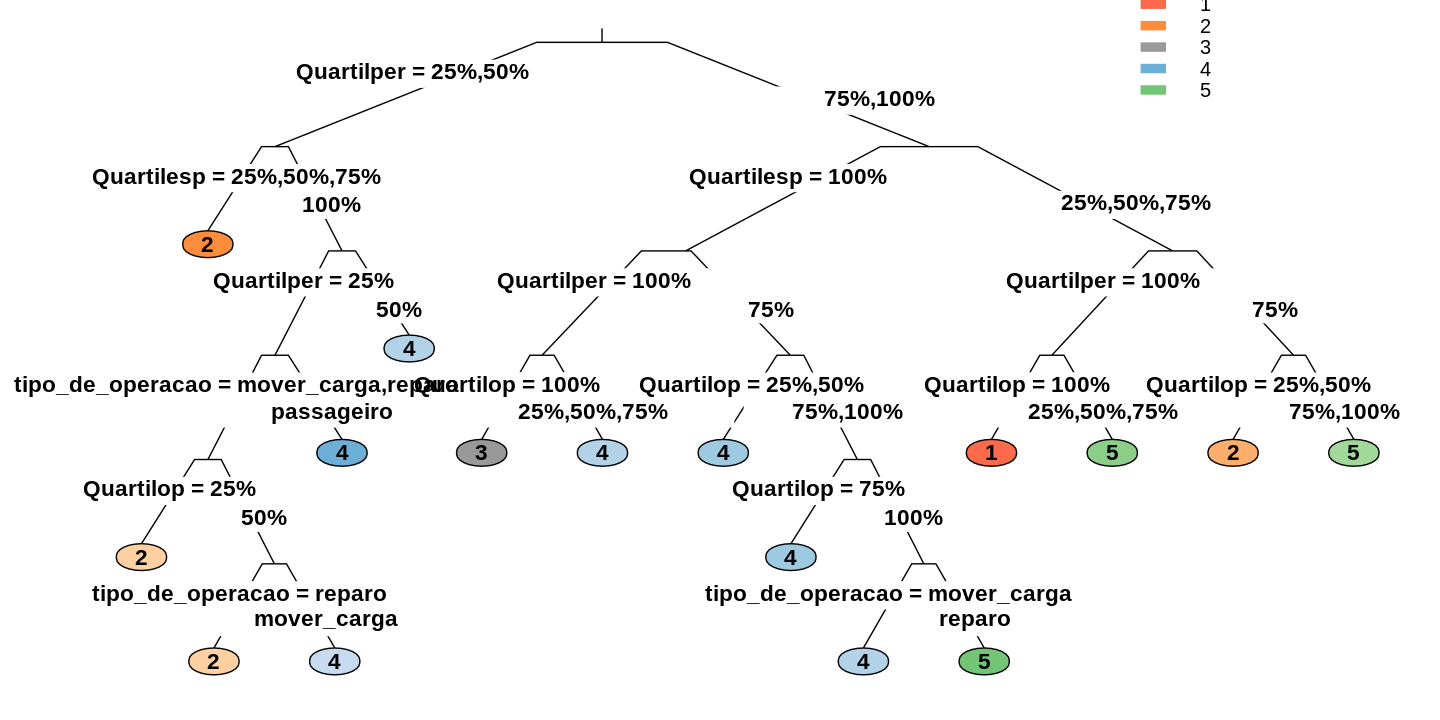

In [63]:
#plotagem da arvore

rpart.plot(
  modelo_arvore_treinada,

  #customizações
  cex = 1.13,
  font = 2,

  # configurações de elementos e tipos de plotagem de arvores

  type = 3,
  extra = 0,
  fallen.leaves = FALSE,
  under = FALSE
  )

In [64]:
#previsao

previsoes <- predict(modelo_arvore_treinada, newdata = teste, type = "class")

matriz_confusao <- confusionMatrix(previsoes, teste$cluster)

print(matriz_confusao)

Confusion Matrix and Statistics

          Reference
Prediction    1    2    3    4    5
         1  660    0    0    0  442
         2    0 4067    0   60   36
         3  146    0  521   36   91
         4    0  148    6  868  162
         5    6  191    0    1 1159

Overall Statistics
                                          
               Accuracy : 0.8459          
                 95% CI : (0.8381, 0.8535)
    No Information Rate : 0.5123          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.7748          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 4 Class: 5
Sensitivity           0.81281   0.9231  0.98861   0.8995   0.6132
Specificity           0.94325   0.9771  0.96618   0.9586   0.9705
Pos Pred Value        0.59891   0.9769  0.65617   0.7331   0.8541
Neg Pred Value        0.97973   0.923


Call:
 randomForest(formula = cluster ~ Quartilesp + Quartilper + Quartilop +      tipo_de_operacao, data = dados_filtro, ntree = 500, mtry = sqrt(4),      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 15.89%
Confusion matrix:
     1     2    3    4    5 class.error
1 2238     0  534    0   11 0.195831836
2    0 13228    0  706  609 0.090421509
3    0     0 1746   17    0 0.009642655
4    0    81  151 3027    1 0.071472393
5 1430   136  310  569 3870 0.387173397


,1,2,3,4,5,MeanDecreaseAccuracy,MeanDecreaseGini
Quartilesp,55.17756,75.470247,72.710283,171.11978,110.96760,150.14118,3159.42831
Quartilper,69.07458,91.741101,43.795174,10.27506,66.67021,104.81363,5829.51085
Quartilop,138.30392,18.126363,44.118027,2.64601,30.01365,46.38923,3490.65617
tipo_de_operacao,21.40404,8.420266,4.356147,11.41007,-20.90427,19.54585,15.21812


[1] "previsões"


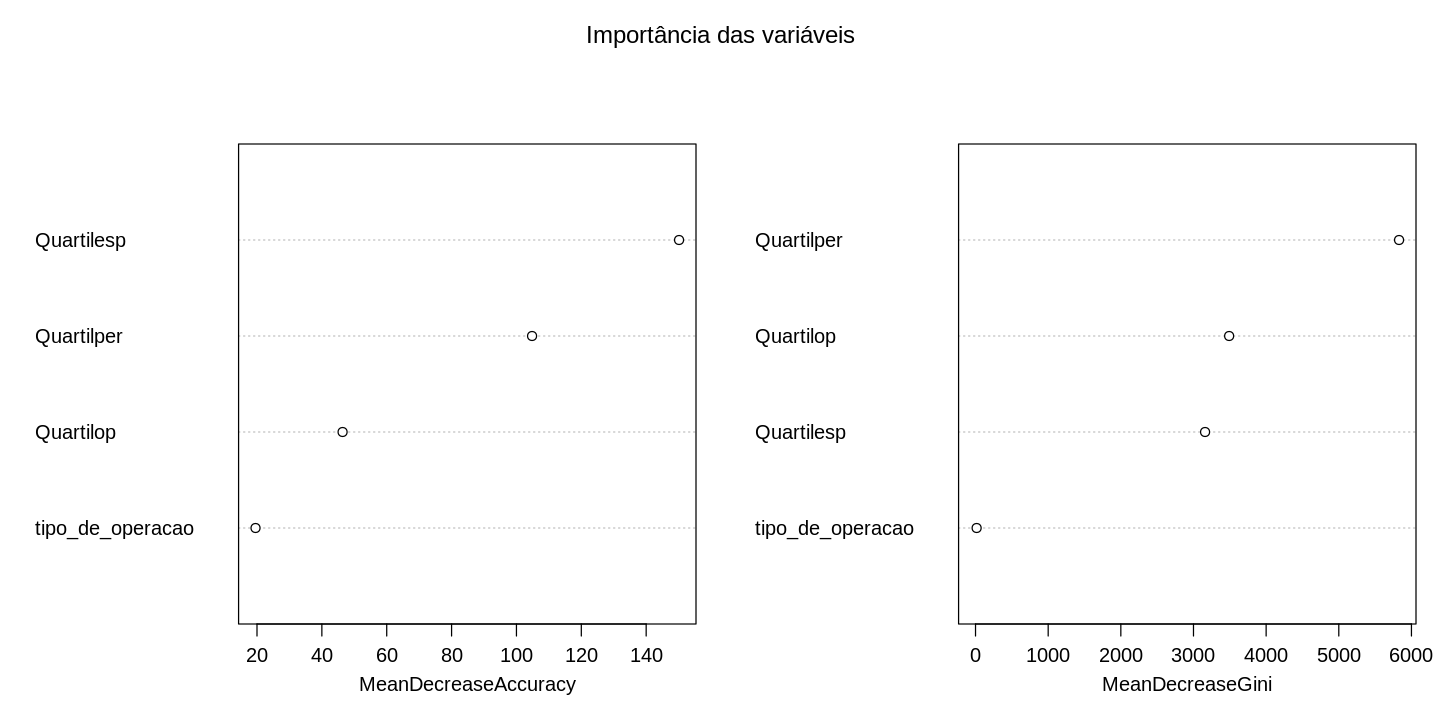

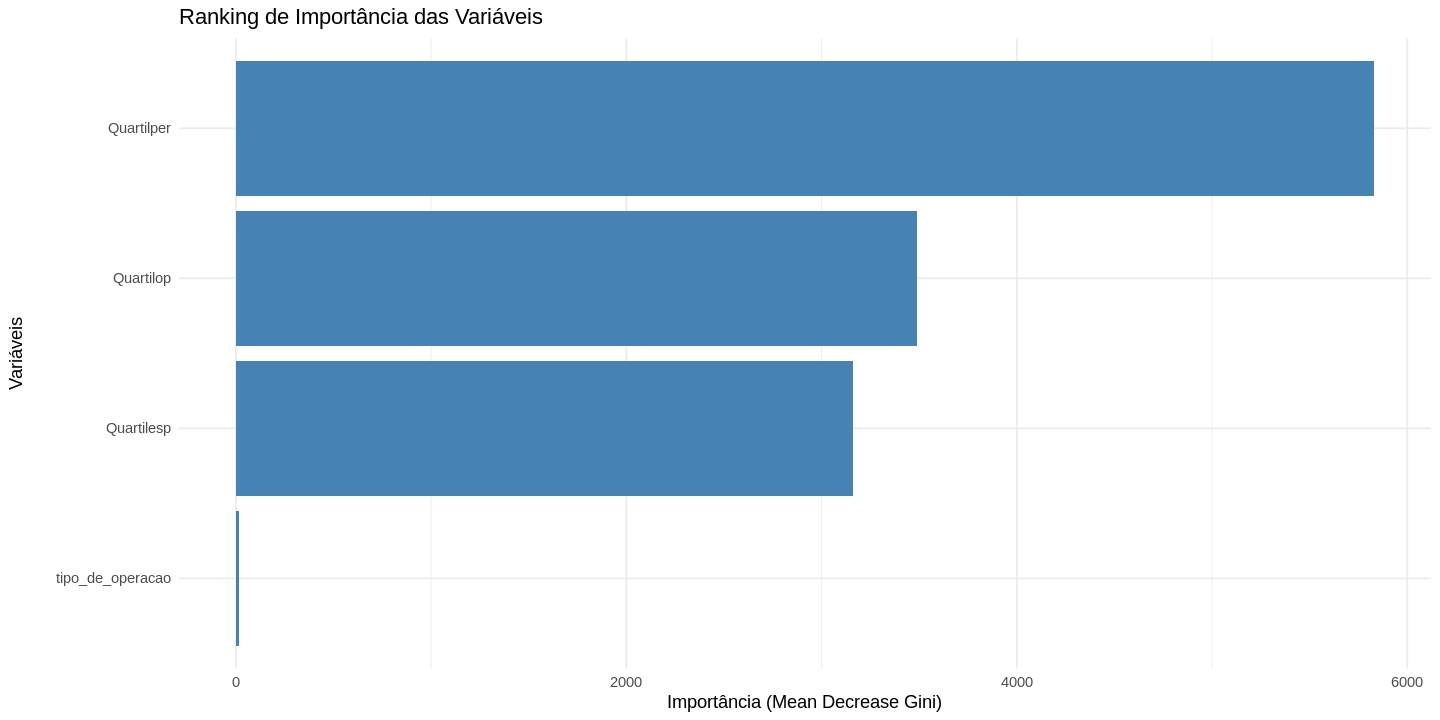

In [67]:
#randomForest

set.seed(123)

modelo_rf <- randomForest(cluster ~ Quartilesp + Quartilper + Quartilop + tipo_de_operacao,
                          data = dados_filtro,
                          ntree = 500,
                          mtry = sqrt(4),
                          importance = TRUE)



print(modelo_rf)

importancia <- importance(modelo_rf)

importancia

varImpPlot(modelo_rf, main = "Importância das variáveis")

previsao <- predict(modelo_rf,teste,type="prob")

print("previsões")

df_imp <- data.frame(
  Variavel = rownames(importancia),
  Importancia = importancia[, "MeanDecreaseGini"] #  Também pode usar "MeanDecreaseAccuracy"
)

# 2. Ordenar pelo rank e criar o fator (mantém o ggplot na ordem correta)
df_imp <- df_imp %>%
  arrange(Importancia) %>%
  mutate(Variavel = factor(Variavel, levels = Variavel))

# 3. Criar o gráfico
ggplot(df_imp, aes(x = Importancia, y = Variavel)) +
  geom_col(fill = "steelblue") + # Cria as barras com cor sólida
  theme_minimal() +
  labs(
    title = "Ranking de Importância das Variáveis",
    x = "Importância (Mean Decrease Gini)",
    y = "Variáveis"
  )

